# Main Grid v2 Analysis — Frozen Scientific Version

This notebook is the cleaned and frozen main-grid analysis for the thesis.

**Reference condition:** `plain` prompt.  
**Evaluation target:** analytic conditional truth.  
**Primary conditional-alignment metric:** TVD.  
**Primary common-grid aggregation:** average prefixes within stage, then give equal weight to **ROOT, Integer, Dot, and Fraction depth 1**.

Sign is analysed separately because it is not available for all target distributions. Fraction depth 2 remains supplementary.

The notebook is organised directly by research question. Exploratory duplicates and superseded figures have been removed. The cross-RQ variance attribution uses the corrected balanced non-trivial three-stage population described in the synthesis section.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PREFIX_PATH = Path("prefix_summary_main_grid_v2_merged.csv")
TOKEN_PATH = Path("token_level_main_grid_v2_merged.csv")

prefix_df = pd.read_csv(PREFIX_PATH)
token_df = pd.read_csv(TOKEN_PATH)

# The empty prefix is the ROOT state; pandas otherwise reads it as NaN.
prefix_df["prefix"] = prefix_df["prefix"].fillna("ROOT")
token_df["prefix"] = token_df["prefix"].fillna("ROOT")

print("Prefix-level data:", prefix_df.shape)
print("Token-level data: ", token_df.shape)


Prefix-level data: (1608, 49)
Token-level data:  (14760, 42)


In [83]:
# Stable thesis-facing labels and plotting order

MODEL_LABELS = {
    "S1": "Qwen3-4B Base · raw",
    "S2": "Qwen3-4B Instruct · raw",
    "S3": "Qwen3-4B Instruct · chat",
    "S4": "Gemma-4-E4B Base · raw",
    "S5": "Gemma-4-E4B IT · raw",
    "S6": "Gemma-4-E4B IT · chat",
    "M1": "Qwen3-14B Base · raw",
    "M2": "Qwen3-14B · raw",
    "M3": "Qwen3-14B · chat",
    "M4": "Gemma-4-12B Base · raw",
    "M5": "Gemma-4-12B IT · raw",
    "M6": "Gemma-4-12B IT · chat",
}

MODEL_ORDER = [
    "S1", "S2", "S3",
    "S4", "S5", "S6",
    "M1", "M2", "M3",
    "M4", "M5", "M6",
]

DISTRIBUTION_ORDER = [
    "normal",
    "uniform",
    "exponential",
    "beta",
    "laplace",
]

DISTRIBUTION_LABELS = {
    "normal": "Normal",
    "uniform": "Uniform",
    "exponential": "Exponential",
    "beta": "Beta",
    "laplace": "Laplace",
}

STAGE_LABELS = {
    "start": "ROOT",
    "sign": "Sign",
    "integer": "Integer",
    "dot": "Dot",
    "fraction_d1": "Fraction d1",
}

STAGE_ORDER = ["start", "sign", "integer", "dot", "fraction_d1"]

# Keep figure text simple and consistent.
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


def annotated_heatmap(
    data,
    *,
    xlabel,
    ylabel,
    figsize=(8.2, 6.2),
    vmin=0,
    vmax=1,
    cmap_name="viridis_r",
    colorbar_label="Mean TVD",
    title=None,
    nan_color="lightgray",
    decimals=3,
):
    # Clean annotated heatmap used consistently across this notebook.
    values = data.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(values)

    cmap = plt.colormaps[cmap_name].copy()
    cmap.set_bad(color=nan_color)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        masked,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title:
        ax.set_title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if pd.notna(value):
                text_color = "white" if im.norm(value) > 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=8,
                )

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(colorbar_label)

    fig.tight_layout()
    plt.show()


## 1. Compact validation

Validation is intentionally kept short here. Analytic truth is the scientific evaluation target; Monte Carlo is used only as an independent check of the analytic construction. The main-grid jobs were also repeated twice under the same configuration and reproduced the original outputs exactly.


In [3]:
summary = pd.Series({
    "runs": prefix_df["run_id"].nunique(),
    "model_ids": prefix_df["model_id"].nunique(),
    "distributions": prefix_df["distribution"].nunique(),
    "prompts": prefix_df["prompt_type"].nunique(),
    "protocols": prefix_df["prompt_protocol"].nunique(),
    "seeds": prefix_df["seed"].nunique(),
    "prefix_rows": len(prefix_df),
    "token_rows": len(token_df),
    "duplicate_prefix_rows": prefix_df.duplicated(["run_id", "prefix"]).sum(),
    "duplicate_token_rows": token_df.duplicated(["run_id", "prefix", "token"]).sum(),
    "mc_reliable_rows": int(prefix_df["mc_reliable"].sum()),
})

display(summary.to_frame("value"))

display(
    prefix_df["tv_mc_analytic"]
    .describe()[["mean", "50%", "max"]]
    .rename({"50%": "median"})
    .to_frame("TVD: MC vs analytic")
)

mass_error = (
    prefix_df["valid_candidate_mass"]
    + prefix_df["other_vocab_mass"]
    - 1.0
).abs()

print(
    "Max |valid_candidate_mass + other_vocab_mass - 1|:",
    mass_error.max(),
)

prob_sums = (
    token_df
    .groupby(["run_id", "prefix"])[
        ["analytic_truth", "mc_truth", "lm_prob"]
    ]
    .sum()
)

display(
    (prob_sums - 1.0)
    .abs()
    .max()
    .to_frame("max absolute deviation from 1")
)


,value
runs,120
model_ids,12
distributions,5
prompts,2
protocols,2
seeds,1
prefix_rows,1608
token_rows,14760
duplicate_prefix_rows,0
duplicate_token_rows,0


,TVD: MC vs analytic
mean,0.008398
median,0.004802
max,0.038913


Max |valid_candidate_mass + other_vocab_mass - 1|: 2.220446049250313e-16


,max absolute deviation from 1
analytic_truth,6.661338e-16
mc_truth,6.661338e-16
lm_prob,2.309680e-07


### Validation summary

The merge, probability accounting, and analytic-truth cross-check are sufficiently stable for the substantive analysis. No further validation branch is pursued unless a later result reveals an inconsistency.


# Analysis Populations and Aggregation Rules

The main-grid analyses use several related but intentionally different populations. Deterministic single-candidate prefixes remain meaningful when evaluating overall numerical behaviour or numerical compliance, but they do not provide information about probability allocation among competing continuations.

| Analysis | Prompt / condition | Prefix population | Deterministic states | Main aggregation / comparison |
|---|---|---|---|---|
| **RQ1.A — Primary alignment** | `plain` | ROOT, Integer, Dot, Fraction d1 | **Retained** | Prefixes averaged within stage; four stages equally weighted |
| **RQ1.B — Allocation-only sensitivity** | `plain` | Same primary stages, restricted to $|\mathcal C_r|>1$ | **Excluded** | Sensitivity analysis of RQ1.A |
| **RQ1.C — Uniform-valid reference** | `plain` | Primary stages | **Retained; singleton cases interpreted as mechanical equality** | Model TVD compared with uniform-over-valid-candidates TVD within stage |
| **RQ1.D — Ranking diagnostics** | `plain` | Primary-stage prefixes for which the ranking statistic is defined | Undefined cases reported explicitly | Spearman and tie-aware top-1 complement TVD |
| **RQ1.E — Compliance vs conditional alignment** | `plain` | ROOT, Integer, Dot, Fraction d1 | **Retained** | Same hierarchy as RQ1.A; valid mass and TVD kept separate |
| **RQ2.A/B** | `plain` | Primary stages with $|\mathcal C_r|>1$ | **Excluded** | Stage-localised allocation and entropy analyses |
| **RQ2.C** | `plain` | ROOT for canonical Normal and Laplace | Not applicable as a filter | Direct sign-probability comparison with analytic $0.5$ |
| **RQ2.D** | `plain` | ROOT, Integer, Dot, Fraction d1 | **Retained** | Outside-valid mass before conditional renormalisation |
| **RQ2.E** | `plain` | Bounded-support structural-zero ROOT states | Retained where relevant | Mass on candidates excluded by target support |
| **RQ2.F** | `plain` | Diagnostic-specific Integer, Dot, and Fraction d1 prefixes | Depends on diagnostic | Candidate residual $P_{\mathrm{LM}}^*-P_{\mathrm{truth}}$ |
| **RQ3A.A** | `plain` | Common RQ1.A primary grid | **Retained** | Four-stage hierarchical TVD across distributions |
| **RQ3A.B** | `plain` | Non-trivial stage population from RQ2.A | **Excluded** | Distribution effects evaluated by stage |
| **RQ3A.C** | `plain` | Prefixes shared across all five distributions | Prefix-specific | Cross-distribution TVD of analytic and model conditional vectors |
| **RQ4.A–D** | `plain` | Common RQ1.A primary grid unless stage-localised | **Retained in primary contrasts** | Matched model/protocol contrasts |
| **RQ5 bridge** | `plain` vs `explanatory_4` | Common four-stage primary grid | **Retained** | Paired $\Delta TVD$ and $\Delta M_{\mathrm{valid}}$ |
| **Cross-RQ variance attribution** | `plain` | ROOT, Dot, Fraction d1 with $|\mathcal C_r|>1$ | **Excluded** | Balanced $12\times5\times3=180$ cell decomposition |

## Primary versus allocation-only estimands

The **common-grid primary estimand** retains deterministic states and gives equal weight to ROOT, Integer, Dot, and Fraction depth 1:

$$
TVD_{\mathrm{primary}}
=
\frac{
T_{\mathrm{ROOT}}
+
T_{\mathrm{Integer}}
+
T_{\mathrm{Dot}}
+
T_{\mathrm{Fraction\ d1}}
}{4}.
$$

The **non-trivial allocation view** restricts analysis to prefixes satisfying

$$
|\mathcal C_r|>1,
$$

and is used when the question specifically concerns how probability is distributed among competing continuations.

These views are complementary rather than interchangeable. Numerical-compliance analyses retain deterministic states because valid-candidate mass remains informative even when only one continuation is available.

## Aggregation convention

Unless a subsection states otherwise, aggregation follows the hierarchy appropriate to the research question rather than taking a flat mean over prefix rows.

For the primary common-grid analyses:

1. prefixes are averaged within numerical stage;
2. stages are equally weighted within each model/protocol × distribution condition;
3. distributions are equally weighted when producing model-level summaries.

For stage-specific analyses, prefixes are first averaged within model/protocol × distribution × stage before any marginal averaging across distributions or models.


In [4]:
# Candidate counts and fractional depth

candidate_counts = (
    token_df
    .groupby(["run_id", "prefix"])
    .size()
    .rename("n_valid_candidates")
    .reset_index()
)

prefix_df = (
    prefix_df
    .drop(columns="n_valid_candidates", errors="ignore")
    .merge(
        candidate_counts,
        on=["run_id", "prefix"],
        how="left",
    )
)


def get_fraction_depth(prefix):
    if "." not in prefix:
        return np.nan

    fractional_part = prefix.split(".", 1)[1]

    if fractional_part == "":
        return 0

    return len(fractional_part)


prefix_df["fraction_depth"] = prefix_df["prefix"].apply(get_fraction_depth)

plain_df = prefix_df[
    prefix_df["prompt_type"] == "plain"
].copy()

plain_df["model_label"] = plain_df["model_id"].map(MODEL_LABELS)

plain_df["prefix_complexity"] = np.where(
    plain_df["n_valid_candidates"] == 1,
    "deterministic",
    "non-trivial",
)

plain_df["stage_key"] = plain_df["prefix_kind"]
plain_df.loc[
    (plain_df["prefix_kind"] == "fraction")
    & (plain_df["fraction_depth"] == 1),
    "stage_key",
] = "fraction_d1"

display(
    plain_df["prefix_complexity"]
    .value_counts()
    .to_frame("prefix rows")
)


,prefix rows
prefix_complexity,
non-trivial,720
deterministic,84


In [5]:
# Diagnostic-prefix inventory per distribution.
# This makes the unequal number of evaluated prefixes explicit.

prefix_inventory = (
    plain_df[
        ["distribution", "prefix", "prefix_kind", "fraction_depth"]
    ]
    .drop_duplicates()
    .copy()
)


def inventory_stage(row):
    if row["prefix_kind"] == "start":
        return "ROOT"
    if row["prefix_kind"] == "sign":
        return "Sign"
    if row["prefix_kind"] == "integer":
        return "Integer"
    if row["prefix_kind"] == "dot":
        return "Dot"
    if row["prefix_kind"] == "fraction":
        return f"Fraction d{int(row['fraction_depth'])}"
    return row["prefix_kind"]


prefix_inventory["analysis_stage"] = prefix_inventory.apply(
    inventory_stage,
    axis=1,
)

inventory_matrix = (
    prefix_inventory
    .groupby(["distribution", "analysis_stage"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=DISTRIBUTION_ORDER,
        columns=[
            "ROOT",
            "Sign",
            "Integer",
            "Dot",
            "Fraction d1",
            "Fraction d2",
        ],
        fill_value=0,
    )
)

inventory_matrix.index = [
    DISTRIBUTION_LABELS[d] for d in inventory_matrix.index
]

display(inventory_matrix)


analysis_stage,ROOT,Sign,Integer,Dot,Fraction d1,Fraction d2
Normal,1,1,4,4,4,4
Uniform,1,0,1,1,3,3
Exponential,1,0,3,3,3,3
Beta,1,0,1,1,3,3
Laplace,1,1,4,4,4,4


The inventory shows why a flat average over all prefixes is not the desired primary summary. For example, Fraction contains several diagnostic prefixes while ROOT contains one. The primary hierarchical score therefore averages within stage first and then gives the four common stages equal weight.


# RQ1 — Overall Probabilistic Alignment

**RQ1:** To what extent do LLM next-symbol probabilities over valid numerical continuations align with analytically derived conditional probabilities under canonical target settings?

## RQ1.A — Primary conditional alignment

### Question

How closely does each model/protocol condition match the analytic next-symbol distribution across the five canonical target distributions?

### Analysis choice

The plain prompt is used as the canonical main-grid baseline.

To avoid giving greater influence to stages simply because they contain more evaluated prefixes, TVD is aggregated hierarchically. Prefixes are first averaged within ROOT, Integer, Dot, and Fraction depth 1. These four diagnostic stages are then given equal weight within each model–distribution condition.

Sign is analysed separately because it is not available for all target distributions. Fraction depth 2 is retained as supplementary analysis and is not included in the primary score.

In [6]:
# RQ1.A — Primary hierarchical TVD

# ROOT, Integer, Dot
rq1a_nonfraction = (
    plain_df[
        plain_df["prefix_kind"].isin(
            ["start", "integer", "dot"]
        )
    ]
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
            "prefix_kind",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=("tv_analytic_lm", "mean")
    )
)

# Fraction depth 1
rq1a_fraction_d1 = (
    plain_df[
        (plain_df["prefix_kind"] == "fraction")
        & (plain_df["fraction_depth"] == 1)
    ]
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=("tv_analytic_lm", "mean")
    )
)

rq1a_fraction_d1["prefix_kind"] = "fraction_d1"

rq1a_stage_scores = pd.concat(
    [rq1a_nonfraction, rq1a_fraction_d1],
    ignore_index=True,
)

# Equal weight across ROOT, Integer, Dot, Fraction d1
primary_run_summary = (
    rq1a_stage_scores
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        mean_tvd=("stage_tvd", "mean")
    )
)

In [7]:
rq1a_matrix = (
    primary_run_summary
    .groupby(
        ["model_id", "distribution"],
        as_index=False,
    )
    .agg(
        mean_tvd=("mean_tvd", "mean")
    )
    .pivot(
        index="model_id",
        columns="distribution",
        values="mean_tvd",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=DISTRIBUTION_ORDER,
    )
)

rq1a_table = rq1a_matrix.copy()
rq1a_table["Mean"] = rq1a_table.mean(axis=1)

rq1a_table.index = [
    MODEL_LABELS[mid]
    for mid in rq1a_table.index
]

display(rq1a_table.round(3))

distribution,normal,uniform,exponential,beta,laplace,Mean
Qwen3-4B Base · raw,0.153,0.155,0.114,0.163,0.133,0.143
Qwen3-4B Instruct · raw,0.211,0.226,0.298,0.221,0.218,0.235
Qwen3-4B Instruct · chat,0.510,0.400,0.582,0.356,0.527,0.475
Gemma-4-E4B Base · raw,0.237,0.255,0.250,0.278,0.235,0.251
Gemma-4-E4B IT · raw,0.564,0.537,0.480,0.623,0.577,0.556
Gemma-4-E4B IT · chat,0.265,0.219,0.232,0.178,0.215,0.222
Qwen3-14B Base · raw,0.247,0.117,0.254,0.111,0.161,0.178
Qwen3-14B · raw,0.245,0.111,0.189,0.160,0.197,0.180
Qwen3-14B · chat,0.441,0.364,0.455,0.294,0.483,0.407
Gemma-4-12B Base · raw,0.276,0.309,0.260,0.287,0.262,0.279


**Table RQ1.A.1.** Primary hierarchical TVD for each model/protocol condition across the five canonical target distributions under the plain-prompt baseline. Lower values indicate closer conditional alignment with analytic truth.

### Interpretation

Conditional alignment varies substantially across the evaluated model/protocol conditions. Under the primary hierarchical aggregation, mean TVD ranges from approximately 0.14 to 0.67.

The lowest overall TVD is observed for Qwen3-4B Base under raw evaluation, while the largest mismatch occurs for Gemma-4-12B IT under raw evaluation. No evaluated condition shows uniformly near-zero TVD across all five canonical distributions.

Variation between model/protocol conditions is visibly larger than the marginal variation between target distributions. However, the model, distribution, and protocol effects are not interpreted independently from this table alone. Distribution dependence is examined in RQ3A, while controlled Base/raw/chat contrasts are examined in RQ4.

### Result statement

Under canonical target settings, LLM next-symbol probabilities show imperfect and strongly condition-dependent alignment with analytic truth. Primary hierarchical TVD spans approximately 0.14–0.67 across the evaluated model/protocol conditions, with no condition consistently approaching analytic alignment across all five target distributions.

### RQ1.A conclusion

The main-grid baseline establishes substantial conditional probabilistic misalignment, but the magnitude depends strongly on the evaluated model/protocol condition.

**Next:** RQ1.B tests whether this conclusion changes when deterministic single-candidate prefixes are removed and only genuine probability-allocation decisions are retained.

## RQ1.B — Sensitivity to deterministic prefixes

### Question

Does the overall alignment conclusion depend on numerical states where the next valid continuation is mathematically forced?

### Motivation

Some evaluated prefixes have only one valid candidate. After renormalisation, the model distribution and analytic distribution over such a singleton candidate set are both necessarily equal to 1, giving TVD = 0 by construction.

These prefixes are meaningful states in the numerical continuation process, so they remain part of the primary common-grid analysis in RQ1.A. However, they do not test how well the model allocates probability between competing continuations.

RQ1.B therefore performs a sensitivity analysis in which prefixes with only one valid candidate are excluded.

This filtered analysis answers a different question:

> When the model must genuinely distribute probability across multiple valid continuations, does the main RQ1 conclusion remain the same?

The filtered score is not used as a replacement for the primary score. Removing deterministic prefixes changes stage availability: in particular, the Integer stage becomes structurally absent for some bounded distributions. It is therefore treated as an allocation-focused robustness analysis rather than a new universal primary estimand.

In [8]:
# RQ1.B — Deterministic-prefix sensitivity

rq1b_primary = plain_df[
    plain_df["prefix_kind"].isin(["start", "integer", "dot"])
    | (
        (plain_df["prefix_kind"] == "fraction")
        & (plain_df["fraction_depth"] == 1)
    )
].copy()

rq1b_primary["stage"] = rq1b_primary["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction": "Fraction d1",
    }
)

# Where do deterministic prefixes occur?
deterministic_structure = (
    rq1b_primary
    .groupby(["distribution", "stage"], as_index=False)
    .agg(
        total_prefixes=("n_valid_candidates", "size"),
        deterministic_prefixes=(
            "n_valid_candidates",
            lambda x: (x == 1).sum(),
        ),
        nontrivial_prefixes=(
            "n_valid_candidates",
            lambda x: (x > 1).sum(),
        ),
    )
)

display(deterministic_structure)

print(
    "Primary prefix rows:",
    len(rq1b_primary),
)

print(
    "Deterministic rows:",
    (rq1b_primary["n_valid_candidates"] == 1).sum(),
)

print(
    "Deterministic share:",
    round(
        (rq1b_primary["n_valid_candidates"] == 1).mean(),
        3,
    ),
)

,distribution,stage,total_prefixes,deterministic_prefixes,nontrivial_prefixes
0,beta,Dot,12,0,12
1,beta,Fraction d1,36,0,36
2,beta,Integer,12,12,0
3,beta,ROOT,12,0,12
4,exponential,Dot,36,0,36
5,exponential,Fraction d1,36,0,36
6,exponential,Integer,36,12,24
7,exponential,ROOT,12,0,12
8,laplace,Dot,48,0,48
9,laplace,Fraction d1,48,0,48


Primary prefix rows: 576
Deterministic rows: 84
Deterministic share: 0.146


In [9]:
# Keep only prefixes where genuine allocation is required
rq1b_nontrivial = rq1b_primary[
    rq1b_primary["n_valid_candidates"] > 1
].copy()

# Average non-trivial prefixes within each available stage
rq1b_stage_nontrivial = (
    rq1b_nontrivial
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=("tv_analytic_lm", "mean")
    )
)

# Average the available non-trivial stages within each run/distribution.
# Note: the number of available stages is structurally different
# for some distributions, so this is a sensitivity score rather
# than a replacement primary estimand.
rq1b_run_nontrivial = (
    rq1b_stage_nontrivial
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        allocation_only_tvd=("stage_tvd", "mean"),
        available_stages=("stage", "nunique"),
    )
)

# Model-level comparison across the same five canonical distributions
rq1b_model_nontrivial = (
    rq1b_run_nontrivial
    .groupby(
        ["model_id", "model_label"],
        as_index=False,
    )
    .agg(
        allocation_only_tvd=("allocation_only_tvd", "mean")
    )
)

rq1b_model_primary = (
    primary_run_summary
    .groupby(
        ["model_id", "model_label"],
        as_index=False,
    )
    .agg(
        primary_tvd=("mean_tvd", "mean")
    )
)

rq1b_comparison = (
    rq1b_model_primary
    .merge(
        rq1b_model_nontrivial,
        on=["model_id", "model_label"],
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

rq1b_comparison["delta"] = (
    rq1b_comparison["allocation_only_tvd"]
    - rq1b_comparison["primary_tvd"]
)

display(
    rq1b_comparison[
        [
            "model_label",
            "primary_tvd",
            "allocation_only_tvd",
            "delta",
        ]
    ].round(3)
)

rank_preservation = (
    rq1b_comparison[
        ["primary_tvd", "allocation_only_tvd"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Spearman rank agreement:",
    round(rank_preservation, 3),
)

,model_label,primary_tvd,allocation_only_tvd,delta
model_id,,,,
S1,Qwen3-4B Base · raw,0.143,0.167,0.024
S2,Qwen3-4B Instruct · raw,0.235,0.265,0.030
S3,Qwen3-4B Instruct · chat,0.475,0.526,0.050
S4,Gemma-4-E4B Base · raw,0.251,0.303,0.051
S5,Gemma-4-E4B IT · raw,0.556,0.668,0.112
S6,Gemma-4-E4B IT · chat,0.222,0.249,0.027
M1,Qwen3-14B Base · raw,0.178,0.194,0.016
M2,Qwen3-14B · raw,0.180,0.199,0.018
M3,Qwen3-14B · chat,0.407,0.451,0.044


Spearman rank agreement: 1.0


### Interpretation

Deterministic prefixes account for 84 of the 576 prefix observations used in the primary plain-prompt stage analysis (14.6%). All of these cases occur at the Integer stage.

Removing these mathematically forced decisions increases the estimated alignment error for every model/protocol condition. Across the twelve conditions, mean TVD increases from approximately 0.327 under the common-grid estimand to 0.379 in the allocation-only sensitivity analysis.

The magnitude of the increase is not uniform. It is small for conditions such as Qwen3-14B Base and Qwen3-14B raw, but substantially larger for the Gemma instruction-tuned raw conditions. The largest change occurs for Gemma-4-12B IT raw, whose mean TVD increases from 0.673 to 0.827.

Despite these magnitude changes, the ordering of the twelve model/protocol conditions is unchanged (Spearman rank agreement = 1.000). The main RQ1 conclusion is therefore not produced by deterministic prefixes: the same conditions remain relatively better or worse when analysis is restricted to prefixes requiring genuine probability allocation.

The filtered score is nevertheless not adopted as the primary cross-distribution estimand. Removing deterministic prefixes eliminates the Integer stage entirely for Uniform and Beta while retaining non-trivial Integer decisions for other distributions. This changes the composition of the score across distribution families. The common-grid hierarchical score is therefore retained for the primary comparison, while the allocation-only score is used as a sensitivity analysis.

### Result statement

Excluding deterministic single-candidate prefixes increased TVD for all evaluated model/protocol conditions but did not change their relative ordering. The baseline alignment result is therefore robust to restricting the analysis to genuine probability-allocation decisions. Because this restriction structurally removes the Integer stage for some distributions, the common-grid hierarchical score remains the primary cross-distribution estimand and the allocation-only result is treated as a sensitivity analysis.

### RQ1.B conclusion

Deterministic numerical states reduce the absolute magnitude of the primary TVD scores, but they do not explain the model/protocol differences observed in RQ1.A.

**Next:** RQ1.C introduces a uniform-over-valid-candidates reference distribution to determine how the observed TVD values compare with a simple grammar-aware but distribution-ignorant allocation rule.

## RQ1.C — Interpreting TVD against a simple reference

### Question

How large is the observed model mismatch relative to a simple next-symbol rule that knows which numerical continuations are valid but has no information about how probability should be allocated among them?

### Reference distribution

For a prefix $r$ with valid candidate set $\mathcal C_r$, define a uniform reference distribution

$$
U(c\mid r)
=
\frac{1}{|\mathcal C_r|}
\qquad
\text{for } c\in\mathcal C_r.
$$

Its discrepancy from analytic truth is

$$
TVD_{\text{uniform}}(r)
=
TVD
\left(
U(\cdot\mid r),
P_{\text{truth}}(\cdot\mid r)
\right).
$$

This reference is not a random-number sampler and it is not completely uninformed. It already knows the valid numerical candidate set at each prefix. What it does not know is how the target distribution allocates probability among those candidates.

The reference therefore provides a local scale for conditional alignment:

> Does the model allocate probability more accurately than simply assigning equal probability to every valid next symbol?

Because the analytic target can be much closer to uniform at some numerical stages than others, the reference is evaluated stage by stage rather than interpreted only through a single overall average.

In [10]:
# RQ1.C — Uniform-over-valid-candidates reference

rq1c_tokens = token_df[
    token_df["prompt_type"] == "plain"
].copy()

# Match the prefix convention used in the prefix-level notebook
rq1c_tokens["prefix"] = rq1c_tokens["prefix"].fillna("ROOT")

# TVD between analytic truth and a uniform distribution
# over the valid candidates represented for each prefix.
rq1c_uniform_prefix = (
    rq1c_tokens
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "prefix",
            "prefix_kind",
        ],
        as_index=False,
    )
    .apply(
        lambda g: pd.Series(
            {
                "n_candidates": len(g),
                "uniform_tvd": 0.5
                * np.abs(
                    g["analytic_truth"].to_numpy()
                    - 1.0 / len(g)
                ).sum(),
            }
        ),
        include_groups=False,
    )
)

# Fraction depth from the visible prefix
rq1c_uniform_prefix["fraction_depth"] = np.where(
    rq1c_uniform_prefix["prefix_kind"] == "fraction",
    rq1c_uniform_prefix["prefix"]
        .astype(str)
        .str.split(".")
        .str[1]
        .str.len(),
    np.nan,
)

# Same primary stage scope as RQ1.A
rq1c_primary = rq1c_uniform_prefix[
    rq1c_uniform_prefix["prefix_kind"].isin(
        ["start", "integer", "dot"]
    )
    | (
        (rq1c_uniform_prefix["prefix_kind"] == "fraction")
        & (rq1c_uniform_prefix["fraction_depth"] == 1)
    )
].copy()

rq1c_primary["stage"] = rq1c_primary["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction": "Fraction d1",
    }
)

# Mean reference TVD within each stage
rq1c_baseline_stage = (
    rq1c_primary
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        uniform_tvd=("uniform_tvd", "mean")
    )
)

STAGE_ORDER_RQ1C = [
    "ROOT",
    "Integer",
    "Dot",
    "Fraction d1",
]

# Useful truth-only diagnostic:
# how demanding is the uniform reference under each distribution/stage?
rq1c_baseline_distribution = (
    rq1c_baseline_stage
    .groupby(
        ["distribution", "stage"]
    )["uniform_tvd"]
    .mean()
    .unstack()
    .reindex(DISTRIBUTION_ORDER)
    .reindex(columns=STAGE_ORDER_RQ1C)
)

display(rq1c_baseline_distribution.round(3))

stage,ROOT,Integer,Dot,Fraction d1
distribution,,,,
normal,0.704,0.455,0.118,0.006
uniform,0.900,0.000,0.000,0.000
exponential,0.665,0.606,0.122,0.012
beta,0.900,0.000,0.192,0.036
laplace,0.660,0.454,0.122,0.011


**Table RQ1.C.1.** TVD of the uniform-over-valid-candidates reference relative to analytic truth across canonical distributions and primary numerical stages. Lower values indicate stages at which the analytic next-symbol distribution itself is close to uniform.

In [11]:
# Observed stage scores from RQ1.A
rq1c_observed = rq1a_stage_scores.copy()

rq1c_observed["stage"] = rq1c_observed["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction_d1": "Fraction d1",
    }
)

# Compare model TVD and reference TVD at the same
# model × distribution × stage cells
rq1c_cells = rq1c_observed.merge(
    rq1c_baseline_stage,
    on=[
        "run_id",
        "model_id",
        "distribution",
        "stage",
    ],
    how="inner",
)

tol = 1e-12

rq1c_cells["comparison"] = np.where(
    np.isclose(
        rq1c_cells["stage_tvd"],
        rq1c_cells["uniform_tvd"],
        atol=tol,
    ),
    "Equal",
    np.where(
        rq1c_cells["stage_tvd"]
        < rq1c_cells["uniform_tvd"],
        "Model better",
        "Model worse",
    ),
)

# Average each model/protocol over the same five distributions
rq1c_model_stage = (
    rq1c_cells
    .groupby(
        ["model_id", "model_label", "stage"],
        as_index=False,
    )
    .agg(
        model_tvd=("stage_tvd", "mean"),
        uniform_tvd=("uniform_tvd", "mean"),
    )
)

# Compact stage summary
rq1c_stage_summary = []

for stage in STAGE_ORDER_RQ1C:
    model_values = rq1c_model_stage.loc[
        rq1c_model_stage["stage"] == stage,
        "model_tvd",
    ]

    baseline = rq1c_model_stage.loc[
        rq1c_model_stage["stage"] == stage,
        "uniform_tvd",
    ].mean()

    cells = rq1c_cells[
        rq1c_cells["stage"] == stage
    ]

    rq1c_stage_summary.append(
        {
            "stage": stage,
            "uniform_baseline": baseline,
            "model_mean": model_values.mean(),
            "model_min": model_values.min(),
            "model_max": model_values.max(),
            "models_better_of_12": (model_values < baseline).sum(),
            "cells_better": (
                cells["comparison"] == "Model better"
            ).sum(),
            "cells_equal": (
                cells["comparison"] == "Equal"
            ).sum(),
            "cells_worse": (
                cells["comparison"] == "Model worse"
            ).sum(),
        }
    )

rq1c_stage_summary = pd.DataFrame(
    rq1c_stage_summary
)

display(rq1c_stage_summary.round(3))

,stage,uniform_baseline,model_mean,model_min,model_max,models_better_of_12,cells_better,cells_equal,cells_worse
0,ROOT,0.766,0.377,0.133,0.709,12,56,0,4
1,Integer,0.303,0.059,0.000,0.333,11,33,24,3
2,Dot,0.111,0.464,0.112,0.854,0,5,0,55
3,Fraction d1,0.013,0.407,0.102,0.809,0,0,0,60


**Table RQ1.C.2.** Stage-wise comparison between the evaluated model/protocol conditions and the uniform-over-valid-candidates reference. Model ranges are calculated after averaging each condition across the five canonical distributions. Cell counts refer to the 60 model–distribution comparisons within each stage.

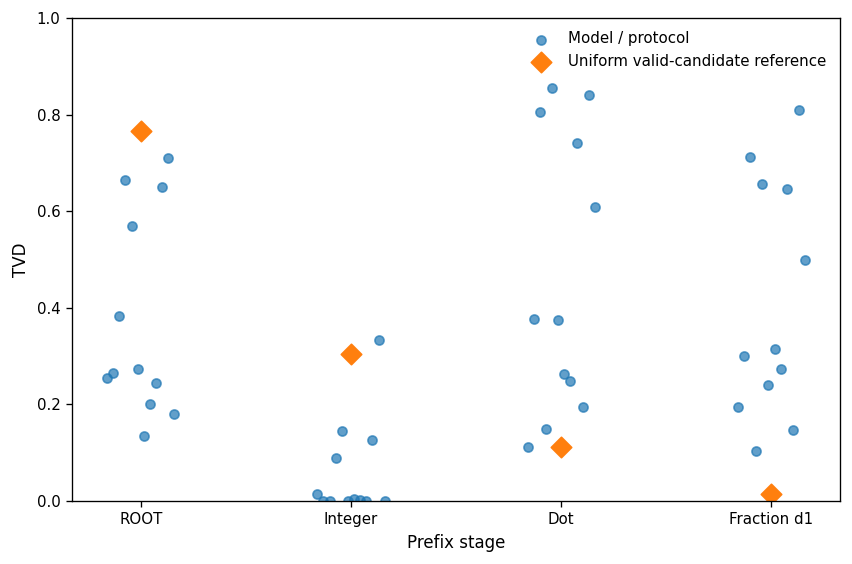

In [12]:
# Figure RQ1.C.1

fig, ax = plt.subplots(figsize=(7.2, 4.8))

stage_x = {
    stage: i
    for i, stage in enumerate(STAGE_ORDER_RQ1C)
}

# Individual model/protocol means
xs = []
ys = []

for stage in STAGE_ORDER_RQ1C:
    values = (
        rq1c_model_stage[
            rq1c_model_stage["stage"] == stage
        ]
        .set_index("model_id")
        .reindex(MODEL_ORDER)["model_tvd"]
        .to_numpy()
    )

    offsets = np.linspace(
        -0.16,
        0.16,
        len(values),
    )

    xs.extend(
        stage_x[stage] + offsets
    )
    ys.extend(values)

ax.scatter(
    xs,
    ys,
    s=30,
    alpha=0.7,
    label="Model / protocol",
)

# Uniform reference
baseline_values = (
    rq1c_model_stage
    .groupby("stage")["uniform_tvd"]
    .mean()
    .reindex(STAGE_ORDER_RQ1C)
)

ax.scatter(
    range(len(STAGE_ORDER_RQ1C)),
    baseline_values,
    marker="D",
    s=75,
    label="Uniform valid-candidate reference",
)

ax.set_xticks(
    range(len(STAGE_ORDER_RQ1C))
)
ax.set_xticklabels(
    STAGE_ORDER_RQ1C
)

ax.set_ylabel("TVD")
ax.set_xlabel("Prefix stage")

ax.set_ylim(0, 1)

ax.legend(
    frameon=False,
    loc="upper right",
)

fig.tight_layout()
plt.show()

**Figure RQ1.C.1.** Model conditional TVD relative to a uniform-over-valid-candidates reference across the primary prefix stages. Each small point represents one model/protocol condition averaged equally across the five canonical target distributions. Diamonds show the corresponding reference TVD. The reference performs poorly at ROOT and Integer, where analytic truth is strongly non-uniform, but becomes highly competitive at Dot and especially Fraction depth 1.

### Interpretation

The usefulness of a uniform valid-candidate reference depends strongly on the numerical stage.

At ROOT, analytic next-symbol probabilities are highly non-uniform, giving the uniform reference a mean TVD of 0.766. All twelve model/protocol conditions achieve lower average ROOT TVD, and the model outperforms the reference in 56 of the 60 individual model–distribution comparisons. A similar pattern appears at the Integer stage. Excluding the 24 structurally tied deterministic cases, the model outperforms the reference in 33 of the remaining 36 model–distribution comparisons.

The relationship reverses once the numerical continuation reaches decimal allocation. At the Dot stage, the uniform reference has mean TVD 0.111, compared with a mean model TVD of 0.464. All twelve model/protocol averages are worse than the reference, and 55 of the 60 individual model–distribution comparisons show larger model error.

The contrast is strongest at Fraction depth 1. Here, the analytic next-digit distributions are already very close to uniform: the reference has mean TVD 0.013. Nevertheless, mean model TVD is 0.407, and every one of the 60 model–distribution conditions performs worse than the uniform reference.

This stage dependence is hidden by the overall hierarchical averages. Across all four primary stages, the uniform reference has mean TVD of approximately 0.298, compared with approximately 0.327 across the evaluated models. The small difference between these overall means conceals an important reversal: models substantially outperform uniform allocation for coarse numerical decisions but introduce considerably more error than uniform allocation during decimal probability allocation.

### Result statement 
###### Main Text Candidate
A uniform-over-valid-candidates reference reveals that model alignment is strongly stage dependent. The evaluated models generally outperform uniform allocation at ROOT and non-deterministic Integer decisions, where analytic truth is strongly structured. This advantage disappears during decimal allocation: all twelve model/protocol conditions are worse than the reference on average at Dot and Fraction depth 1, and all 60 model–distribution conditions are worse at Fraction depth 1. Thus, the models recover useful coarse numerical structure but introduce substantial conditional preferences precisely where the analytically correct next-digit distribution is close to uniform.

### RQ1.C conclusion

The magnitude of TVD cannot be interpreted independently of the numerical decision being evaluated. Relative to a simple valid-candidate-uniform reference, the models contain useful information at early coarse stages but perform markedly worse during fine decimal allocation.

The reference therefore provides an interpretable scale for the primary TVD results while also motivating the stage-localised analysis developed in RQ2.

**Next:** RQ1.D asks whether poor probability calibration also implies poor ranking of the valid continuations, combining the previously completed Spearman analysis with a tie-aware top-1 diagnostic.

## RQ1.D — Conditional alignment versus ranking structure

TVD measures probability-magnitude mismatch. Spearman and tie-aware top-1 are used only as complementary ranking diagnostics, because preserving candidate ordering does not imply correct probability allocation.


In [13]:
# RQ1.D — Spearman ranking diagnostic

rq1d_primary = plain_df[
    plain_df["prefix_kind"].isin(["start", "integer", "dot"])
    | (
        (plain_df["prefix_kind"] == "fraction")
        & (plain_df["fraction_depth"] == 1)
    )
].copy()

rq1d_primary["stage"] = rq1d_primary["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction": "Fraction d1",
    }
)

# Mean Spearman within stage
rq1d_stage_spearman = (
    rq1d_primary
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        mean_spearman=("spearman_analytic_lm", "mean")
    )
)

# Equal-weight the available primary stages
rq1d_run_spearman = (
    rq1d_stage_spearman
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        mean_spearman=("mean_spearman", "mean")
    )
)

# Join with RQ1.A primary TVD
rq1d_condition_summary = (
    primary_run_summary
    .merge(
        rq1d_run_spearman[
            [
                "run_id",
                "model_id",
                "distribution",
                "mean_spearman",
            ]
        ],
        on=[
            "run_id",
            "model_id",
            "distribution",
        ],
        how="left",
    )
)

pearson_tvd_spearman = (
    rq1d_condition_summary[
        ["mean_tvd", "mean_spearman"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

rank_tvd_spearman = (
    rq1d_condition_summary[
        ["mean_tvd", "mean_spearman"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "TVD vs Spearman — Pearson:",
    round(pearson_tvd_spearman, 3),
)

print(
    "TVD vs Spearman — rank correlation:",
    round(rank_tvd_spearman, 3),
)

# Prefix-level availability of Spearman
spearman_coverage = (
    rq1d_primary
    .groupby("model_id")["spearman_analytic_lm"]
    .apply(lambda x: x.notna().mean())
    .reindex(MODEL_ORDER)
)

display(
    pd.DataFrame(
        {
            "Spearman coverage": spearman_coverage
        }
    ).round(3)
)

TVD vs Spearman — Pearson: -0.221
TVD vs Spearman — rank correlation: -0.244


,Spearman coverage
model_id,
S1,0.854
S2,0.854
S3,0.854
S4,0.854
S5,0.854
S6,0.854
M1,0.854
M2,0.854
M3,0.854


In [14]:
# RQ1.D — Tie-aware top-1 agreement

rq1d_tokens = token_df[
    token_df["prompt_type"] == "plain"
].copy()

rq1d_tokens["prefix"] = (
    rq1d_tokens["prefix"]
    .fillna("ROOT")
    .astype(str)
)

rq1d_tokens["fraction_depth"] = np.where(
    rq1d_tokens["prefix_kind"] == "fraction",
    rq1d_tokens["prefix"]
        .str.split(".")
        .str[1]
        .str.len(),
    np.nan,
)

rq1d_tokens = rq1d_tokens[
    rq1d_tokens["prefix_kind"].isin(
        ["start", "integer", "dot"]
    )
    | (
        (rq1d_tokens["prefix_kind"] == "fraction")
        & (rq1d_tokens["fraction_depth"] == 1)
    )
].copy()

rq1d_tokens["stage"] = (
    rq1d_tokens["prefix_kind"].map(
        {
            "start": "ROOT",
            "integer": "Integer",
            "dot": "Dot",
            "fraction": "Fraction d1",
        }
    )
)


def tie_aware_top1(group):
    truth = group["analytic_truth"].to_numpy()
    model = group["lm_prob"].to_numpy()

    truth_max = truth.max()
    model_max = model.max()

    truth_top = np.isclose(
        truth,
        truth_max,
        rtol=1e-10,
        atol=1e-12,
    )

    model_top = np.isclose(
        model,
        model_max,
        rtol=1e-10,
        atol=1e-12,
    )

    return pd.Series(
        {
            "top1_agreement": int(
                np.any(truth_top & model_top)
            ),
            "truth_top_ties": truth_top.sum(),
            "n_candidates": len(group),
        }
    )


rq1d_top1_prefix = (
    rq1d_tokens
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "prefix",
            "stage",
        ],
        as_index=False,
    )
    .apply(
        tie_aware_top1,
        include_groups=False,
    )
)

# Keep only prefixes where the analytic argmax
# does not contain every candidate
rq1d_top1_informative = rq1d_top1_prefix[
    rq1d_top1_prefix["truth_top_ties"]
    < rq1d_top1_prefix["n_candidates"]
].copy()

rq1d_top1_model = (
    rq1d_top1_informative
    .groupby("model_id", as_index=False)
    .agg(
        top1_agreement=("top1_agreement", "mean"),
        informative_prefixes=("top1_agreement", "size"),
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

display(rq1d_top1_model.round(3))

,top1_agreement,informative_prefixes
model_id,,
S1,0.632,38
S2,0.289,38
S3,0.289,38
S4,0.579,38
S5,0.579,38
S6,0.316,38
M1,0.289,38
M2,0.316,38
M3,0.342,38


In [15]:
rq1d_model_summary = (
    rq1d_condition_summary
    .groupby("model_id", as_index=False)
    .agg(
        mean_tvd=("mean_tvd", "mean"),
        mean_spearman=("mean_spearman", "mean"),
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

rq1d_model_summary = (
    rq1d_model_summary
    .join(
        rq1d_top1_model[
            ["top1_agreement"]
        ]
    )
)

rq1d_model_summary.index = [
    MODEL_LABELS[mid]
    for mid in rq1d_model_summary.index
]

display(
    rq1d_model_summary.rename(
        columns={
            "mean_tvd": "TVD",
            "mean_spearman": "Spearman",
            "top1_agreement": "Top-1 agreement",
        }
    ).round(3)
)

,TVD,Spearman,Top-1 agreement
Qwen3-4B Base · raw,0.143,0.669,0.632
Qwen3-4B Instruct · raw,0.235,0.560,0.289
Qwen3-4B Instruct · chat,0.475,0.481,0.289
Gemma-4-E4B Base · raw,0.251,0.585,0.579
Gemma-4-E4B IT · raw,0.556,0.521,0.579
Gemma-4-E4B IT · chat,0.222,0.563,0.316
Qwen3-14B Base · raw,0.178,0.618,0.289
Qwen3-14B · raw,0.180,0.650,0.316
Qwen3-14B · chat,0.407,0.586,0.342
Gemma-4-12B Base · raw,0.279,0.574,0.605


**Table RQ1.D.1.** Complementary views of next-symbol alignment under the plain-prompt baseline. TVD measures probability-magnitude discrepancy, Spearman measures relative candidate ordering, and tie-aware top-1 agreement measures whether the model's most-preferred continuation overlaps with the analytic argmax set. Top-1 agreement is reported only for informative prefixes where the analytic optimum does not include every valid candidate.

### Interpretation

Ranking diagnostics provide a different view of model behaviour from conditional TVD.

Across the 60 model–distribution conditions, the association between TVD and Spearman rank correlation is weak (Pearson $r=-0.221$; rank correlation $\rho=-0.244$). Conditions with larger probability-magnitude error therefore do not necessarily exhibit proportionally worse candidate ordering.

This distinction is also visible in the model-level summaries. Qwen3-4B Base raw performs well under all three diagnostics, combining the lowest primary TVD with the highest mean Spearman and highest informative top-1 agreement. Other conditions, however, show clear divergence between the metrics. For example, the Gemma Base conditions retain relatively high top-1 agreement despite substantially larger TVD, indicating that the analytically preferred continuation is often identified even when probability is incorrectly distributed across the complete candidate set.

Spearman is defined for 85.4% of the primary prefix observations. Its undefined cases correspond to the deterministic one-candidate Integer prefixes, for which a ranking correlation is not meaningful. Tie-aware top-1 is evaluated more conservatively on 79.2% of the primary prefixes, additionally excluding cases in which every analytic candidate is tied for the maximum.

Together, these diagnostics show that probabilistic calibration, full candidate ordering, and identification of the single most likely continuation are related but distinct properties. Poor TVD therefore cannot be interpreted automatically as complete loss of probability-order information.

In [16]:
# Secondary distributional-metric robustness

rq1d_secondary_stage = (
    rq1d_primary
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        tvd=("tv_analytic_lm", "mean"),
        kl=("kl_analytic_lm", "mean"),
        js=("js_analytic_lm", "mean"),
    )
)

rq1d_secondary = (
    rq1d_secondary_stage
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        tvd=("tvd", "mean"),
        kl=("kl", "mean"),
        js=("js", "mean"),
    )
)
print("Pearson correlation")
display(
    rq1d_secondary[
        ["tvd", "kl", "js"]
    ]
    .corr(method="pearson")
    .round(3)
)
print("Rank correlation")
display(
    rq1d_secondary[
        ["tvd", "kl", "js"]
    ]
    .corr(method="spearman")
    .round(3)
)

Pearson correlation


,tvd,kl,js
tvd,1.000,0.894,0.987
kl,0.894,1.000,0.910
js,0.987,0.910,1.000


Rank correlation


,tvd,kl,js
tvd,1.000,0.905,0.979
kl,0.905,1.000,0.936
js,0.979,0.936,1.000


In [17]:
# RQ1.D — Distribution of secondary divergence metrics

secondary_skew_summary = pd.DataFrame(
    {
        "Metric": [
            "KL — prefix level",
            "JS — prefix level",
            "KL — model × distribution",
            "JS — model × distribution",
        ],

        "Mean": [
            rq1d_primary["kl_analytic_lm"].mean(),
            rq1d_primary["js_analytic_lm"].mean(),
            rq1d_secondary["kl"].mean(),
            rq1d_secondary["js"].mean(),
        ],

        "Median": [
            rq1d_primary["kl_analytic_lm"].median(),
            rq1d_primary["js_analytic_lm"].median(),
            rq1d_secondary["kl"].median(),
            rq1d_secondary["js"].median(),
        ],

        "95th percentile": [
            rq1d_primary["kl_analytic_lm"].quantile(0.95),
            rq1d_primary["js_analytic_lm"].quantile(0.95),
            rq1d_secondary["kl"].quantile(0.95),
            rq1d_secondary["js"].quantile(0.95),
        ],

        "Maximum": [
            rq1d_primary["kl_analytic_lm"].max(),
            rq1d_primary["js_analytic_lm"].max(),
            rq1d_secondary["kl"].max(),
            rq1d_secondary["js"].max(),
        ],
    }
)

display(
    secondary_skew_summary.round(3)
)

,Metric,Mean,Median,95th percentile,Maximum
0,KL — prefix level,1.273,0.183,6.409,15.507
1,JS — prefix level,0.139,0.044,0.500,0.693
2,KL — model × distribution,1.299,0.552,4.039,5.469
3,JS — model × distribution,0.139,0.089,0.357,0.411


In [18]:
secondary_metric_summary = pd.DataFrame(
    {
        "Metric": ["KL", "JS"],

        "Median across 60 conditions": [
            rq1d_secondary["kl"].median(),
            rq1d_secondary["js"].median(),
        ],

        "Mean across 60 conditions": [
            rq1d_secondary["kl"].mean(),
            rq1d_secondary["js"].mean(),
        ],

        "Maximum": [
            rq1d_secondary["kl"].max(),
            rq1d_secondary["js"].max(),
        ],

        "Pearson with TVD": [
            rq1d_secondary[
                ["tvd", "kl"]
            ].corr(method="pearson").iloc[0, 1],

            rq1d_secondary[
                ["tvd", "js"]
            ].corr(method="pearson").iloc[0, 1],
        ],

        "Spearman with TVD": [
            rq1d_secondary[
                ["tvd", "kl"]
            ].corr(method="spearman").iloc[0, 1],

            rq1d_secondary[
                ["tvd", "js"]
            ].corr(method="spearman").iloc[0, 1],
        ],
    }
)

display(
    secondary_metric_summary.round(3)
)

,Metric,Median across 60 conditions,Mean across 60 conditions,Maximum,Pearson with TVD,Spearman with TVD
0,KL,0.552,1.299,5.469,0.894,0.905
1,JS,0.089,0.139,0.411,0.987,0.979


### Ranking-metric coverage

Spearman is defined for **41 of 48 primary prefixes per model (85.4%)**. The seven undefined cases are deterministic single-candidate Integer prefixes, where a rank correlation cannot be computed.

Tie-aware top-1 is evaluated on **38 of 48 primary prefixes per model (79.2%)**. In addition to the seven deterministic Integer prefixes, three Uniform Fraction-d1 prefixes are excluded because all analytic candidates are tied for the maximum, making any model argmax mechanically correct.


### Secondary distributional-metric robustness

KL and JS support the primary TVD result but are treated only as secondary diagnostics.

KL is strongly right-skewed. Across the primary prefix observations, mean KL is 1.273 while the median is only 0.183, and individual values reach 15.507. Even after hierarchical aggregation to the 60 model × distribution conditions, mean KL remains 1.299 compared with a median of 0.552.

KL is therefore reported median-first, with its mean or upper range retained only to indicate the severity of the right tail. A large mean KL should not be interpreted as representing a typical evaluated condition.

Despite this skew, KL broadly corroborates the TVD ordering. Across the 60 model × distribution conditions, its Pearson correlation with TVD is $r=0.894$ and its Spearman correlation is $\rho=0.905$.

JS is bounded and shows substantially less extreme scale behaviour. It is nevertheless highly redundant with TVD: Pearson correlation is $r=0.987$ and rank correlation is $\rho=0.979$. JS therefore adds little independent information to the primary alignment narrative and does not require a separate figure.

Together, these checks support TVD as the primary bounded measure of conditional distributional mismatch. KL is retained as a severity-sensitive robustness diagnostic, reported with robust summaries because of its right-skewed distribution, while JS mainly confirms the TVD pattern.

### Result statement
###### No plots required
### Secondary-metric result

Alternative distributional metrics corroborate rather than alter the primary TVD result. KL is strongly right-skewed: its median across the 60 model × distribution conditions is 0.552 compared with a mean of 1.299 and a maximum of 5.469. It nevertheless strongly tracks TVD in both magnitude and ordering ($r=0.894$, $\rho=0.905$). JS is even more closely associated with TVD ($r=0.987$, $\rho=0.979$) and therefore contributes little additional ranking information. TVD remains the primary metric, with KL retained as a median-first severity-sensitive robustness diagnostic.

### RQ1.D conclusion

The RQ1 alignment failure is primarily a failure of probability allocation, but it does not imply that all relative probability information is lost. Models can preserve parts of the correct ordering or identify the most likely continuation while still assigning substantially incorrect probability magnitudes.

**Next:** RQ1.E separates this conditional alignment question from numerical compliance, asking how much probability the model assigns to the valid numerical continuation space before renormalisation.

## RQ1.E — Numerical compliance versus conditional alignment

### Question

Is conditional probabilistic misalignment mainly associated with the model failing to place probability on valid numerical continuations, or can substantial alignment error remain even when numerical compliance is high?

### Motivation

The evaluation framework measures two distinct quantities.

First, the valid candidate mass

$$
M_{\text{valid}}(r)
$$

records how much of the model's raw vocabulary probability lies on the valid numerical candidate set before renormalisation.

Second, conditional TVD is computed only after restricting the model distribution to this candidate set and renormalising:

$$
P_{\text{LM}}^*(c\mid r)
=
\frac{P_{\text{LM}}(c\mid r)}
{\sum_{c' \in \mathcal C_r}P_{\text{LM}}(c'\mid r)}.
$$

Therefore, numerical compliance and conditional probabilistic alignment are structurally distinct outcomes.

For easier visual comparison, numerical non-compliance is expressed as

$$
1-M_{\text{valid}},
$$

the probability mass lying outside the valid candidate set. Both this quantity and TVD then have the same interpretation: lower values are better.

RQ1.E asks whether these two dimensions move together or whether models can fail in one dimension while performing well in the other.

In [19]:
# RQ1.E — Numerical compliance under the same primary hierarchy

rq1e_primary = plain_df[
    plain_df["prefix_kind"].isin(
        ["start", "integer", "dot"]
    )
    | (
        (plain_df["prefix_kind"] == "fraction")
        & (plain_df["fraction_depth"] == 1)
    )
].copy()

rq1e_primary["stage"] = (
    rq1e_primary["prefix_kind"].map(
        {
            "start": "ROOT",
            "integer": "Integer",
            "dot": "Dot",
            "fraction": "Fraction d1",
        }
    )
)

# Average prefixes within each stage
rq1e_stage_mass = (
    rq1e_primary
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        valid_mass=("valid_candidate_mass", "mean")
    )
)

# Give the four primary stages equal weight
rq1e_run_mass = (
    rq1e_stage_mass
    .groupby(
        [
            "run_id",
            "model_id",
            "model_label",
            "distribution",
        ],
        as_index=False,
    )
    .agg(
        valid_mass=("valid_mass", "mean")
    )
)

rq1e_run_mass["outside_valid_mass"] = (
    1 - rq1e_run_mass["valid_mass"]
)

In [20]:
# Combine the two RQ1 outcomes at the same model × distribution level

rq1e_joint = (
    primary_run_summary
    .merge(
        rq1e_run_mass[
            [
                "run_id",
                "model_id",
                "distribution",
                "valid_mass",
                "outside_valid_mass",
            ]
        ],
        on=[
            "run_id",
            "model_id",
            "distribution",
        ],
        how="inner",
    )
)

rq1e_model_summary = (
    rq1e_joint
    .groupby("model_id", as_index=False)
    .agg(
        valid_mass=("valid_mass", "mean"),
        outside_valid_mass=("outside_valid_mass", "mean"),
        conditional_tvd=("mean_tvd", "mean"),
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

rq1e_model_summary["model_label"] = [
    MODEL_LABELS[mid]
    for mid in rq1e_model_summary.index
]

display(
    rq1e_model_summary[
        [
            "model_label",
            "valid_mass",
            "outside_valid_mass",
            "conditional_tvd",
        ]
    ].round(3)
)

,model_label,valid_mass,outside_valid_mass,conditional_tvd
model_id,,,,
S1,Qwen3-4B Base · raw,0.820,0.180,0.143
S2,Qwen3-4B Instruct · raw,0.992,0.008,0.235
S3,Qwen3-4B Instruct · chat,1.000,0.000,0.475
S4,Gemma-4-E4B Base · raw,0.682,0.318,0.251
S5,Gemma-4-E4B IT · raw,0.212,0.788,0.556
S6,Gemma-4-E4B IT · chat,1.000,0.000,0.222
M1,Qwen3-14B Base · raw,0.939,0.061,0.178
M2,Qwen3-14B · raw,0.762,0.238,0.180
M3,Qwen3-14B · chat,1.000,0.000,0.407


**Table RQ1.E.1.** Numerical compliance and conditional probabilistic alignment under the plain-prompt baseline. Valid candidate mass is measured before renormalisation, while conditional TVD is calculated after restricting the model distribution to the valid numerical candidate set. Outside-valid mass is $1-M_{\text{valid}}$. Lower outside-valid mass and lower TVD indicate better performance, but the two quantities measure different aspects of numerical prediction.

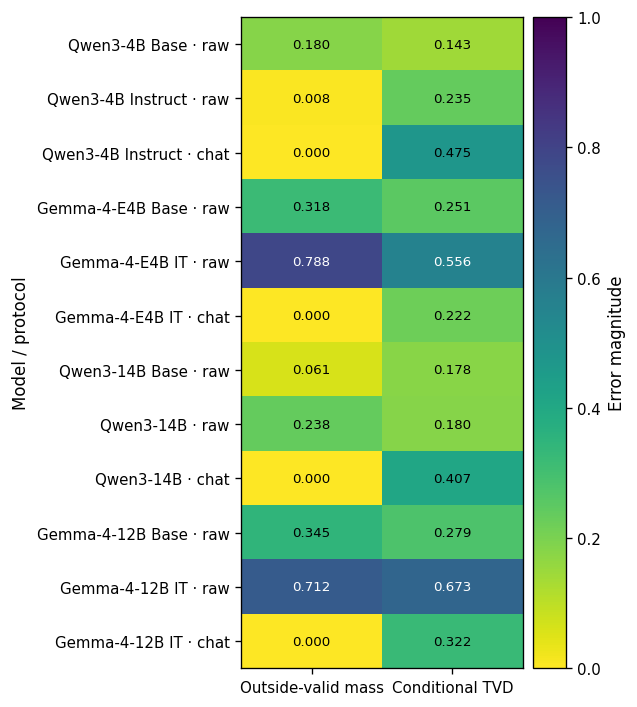

In [21]:
rq1e_plot = (
    rq1e_model_summary[
        [
            "outside_valid_mass",
            "conditional_tvd",
        ]
    ]
    .copy()
)

rq1e_plot.index = rq1e_model_summary[
    "model_label"
]

rq1e_plot.columns = [
    "Outside-valid mass",
    "Conditional TVD",
]


fig, ax = plt.subplots(
    figsize=(5.2, 6.0)
)

im = ax.imshow(
    rq1e_plot,
    aspect="auto",
    cmap="viridis_r",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    range(rq1e_plot.shape[1])
)
ax.set_xticklabels(
    rq1e_plot.columns
)

ax.set_yticks(
    range(rq1e_plot.shape[0])
)
ax.set_yticklabels(
    rq1e_plot.index
)

ax.set_ylabel("Model / protocol")

for i in range(rq1e_plot.shape[0]):
    for j in range(rq1e_plot.shape[1]):
        value = rq1e_plot.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if im.norm(value) > 0.55
                else "black"
            ),
        )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.03,
)

cbar.set_label("Error magnitude")

fig.tight_layout()
plt.show()

**Figure RQ1.E.1.** Two dimensions of numerical prediction error across model/protocol conditions. Outside-valid mass measures the probability assigned outside the valid numerical candidate set before renormalisation, while conditional TVD measures the mismatch in probability allocation after conditioning on valid numerical continuations. Both quantities range from 0 to 1 and are shown on the same scale, with lower values indicating better performance.

### Interpretation

Numerical compliance and conditional probabilistic alignment differ substantially across the evaluated conditions and do not reduce to the same failure mode.

Valid candidate mass ranges from approximately 0.21 to 1.00 across the twelve model/protocol conditions. Some raw Gemma instruction-tuned conditions place most of their vocabulary probability outside the valid numerical continuation space. Gemma-4-E4B IT raw assigns only 0.212 of its probability mass to valid candidates on average, while Gemma-4-12B IT raw assigns 0.288. Both conditions also exhibit large conditional TVD, indicating failure both before and after conditioning on numerical continuation.

Other conditions show the opposite pattern. The chat-evaluated Qwen conditions place essentially all probability mass on valid numerical candidates, yet their conditional TVD remains high: 0.475 for Qwen3-4B Instruct chat and 0.407 for Qwen3-14B chat. These models therefore exhibit strong numerical compliance without correspondingly accurate probability allocation within the valid set.

High valid-candidate mass is therefore not sufficient for probabilistic alignment. The framework distinguishes whether the model remains within the numerical continuation space from whether it assigns the correct relative probabilities once that space is reached.

The protocol dependence visible in these values is analysed formally under RQ4. At this stage, the important RQ1 conclusion is only that compliance and conditional alignment capture distinct aspects of model behaviour.

### Result statement

Numerical compliance and conditional probabilistic alignment are distinct aspects of model behaviour. Valid candidate mass varies from approximately 0.21 to 1.00 across the evaluated conditions, and high compliance does not guarantee accurate conditional probabilities. Several chat-evaluated conditions place essentially all probability mass on valid numerical continuations while retaining substantial TVD, whereas some raw instruction-tuned Gemma conditions perform poorly on both dimensions. Conditional alignment error therefore cannot be explained solely by probability mass leaving the valid numerical continuation space.

### RQ1.E conclusion

The RQ1 alignment result reflects more than a failure to produce valid numerical continuations. Even when the model commits almost all probability mass to the valid candidate set, substantial mismatch can remain in how that probability is distributed among the possible continuations.

This distinction motivates a stage-localised analysis of both conditional error and numerical compliance in RQ2.

# RQ1 — Overall conclusion

Across the canonical main-grid conditions, LLM next-symbol probabilities show substantial but highly condition-dependent deviation from analytically derived conditional probabilities.

The primary hierarchical TVD result is robust to removing deterministic single-candidate states: excluding these prefixes increases absolute error but leaves the ordering of all twelve model/protocol conditions unchanged.

A uniform-over-valid-candidates reference further shows that alignment depends strongly on the kind of numerical decision being made. Models generally outperform uniform allocation during coarse ROOT and Integer decisions, but become markedly worse than the same simple reference during Dot and Fraction depth-1 allocation.

Ranking diagnostics reveal that this calibration failure does not imply complete loss of probability-order information. TVD is only weakly associated with Spearman rank alignment, and models can retain the analytically preferred continuation despite inaccurate probability magnitudes.

Finally, numerical compliance and conditional alignment are distinct. Some models assign almost all probability mass to valid numerical continuations while still exhibiting substantial conditional TVD. The observed probabilistic misalignment therefore cannot be reduced either to deterministic states, to incorrect ranking alone, or to failure to remain within the numerical continuation space.

Together, these results establish the baseline phenomenon addressed by RQ1. RQ2 next localises these failures across the numerical continuation process and examines what form the probability mismatch takes at different stages.

# RQ2 — Prefix-Stage Localisation of Failure

**RQ2:** At which stages of numerical continuation does probabilistic alignment between the LLM and the analytical target succeed or break down?

RQ1 established that conditional next-symbol alignment is imperfect overall. RQ2 now localises that mismatch within the numerical representation.

The stage taxonomy is diagnostic rather than a mandatory generation sequence:

$$
\text{ROOT}
\rightarrow
\text{Sign}
\rightarrow
\text{Integer}
\rightarrow
\text{Dot}
\rightarrow
\text{Fraction}.
$$

ROOT, Integer, Dot, and Fraction depth 1 form the primary shared stage analysis. Sign is treated separately because it is only defined for target settings that permit the corresponding negative branch. Fraction depth 2 remains supplementary.

## RQ2.A — Where does conditional alignment fail?

### Question

At which numerical stages is conditional next-symbol alignment relatively good or poor, and is the stage profile shared across model/protocol conditions?

### Analysis choice

For stage localisation, the analysis is restricted to prefixes with more than one valid candidate:

$$
|\mathcal C_r|>1.
$$

This differs deliberately from the primary RQ1 estimand.

When $|\mathcal C_r|=1$, conditional TVD is necessarily zero after renormalisation. Such a state remains meaningful for overall numerical behaviour, but it does not test probability allocation between competing continuations. Including these states in a stage-difficulty comparison would therefore mechanically make some stages appear easier.

Fraction depth 1 is used as the primary fractional stage. Sign is reported separately because it is only applicable to the relevant signed-support distributions.

Stage means are first calculated within each model/protocol × distribution condition and are then averaged equally across the distributions for which that stage contains a non-trivial decision. Structural absence is retained as absence rather than replaced with zero.

In [22]:
# RQ2.A — Non-trivial primary stage dataset

if "n_valid_candidates" not in plain_df.columns:
    token_counts = (
        token_df[
            token_df["prompt_type"] == "plain"
        ]
        .assign(
            prefix_key=lambda x:
                x["prefix"].fillna("ROOT").astype(str)
        )
        .groupby(
            ["run_id", "prefix_key"]
        )
        .size()
        .rename("n_valid_candidates")
        .reset_index()
    )

    plain_df = plain_df.copy()

    plain_df["prefix_key"] = (
        plain_df["prefix"]
        .fillna("ROOT")
        .astype(str)
    )

    plain_df = plain_df.merge(
        token_counts,
        on=["run_id", "prefix_key"],
        how="left",
    )


rq2a = plain_df.copy()

if "fraction_depth" not in rq2a.columns:
    prefix_string = (
        rq2a["prefix"]
        .fillna("ROOT")
        .astype(str)
    )

    rq2a["fraction_depth"] = np.where(
        rq2a["prefix_kind"] == "fraction",
        prefix_string.str.split(".").str[1].str.len(),
        np.nan,
    )


rq2a = rq2a[
    rq2a["prefix_kind"].isin(
        ["start", "integer", "dot"]
    )
    | (
        (rq2a["prefix_kind"] == "fraction")
        & (rq2a["fraction_depth"] == 1)
    )
].copy()

# Genuine conditional allocation decisions only
rq2a = rq2a[
    rq2a["n_valid_candidates"] > 1
].copy()

rq2a["stage"] = rq2a["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction": "Fraction d1",
    }
)

STAGE_ORDER_RQ2A = [
    "ROOT",
    "Integer",
    "Dot",
    "Fraction d1",
]

In [23]:
rq2a_coverage = (
    rq2a
    .groupby(
        ["distribution", "stage"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(DISTRIBUTION_ORDER)
    .reindex(
        columns=STAGE_ORDER_RQ2A,
        fill_value=0,
    )
)

display(rq2a_coverage)

stage,ROOT,Integer,Dot,Fraction d1
distribution,,,,
normal,12,24,48,48
uniform,12,0,12,36
exponential,12,24,36,36
beta,12,0,12,36
laplace,12,24,48,48


In [24]:
# First level:
# prefixes within model × distribution × stage

rq2a_distribution_stage = (
    rq2a
    .groupby(
        [
            "model_id",
            "model_label",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=("tv_analytic_lm", "mean")
    )
)


# Second level:
# distributions contribute equally where the stage is defined

rq2a_model_stage = (
    rq2a_distribution_stage
    .groupby(
        [
            "model_id",
            "model_label",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        stage_tvd=("stage_tvd", "mean"),
        distributions_available=(
            "distribution",
            "nunique",
        ),
    )
)


rq2a_matrix = (
    rq2a_model_stage
    .pivot(
        index="model_id",
        columns="stage",
        values="stage_tvd",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=STAGE_ORDER_RQ2A,
    )
)

display(rq2a_matrix.round(3))

stage,ROOT,Integer,Dot,Fraction d1
model_id,,,,
S1,0.254,0.038,0.112,0.195
S2,0.264,0.000,0.377,0.299
S3,0.383,0.000,0.806,0.711
S4,0.664,0.255,0.148,0.102
S5,0.569,0.474,0.854,0.657
S6,0.273,0.000,0.375,0.240
M1,0.133,0.011,0.261,0.314
M2,0.201,0.005,0.247,0.272
M3,0.244,0.000,0.741,0.645


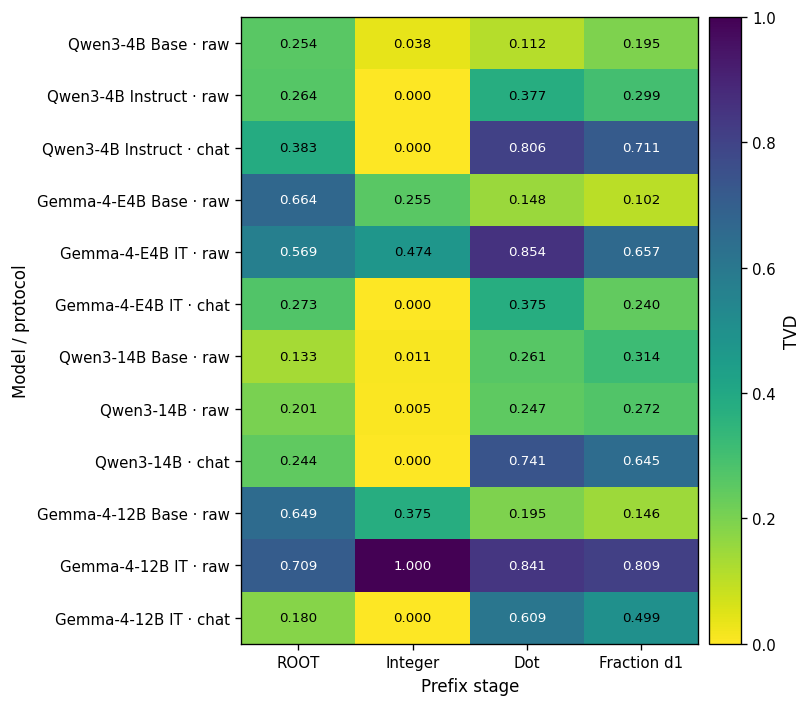

In [25]:
plot_data = rq2a_matrix.copy()

plot_data.index = [
    MODEL_LABELS[mid]
    for mid in plot_data.index
]

fig, ax = plt.subplots(
    figsize=(6.8, 6.0)
)

im = ax.imshow(
    plot_data,
    aspect="auto",
    cmap="viridis_r",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    range(len(plot_data.columns))
)
ax.set_xticklabels(
    plot_data.columns
)

ax.set_yticks(
    range(len(plot_data.index))
)
ax.set_yticklabels(
    plot_data.index
)

ax.set_xlabel("Prefix stage")
ax.set_ylabel("Model / protocol")

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if im.norm(value) > 0.55
                    else "black"
                ),
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
)

cbar.set_label("TVD")

fig.tight_layout()
plt.show()

**Figure RQ2.A.1.** Conditional probability mismatch across primary numerical stages under the plain-prompt baseline. Values show mean TVD for non-trivial prefixes after first averaging within each model/protocol × distribution × stage condition and then averaging equally across distributions for which that stage contains multiple valid continuations. Fraction refers to depth 1. Lower TVD indicates closer alignment with analytic truth.

In [26]:
rq2a_stage_summary = (
    rq2a_distribution_stage
    .groupby("stage")
    .agg(
        mean_tvd=("stage_tvd", "mean"),
        min_tvd=("stage_tvd", "min"),
        max_tvd=("stage_tvd", "max"),
        model_distribution_cells=(
            "stage_tvd",
            "size",
        ),
    )
    .reindex(STAGE_ORDER_RQ2A)
)

display(
    rq2a_stage_summary.round(3)
)

,mean_tvd,min_tvd,max_tvd,model_distribution_cells
stage,,,,
ROOT,0.377,0.000,0.992,60
Integer,0.180,0.000,1.000,36
Dot,0.464,0.085,0.969,60
Fraction d1,0.407,0.037,0.866,60


In [27]:
rq2a_sign = plain_df[
    (plain_df["prefix_kind"] == "sign")
    & (plain_df["n_valid_candidates"] > 1)
].copy()

rq2a_sign_summary = (
    rq2a_sign
    .groupby(
        ["model_id", "model_label"],
        as_index=False,
    )
    .agg(
        sign_tvd=("tv_analytic_lm", "mean")
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

display(
    rq2a_sign_summary[
        ["model_label", "sign_tvd"]
    ].round(3)
)

,model_label,sign_tvd
model_id,,
S1,Qwen3-4B Base · raw,0.082
S2,Qwen3-4B Instruct · raw,0.340
S3,Qwen3-4B Instruct · chat,0.283
S4,Gemma-4-E4B Base · raw,0.429
S5,Gemma-4-E4B IT · raw,0.242
S6,Gemma-4-E4B IT · chat,0.340
M1,Qwen3-14B Base · raw,0.150
M2,Qwen3-14B · raw,0.070
M3,Qwen3-14B · chat,0.333


### Interpretation

The stage-localised results do not show a common progression in which conditional alignment steadily deteriorates as more of the number is generated. Instead, the location of the mismatch depends strongly on the model/protocol condition.

Marginally, the Integer stage has the lowest mean non-trivial TVD (0.180), while Dot has the highest (0.464), followed by Fraction depth 1 (0.407) and ROOT (0.377). These averages, however, conceal substantial heterogeneity. Integer-stage TVD ranges from essentially zero for several conditions to 1.000 for Gemma-4-12B IT raw. Similarly, Dot and Fraction depth-1 errors vary widely across models.

Distinct stage profiles are visible across model families and protocols. Both chat-evaluated Qwen conditions remain relatively well aligned at the non-trivial Integer stage but show large mismatch at Dot and Fraction depth 1. By contrast, the Gemma Base conditions show large ROOT mismatch followed by substantially lower error at later stages. The raw instruction-tuned Gemma conditions, especially Gemma-4-12B IT, exhibit broader mismatch spanning several stages.

Overall TVD therefore does not correspond to a single common failure mode. Similar aggregate alignment errors can arise from substantially different locations within the numerical continuation process. Stage-level marginal averages should consequently be interpreted only as orientation; the model/protocol interaction is central to the RQ2 result.

### Result statement

Conditional probabilistic mismatch is strongly stage- and model-dependent rather than following a universal left-to-right deterioration through numerical generation. Some conditions are poorly aligned at ROOT but substantially improve at later stages, whereas others recover coarse Integer decisions and then show large Dot and Fraction depth-1 errors. The same stage can range from near-perfect to near-maximal mismatch across model/protocol conditions, demonstrating that aggregate TVD hides qualitatively different stage-localised failure profiles.

### RQ2.A conclusion

RQ2.A localises the baseline alignment failure but shows that stage alone is insufficient to explain it. There is no single numerical stage at which all evaluated models fail. Instead, stage interacts strongly with model family and evaluation protocol.

The remaining RQ2 analyses therefore examine what kind of probability error occurs at these stages rather than simply comparing their TVD levels.

**Next:** RQ2.B examines the concentration of the conditional distributions, asking whether stage-level mismatch reflects model probabilities that are too sharp or too diffuse relative to analytic truth.

## RQ2.B — Over- and under-concentration of conditional probability

### Question

When conditional next-symbol probabilities differ from analytic truth, is the model distribution systematically too concentrated or too diffuse?

### Motivation

TVD identifies the magnitude of a probability-distribution mismatch but does not describe its shape.

To distinguish between overly concentrated and overly diffuse model distributions, we compare the entropy of the renormalised model distribution with the entropy of analytic truth:

$$
\Delta H(r)
=
H(P_{\text{LM}}^*(\cdot\mid r))
-
H(P_{\text{truth}}(\cdot\mid r)).
$$

Interpretation:

- $\Delta H < 0$: the model distribution is more concentrated than analytic truth.
- $\Delta H > 0$: the model distribution is more diffuse than analytic truth.
- $\Delta H = 0$: the two distributions have equal entropy, although they need not have the same probability allocation.

Because the number of valid candidates can differ between prefixes, the primary diagnostic uses entropy normalised by the maximum possible entropy for that candidate set:

$$
H_{\text{norm}}(P)
=
\frac{H(P)}{\log |\mathcal C_r|},
$$

and

$$
\Delta H_{\text{norm}}
=
H_{\text{norm}}(P_{\text{LM}}^*)
-
H_{\text{norm}}(P_{\text{truth}}).
$$

As in RQ2.A, the analysis is restricted to non-trivial prefixes with more than one valid candidate, and Fraction depth 1 is used for the primary fractional stage.

In [28]:
# RQ2.B — Entropy / concentration diagnostic
# Reuse the non-trivial primary-stage dataset from RQ2.A

rq2b = rq2a.copy()

rq2b["entropy_analytic_norm"] = (
    rq2b["entropy_analytic"]
    / np.log(rq2b["n_valid_candidates"])
)

rq2b["entropy_lm_norm"] = (
    rq2b["entropy_lm"]
    / np.log(rq2b["n_valid_candidates"])
)

rq2b["entropy_gap_norm"] = (
    rq2b["entropy_lm_norm"]
    - rq2b["entropy_analytic_norm"]
)


# First average prefixes within model × distribution × stage
rq2b_distribution_stage = (
    rq2b
    .groupby(
        [
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        analytic_entropy=("entropy_analytic", "mean"),
        lm_entropy=("entropy_lm", "mean"),
        entropy_gap=("entropy_gap_lm_minus_analytic", "mean"),
        analytic_entropy_norm=("entropy_analytic_norm", "mean"),
        lm_entropy_norm=("entropy_lm_norm", "mean"),
        entropy_gap_norm=("entropy_gap_norm", "mean"),
        stage_tvd=("tv_analytic_lm", "mean"),
    )
)


# Then average distributions equally for each model × stage
rq2b_model_stage = (
    rq2b_distribution_stage
    .groupby(
        ["model_id", "stage"],
        as_index=False,
    )
    .agg(
        analytic_entropy_norm=("analytic_entropy_norm", "mean"),
        lm_entropy_norm=("lm_entropy_norm", "mean"),
        entropy_gap_norm=("entropy_gap_norm", "mean"),
        stage_tvd=("stage_tvd", "mean"),
        distributions_available=("distribution", "nunique"),
    )
)

In [29]:
rq2b_stage_summary = (
    rq2b_distribution_stage
    .groupby("stage")
    .agg(
        analytic_entropy=("analytic_entropy", "mean"),
        lm_entropy=("lm_entropy", "mean"),
        entropy_gap=("entropy_gap", "mean"),
        analytic_entropy_norm=("analytic_entropy_norm", "mean"),
        lm_entropy_norm=("lm_entropy_norm", "mean"),
        entropy_gap_norm=("entropy_gap_norm", "mean"),
        mean_tvd=("stage_tvd", "mean"),
    )
    .reindex(STAGE_ORDER_RQ2A)
)

display(rq2b_stage_summary.round(3))

,analytic_entropy,lm_entropy,entropy_gap,analytic_entropy_norm,lm_entropy_norm,entropy_gap_norm,mean_tvd
stage,,,,,,,
ROOT,0.667,0.792,0.125,0.282,0.337,0.056,0.377
Integer,0.001,0.280,0.279,0.000,0.117,0.116,0.180
Dot,2.255,1.363,-0.892,0.979,0.592,-0.387,0.464
Fraction d1,2.301,1.597,-0.704,0.999,0.694,-0.306,0.407


In [30]:
rq2b_matrix = (
    rq2b_model_stage
    .pivot(
        index="model_id",
        columns="stage",
        values="entropy_gap_norm",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=STAGE_ORDER_RQ2A,
    )
)

display(rq2b_matrix.round(3))

stage,ROOT,Integer,Dot,Fraction d1
model_id,,,,
S1,0.367,0.100,-0.023,-0.071
S2,0.179,-0.000,-0.251,-0.163
S3,-0.282,-0.000,-0.831,-0.664
S4,0.475,0.423,-0.034,-0.025
S5,0.164,0.224,-0.918,-0.560
S6,-0.241,-0.000,-0.222,-0.103
M1,0.019,0.034,-0.121,-0.162
M2,0.046,0.017,-0.110,-0.164
M3,-0.238,-0.000,-0.716,-0.563


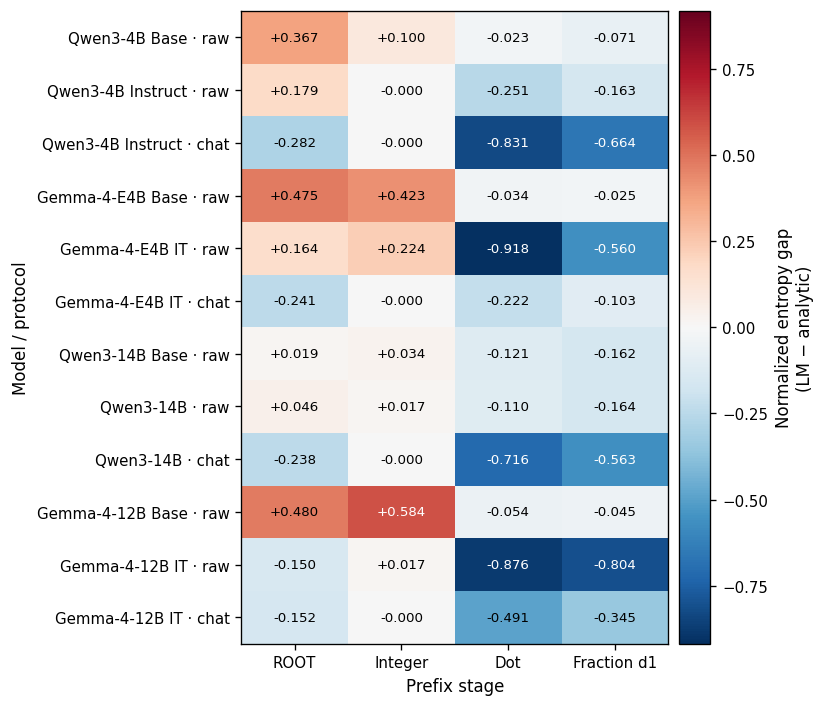

In [31]:
from matplotlib.colors import TwoSlopeNorm

plot_data = rq2b_matrix.copy()

plot_data.index = [
    MODEL_LABELS[mid]
    for mid in plot_data.index
]

max_abs = np.nanmax(
    np.abs(plot_data.to_numpy())
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs,
)

fig, ax = plt.subplots(
    figsize=(6.8, 6.0)
)

im = ax.imshow(
    plot_data,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
)

ax.set_xticks(
    range(len(plot_data.columns))
)
ax.set_xticklabels(
    plot_data.columns
)

ax.set_yticks(
    range(len(plot_data.index))
)
ax.set_yticklabels(
    plot_data.index
)

ax.set_xlabel("Prefix stage")
ax.set_ylabel("Model / protocol")

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if abs(value) > 0.55 * max_abs
                    else "black"
                ),
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Normalized entropy gap\n"
    "(LM − analytic)"
)

fig.tight_layout()
plt.show()

**Figure RQ2.B.1.** Difference between model and analytic normalized conditional entropy across primary numerical stages. Positive values indicate model distributions that are more diffuse than analytic truth, while negative values indicate greater model concentration. Values are calculated on non-trivial prefixes, first averaged within model/protocol × distribution × stage and then averaged equally across available distributions. Fraction refers to depth 1.

In [32]:
rq2b_direction = (
    rq2b_distribution_stage
    .assign(
        direction=lambda x: np.select(
            [
                x["entropy_gap_norm"] < -1e-12,
                x["entropy_gap_norm"] > 1e-12,
            ],
            [
                "More concentrated",
                "More diffuse",
            ],
            default="Approximately equal",
        )
    )
    .groupby(
        ["stage", "direction"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(STAGE_ORDER_RQ2A)
)

display(rq2b_direction)

direction,Approximately equal,More concentrated,More diffuse
stage,,,
ROOT,0,27,33
Integer,1,10,25
Dot,0,58,2
Fraction d1,0,60,0


In [33]:
rq2b_correlation = []

for stage in STAGE_ORDER_RQ2A:
    x = rq2b_distribution_stage[
        rq2b_distribution_stage["stage"] == stage
    ].copy()

    x["abs_entropy_gap_norm"] = (
        x["entropy_gap_norm"].abs()
    )

    rq2b_correlation.append(
        {
            "stage": stage,
            "pearson": x[
                [
                    "abs_entropy_gap_norm",
                    "stage_tvd",
                ]
            ].corr(method="pearson").iloc[0, 1],
            "spearman": x[
                [
                    "abs_entropy_gap_norm",
                    "stage_tvd",
                ]
            ].corr(method="spearman").iloc[0, 1],
        }
    )

display(
    pd.DataFrame(rq2b_correlation).round(3)
)

,stage,pearson,spearman
0,ROOT,0.714,0.739
1,Integer,0.338,0.857
2,Dot,0.985,0.984
3,Fraction d1,0.987,0.990


### Interpretation

The entropy analysis reveals a strong change in the form of the probability mismatch across numerical stages.

The analytic target itself has very different concentration structure at different stages. Non-trivial Integer decisions are almost deterministic, with normalized analytic entropy close to zero. By contrast, the analytic distributions at Dot and Fraction depth 1 are close to maximally diffuse, with mean normalized entropies of 0.979 and 0.999 respectively.

The models do not reproduce this change consistently. ROOT behaviour is heterogeneous: some model/protocol conditions are more diffuse than analytic truth, while others are more concentrated. Integer behaviour is also mixed, although model distributions are more often too diffuse relative to the highly concentrated analytic target.

A much more consistent pattern appears after the decimal point. At Dot, 58 of the 60 model–distribution conditions are more concentrated than analytic truth. At Fraction depth 1, all 60 conditions have lower entropy than the corresponding analytic distribution. The mean normalized entropy deficit is −0.387 at Dot and −0.306 at Fraction depth 1.

The magnitude of this concentration mismatch also closely tracks TVD at the decimal stages. Across model–distribution cells, the absolute normalized entropy gap correlates with TVD at approximately $r=0.985$ for Dot and $r=0.987$ for Fraction depth 1. Thus, the large decimal-stage TVD observed in RQ2.A is strongly associated with model distributions that are too concentrated relative to the nearly diffuse analytic targets.

The degree of over-concentration nevertheless remains model/protocol dependent. Chat-evaluated Qwen conditions and raw instruction-tuned Gemma conditions show particularly large entropy deficits, whereas the Gemma Base conditions remain much closer to the analytic entropy at Dot and Fraction depth 1. Entropy therefore identifies a common shape of decimal-stage error without removing the interaction structure observed in RQ2.A.

### Result statement
###### RQ2.B.1 as a main-text candidate alongside the RQ2.A stage-TVD heatmap.
Stage-level alignment errors differ systematically in their concentration structure. ROOT and Integer behaviour is heterogeneous, but decimal-stage errors show a consistent tendency toward over-concentration. At Dot, 58 of 60 model–distribution conditions have lower normalized entropy than analytic truth, while all 60 conditions are more concentrated at Fraction depth 1. The analytic fractional distributions are themselves almost maximally diffuse, indicating that the models introduce strong conditional preferences where the mathematically correct next-digit allocation is close to uniform.

### RQ2.B conclusion

The high Dot and Fraction depth-1 TVD observed in RQ2.A has a consistent distributional signature: model probabilities become too concentrated relative to analytic truth. Earlier numerical stages do not exhibit the same universal pattern.

Entropy identifies the form of this mismatch but not the candidates receiving the excess probability. Later token-level analyses therefore examine which signs, formatting symbols, and digits generate this concentration.

**Next:** RQ2.C examines an exact early-stage case by comparing the model probability assigned to the negative sign at ROOT with the analytic value for the symmetric Normal and Laplace targets.

## RQ2.C — ROOT sign allocation under symmetric targets

### Question

When the analytic target is symmetric around zero, does the model assign the correct conditional probability to beginning the number with a negative sign?

### Motivation

For the canonical Normal and Laplace targets used in the main grid, symmetry implies that exactly half of the probability mass lies on the negative branch. At ROOT,

$$
P_{\text{truth}}(- \mid \text{ROOT}) = 0.5.
$$

This provides a particularly interpretable stage-level diagnostic because the model probability can be compared directly with an exact mathematical reference rather than only through an aggregate distance metric.

The analysis uses the renormalised model probability `lm_prob`, so the quantity being evaluated is

$$
P_{\text{LM}}^*(- \mid \text{ROOT}),
$$

conditional on the valid numerical candidate set.

This should not be confused with `lm_prob_unconditional`, which measures raw vocabulary probability before renormalisation and therefore also reflects numerical compliance. Compliance is analysed separately in the following RQ2 block.

Define the signed deviation

$$
\Delta_{-}
=
P_{\text{LM}}^*(- \mid \text{ROOT}) - 0.5.
$$

Negative values indicate under-allocation to the negative branch, while positive values indicate over-allocation.

In [34]:
# RQ2.C — Conditional probability assigned to "-" at ROOT

rq2c = token_df[
    (token_df["prompt_type"] == "plain")
    & (token_df["prefix_kind"] == "start")
    & (token_df["distribution"].isin(["normal", "laplace"]))
    & (token_df["token"] == "-")
].copy()

# Analytic reference should be exactly 0.5
display(
    rq2c[
        [
            "distribution",
            "analytic_truth",
        ]
    ]
    .drop_duplicates()
    .sort_values("distribution")
)

rq2c["sign_deviation"] = (
    rq2c["lm_prob"] - 0.5
)

rq2c["abs_sign_deviation"] = (
    rq2c["sign_deviation"].abs()
)

,distribution,analytic_truth
900,laplace,0.5
0,normal,0.5


In [35]:
rq2c_prob = (
    rq2c
    .pivot(
        index="model_id",
        columns="distribution",
        values="lm_prob",
    )
    .reindex(MODEL_ORDER)
)

rq2c_summary = rq2c_prob.copy()

rq2c_summary["Mean absolute deviation"] = (
    rq2c
    .groupby("model_id")["abs_sign_deviation"]
    .mean()
    .reindex(MODEL_ORDER)
)

rq2c_summary["Normal–Laplace difference"] = (
    rq2c_summary["normal"]
    - rq2c_summary["laplace"]
).abs()

rq2c_summary = rq2c_summary.rename(
    columns={
        "normal": "Normal",
        "laplace": "Laplace",
    }
)

rq2c_summary.index = [
    MODEL_LABELS[mid]
    for mid in rq2c_summary.index
]

display(rq2c_summary.round(3))

distribution,Laplace,Normal,Mean absolute deviation,Normal–Laplace difference
Qwen3-4B Base · raw,0.329,0.192,0.240,0.137
Qwen3-4B Instruct · raw,0.597,0.335,0.131,0.262
Qwen3-4B Instruct · chat,1.000,1.000,0.500,0.000
Gemma-4-E4B Base · raw,0.103,0.067,0.415,0.036
Gemma-4-E4B IT · raw,0.082,0.068,0.425,0.014
Gemma-4-E4B IT · chat,0.989,0.148,0.420,0.841
Qwen3-14B Base · raw,0.506,0.242,0.132,0.265
Qwen3-14B · raw,0.300,0.235,0.233,0.065
Qwen3-14B · chat,0.970,0.879,0.425,0.091
Gemma-4-12B Base · raw,0.063,0.066,0.435,0.004


**Table RQ2.C.1.** Conditional probability assigned to the negative sign at ROOT for the symmetric canonical Normal and Laplace targets. Analytic truth assigns probability $0.5$ to the negative branch in both cases. Mean absolute deviation measures the average distance from this reference, while the final column measures how much the model's sign probability changes between the two distributions despite their identical analytic sign probability.

**Carry forward to RQ3A:** Gemma-4-E4B IT chat changes its conditional ROOT sign probability from 0.148 for Normal to 0.989 for Laplace even though the analytic sign probability is 0.5 in both cases. Revisit this case in the shared-prefix cross-distribution analysis.

In [36]:
rq2c_root_tvd = (
    plain_df[
        (plain_df["prefix_kind"] == "start")
        & (
            plain_df["distribution"].isin(
                ["normal", "laplace"]
            )
        )
    ][
        [
            "run_id",
            "model_id",
            "distribution",
            "tv_analytic_lm",
        ]
    ]
)

rq2c_root_check = rq2c.merge(
    rq2c_root_tvd,
    on=[
        "run_id",
        "model_id",
        "distribution",
    ],
    how="left",
)

rq2c_root_check["sign_error"] = (
    rq2c_root_check["lm_prob"] - 0.5
).abs()

rq2c_root_check["remaining_root_tvd"] = (
    rq2c_root_check["tv_analytic_lm"]
    - rq2c_root_check["sign_error"]
)

display(
    rq2c_root_check[
        [
            "model_id",
            "distribution",
            "sign_error",
            "tv_analytic_lm",
            "remaining_root_tvd",
        ]
    ].round(3)
)

,model_id,distribution,sign_error,tv_analytic_lm,remaining_root_tvd
0,S1,normal,0.308,0.308,0.000
1,S1,laplace,0.171,0.171,0.000
2,S2,normal,0.165,0.397,0.232
3,S2,laplace,0.097,0.273,0.176
4,S3,normal,0.500,0.500,-0.000
5,S3,laplace,0.500,0.500,-0.000
6,S4,normal,0.433,0.593,0.160
7,S4,laplace,0.397,0.581,0.184
8,S5,normal,0.432,0.441,0.009
9,S5,laplace,0.418,0.425,0.007


### Interpretation

The exact ROOT sign diagnostic shows that the stage-level mismatch identified in RQ2.A includes large errors in the probability assigned to the positive-versus-negative branch.

For both the canonical Normal and Laplace targets, analytic truth assigns probability $0.5$ to beginning with a negative sign. Nevertheless, 22 of the 24 evaluated model–distribution conditions differ from this reference by more than 0.10.

The direction of the error is not universal. Several Gemma Base and Gemma E4B raw instruction-tuned conditions strongly under-allocate probability to the negative branch, with conditional sign probabilities close to 0.06–0.10. In contrast, the chat-evaluated Qwen conditions and the Gemma-4-12B instruction-tuned conditions strongly over-allocate probability to the negative branch, in several cases assigning more than 0.9 conditional probability to `-`.

The sign error is therefore better characterised as model- and protocol-dependent asymmetry rather than a general negative-sign preference.

The diagnostic also reveals distribution-context dependence even when the relevant mathematical quantity is unchanged. Most notably, Gemma-4-E4B IT chat assigns conditional probability 0.148 to the negative branch for Normal but 0.989 for Laplace, although the analytic probability is 0.5 in both cases. This cross-distribution sensitivity is retained for the matched-prefix analysis in RQ3A rather than interpreted mechanistically here.

Thus, ROOT mismatch is not merely an abstract difference between two probability vectors. For many evaluated conditions it corresponds to a substantial distortion of the basic sign probability of a symmetric target.

### Result statement
###### Main-text candidate.
The evaluated models frequently fail to reproduce the exact sign symmetry of the canonical Normal and Laplace targets. Although analytic truth assigns probability $0.5$ to the negative branch in both distributions, 22 of 24 model–distribution conditions deviate by more than 0.10. The direction of this error is strongly condition-dependent: some models substantially underweight the negative branch, while others assign it nearly all conditional probability. ROOT-stage mismatch therefore includes pronounced model- and protocol-specific distortion of the sign decision rather than a single universal sign bias.

### RQ2.C conclusion

An exact branch-level diagnostic confirms that ROOT-stage TVD can correspond to a directly interpretable probability error. Models often fail to preserve the 50:50 sign symmetry of symmetric targets, but both the direction and magnitude of the distortion depend on the model/protocol condition.

The same diagnostic also exposes cases in which model probabilities vary sharply between distributions even though the mathematically correct sign probability remains unchanged. These cases will be revisited under RQ3A.

**Next:** RQ2.D examines numerical compliance by stage, asking where probability leaves the valid numerical candidate set before the conditional renormalisation used for TVD.

## RQ2.D — Stage-localised numerical compliance

### Question

At which numerical stages does model probability leave the valid numerical continuation space before conditional renormalisation?

### Motivation

Conditional TVD is calculated only after restricting the model distribution to the valid numerical candidate set. It therefore does not measure how much raw vocabulary probability reaches that set in the first place.

Numerical compliance is measured by

$$
M_{\text{valid}}(r)
=
\sum_{c \in \mathcal C_r}
m_{\text{LM}}(c\mid r),
$$

where $\mathcal C_r$ is the valid next-symbol candidate set at prefix $r$.

For stage-level error analysis, it is convenient to use

$$
M_{\text{outside}}(r)
=
1-M_{\text{valid}}(r).
$$

Here, $M_{\text{outside}}=0$ means that all model probability lies on valid numerical continuations, while larger values indicate increasing probability mass outside the valid candidate set.

Unlike the conditional-allocation analyses in RQ2.A and RQ2.B, deterministic single-candidate prefixes are retained here. A singleton candidate makes conditional TVD mechanically zero, but the raw model can still assign substantial probability outside that valid continuation. Deterministic states therefore remain informative for numerical compliance.

The primary analysis uses ROOT, Integer, Dot, and Fraction depth 1. Sign is examined separately because it is not universally applicable.

In [37]:
# RQ2.D — Stage-localised numerical compliance

rq2d = plain_df.copy()

if "fraction_depth" not in rq2d.columns:
    prefix_string = (
        rq2d["prefix"]
        .fillna("ROOT")
        .astype(str)
    )

    rq2d["fraction_depth"] = np.where(
        rq2d["prefix_kind"] == "fraction",
        prefix_string
            .str.split(".")
            .str[1]
            .str.len(),
        np.nan,
    )


rq2d = rq2d[
    rq2d["prefix_kind"].isin(
        ["start", "integer", "dot"]
    )
    | (
        (rq2d["prefix_kind"] == "fraction")
        & (rq2d["fraction_depth"] == 1)
    )
].copy()


rq2d["stage"] = rq2d["prefix_kind"].map(
    {
        "start": "ROOT",
        "integer": "Integer",
        "dot": "Dot",
        "fraction": "Fraction d1",
    }
)

rq2d["outside_valid_mass"] = (
    1 - rq2d["valid_candidate_mass"]
)

STAGE_ORDER_RQ2D = [
    "ROOT",
    "Integer",
    "Dot",
    "Fraction d1",
]


# First average prefixes within model × distribution × stage
rq2d_distribution_stage = (
    rq2d
    .groupby(
        [
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        valid_mass=("valid_candidate_mass", "mean"),
        outside_valid_mass=("outside_valid_mass", "mean"),
    )
)


# Then give the five distributions equal weight
rq2d_model_stage = (
    rq2d_distribution_stage
    .groupby(
        ["model_id", "stage"],
        as_index=False,
    )
    .agg(
        valid_mass=("valid_mass", "mean"),
        outside_valid_mass=("outside_valid_mass", "mean"),
        distributions_available=(
            "distribution",
            "nunique",
        ),
    )
)

In [38]:
rq2d_stage_summary = (
    rq2d_model_stage
    .groupby("stage")
    .agg(
        mean_outside_mass=("outside_valid_mass", "mean"),
        median_outside_mass=("outside_valid_mass", "median"),
        min_outside_mass=("outside_valid_mass", "min"),
        max_outside_mass=("outside_valid_mass", "max"),
    )
    .reindex(STAGE_ORDER_RQ2D)
)

rq2d_stage_summary["mean_valid_mass"] = (
    1 - rq2d_stage_summary["mean_outside_mass"]
)

display(
    rq2d_stage_summary[
        [
            "mean_valid_mass",
            "mean_outside_mass",
            "median_outside_mass",
            "min_outside_mass",
            "max_outside_mass",
        ]
    ].round(3)
)

,mean_valid_mass,mean_outside_mass,median_outside_mass,min_outside_mass,max_outside_mass
stage,,,,,
ROOT,0.536,0.464,0.450,0.0,0.997
Integer,0.873,0.127,0.002,0.0,0.762
Dot,0.895,0.105,0.002,0.0,0.709
Fraction d1,0.813,0.187,0.009,0.0,0.999


In [39]:
rq2d_matrix = (
    rq2d_model_stage
    .pivot(
        index="model_id",
        columns="stage",
        values="outside_valid_mass",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=STAGE_ORDER_RQ2D,
    )
)

display(
    rq2d_matrix.round(3)
)

stage,ROOT,Integer,Dot,Fraction d1
model_id,,,,
S1,0.674,0.016,0.007,0.022
S2,0.031,0.000,0.000,0.000
S3,0.000,0.000,0.000,0.000
S4,0.972,0.133,0.056,0.109
S5,0.997,0.446,0.709,0.999
S6,0.001,0.000,0.000,0.000
M1,0.225,0.003,0.002,0.015
M2,0.947,0.000,0.001,0.002
M3,0.000,0.000,0.000,0.000


In [40]:
rq2d_threshold_summary = []

for stage in STAGE_ORDER_RQ2D:
    values = rq2d_matrix[stage]

    rq2d_threshold_summary.append(
        {
            "stage": stage,
            "outside > 0.10": (
                values > 0.10
            ).sum(),
            "outside > 0.50": (
                values > 0.50
            ).sum(),
            "outside <= 0.01": (
                values <= 0.01
            ).sum(),
        }
    )

display(
    pd.DataFrame(
        rq2d_threshold_summary
    )
)

,stage,outside > 0.10,outside > 0.50,outside <= 0.01
0,ROOT,7,6,4
1,Integer,4,1,7
2,Dot,3,1,8
3,Fraction d1,4,2,6


### Interpretation

Numerical non-compliance is strongly stage- and model-dependent, but its localisation differs from the conditional TVD pattern observed in RQ2.A.

ROOT is the most widespread compliance bottleneck. Across the twelve model/protocol conditions, mean outside-valid mass at ROOT is 0.464 and the median is 0.450. Seven conditions place more than 0.10 of their probability outside the valid candidate set, and six place more than half of their probability outside it.

At later stages, the marginal means conceal a much more concentrated problem. Mean outside-valid mass is 0.127 at Integer, 0.105 at Dot, and 0.187 at Fraction depth 1, but the corresponding medians are only 0.002, 0.002, and 0.009. Thus, most conditions retain nearly all probability within the valid numerical candidate set after ROOT, while a small number of raw conditions account for much of the later-stage non-compliance.

The stage-localised comparison also reinforces the distinction between compliance and conditional alignment. Qwen3-14B raw assigns only about 0.053 valid mass at ROOT on average, yet its conditional ROOT TVD is comparatively moderate. Conversely, the chat-evaluated Qwen conditions retain essentially complete valid-candidate mass at Dot and Fraction depth 1 while exhibiting large conditional TVD at those stages. The raw instruction-tuned Gemma conditions can fail on both dimensions simultaneously, showing substantial outside-valid mass together with large conditional mismatch.

Numerical continuation failure therefore cannot be represented by a single stage profile. ROOT frequently presents a broad compliance problem, whereas later-stage compliance failures are concentrated in particular model/protocol conditions, and substantial conditional misalignment can persist even when numerical compliance is almost perfect.

### Result statement
###### Supporting Text

Numerical compliance failures are concentrated differently from conditional probability errors. ROOT is a widespread compliance bottleneck, with mean outside-valid mass of 0.464 and more than half of the model/protocol conditions assigning over 50% of their raw probability outside the valid candidate set. At Integer, Dot, and Fraction depth 1, most conditions retain nearly all probability within the numerical continuation space, while severe non-compliance is concentrated in a small number of raw conditions. High compliance at these later stages does not guarantee conditional alignment, confirming that leaving the valid candidate space and misallocating probability within it are distinct stage-level failure modes.

### RQ2.D conclusion

The location of numerical non-compliance does not mirror the location of conditional TVD. ROOT is frequently difficult because probability fails to enter the valid numerical candidate set, whereas Dot and Fraction depth-1 mismatch often occurs even when almost all probability is already confined to valid continuations.

This establishes two distinct stage-localised failure modes: probability can leave the valid candidate space, or it can remain within that space but be assigned to the wrong valid continuations.

**Next:** RQ2.E examines the second case more directly by measuring probability assigned to valid candidates that nevertheless have zero analytic probability under the target distribution.

## RQ2.E — Probability assigned to structurally impossible continuations

### Question

When the model remains within the valid numerical candidate space, does it nevertheless assign probability to continuations that are impossible under the target distribution?

### Motivation

RQ2.D measured probability that leaves the valid numerical candidate set entirely. A different failure can occur within the candidate set itself: a candidate can be numerically well-formed but have zero probability under the analytic target.

For a prefix $r$, define the structurally impossible subset

$$
\mathcal Z_r
=
\left\{
c\in\mathcal C_r :
P_{\text{truth}}(c\mid r)=0
\text{ because of the target support}
\right\}.
$$

The conditional probability assigned to this set is

$$
M_{\text{zero}}^{*}(r)
=
\sum_{c\in\mathcal Z_r}
P_{\text{LM}}^{*}(c\mid r).
$$

This quantity is measured after renormalisation within the valid candidate set. It therefore answers:

> Conditional on producing a valid numerical continuation, how much probability does the model assign to continuations that the target distribution rules out?

For completeness, the corresponding raw vocabulary mass can also be computed:

$$
M_{\text{zero}}^{\text{raw}}(r)
=
\sum_{c\in\mathcal Z_r}
m_{\text{LM}}(c\mid r).
$$

The raw and conditional quantities should not be conflated. A model can place very little total probability on numerical continuations while still allocating a large fraction of that remaining numerical mass to target-impossible candidates.

### Structural-zero audit

Exact zero values in the stored analytic probabilities are not automatically treated as structural impossibilities. In particular, extremely remote Normal tails can evaluate numerically to zero despite the Normal distribution having unbounded mathematical support.

The primary analysis therefore restricts the structural-zero diagnostic to zeros implied by the known target support. In the canonical main grid, these occur for the bounded Uniform and Beta targets at ROOT, where initial digits `2` through `9` have zero analytic probability.

In [41]:
# RQ2.E — Audit exact analytic-zero candidates

rq2e_tokens = token_df[
    token_df["prompt_type"] == "plain"
].copy()

rq2e_tokens["prefix_key"] = (
    rq2e_tokens["prefix"]
    .fillna("ROOT")
    .astype(str)
)

rq2e_exact_zero_audit = (
    rq2e_tokens[
        rq2e_tokens["analytic_truth"] == 0
    ]
    .groupby(
        [
            "distribution",
            "support_mode",
            "prefix_kind",
        ]
    )
    .size()
    .rename("zero_truth_token_rows")
    .reset_index()
)

display(rq2e_exact_zero_audit)

,distribution,support_mode,prefix_kind,zero_truth_token_rows
0,beta,bounded,start,96
1,normal,agnostic,integer,120
2,normal,agnostic,start,12
3,uniform,bounded,start,96


The exact-zero audit shows that a naïve `analytic_truth == 0` filter would mix two different cases. Uniform and Beta zeros are structurally implied by bounded support, whereas exact zeros observed in the Normal tail arise from finite numerical precision and are not mathematical support violations. The latter are therefore excluded from the structural-zero analysis.

In [42]:
# Structurally zero candidates:
# bounded-support target + exact analytic zero

rq2e_tokens["structural_zero"] = (
    (rq2e_tokens["support_mode"] == "bounded")
    & (rq2e_tokens["analytic_truth"] == 0)
)

rq2e_structural_candidates = (
    rq2e_tokens[
        rq2e_tokens["structural_zero"]
    ][
        [
            "distribution",
            "prefix_key",
            "prefix_kind",
            "token",
            "analytic_truth",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "distribution",
            "prefix_key",
            "token",
        ]
    )
)

display(rq2e_structural_candidates)

,distribution,prefix_key,prefix_kind,token,analytic_truth
740,beta,ROOT,start,2,0.0
741,beta,ROOT,start,3,0.0
742,beta,ROOT,start,4,0.0
743,beta,ROOT,start,5,0.0
744,beta,ROOT,start,6,0.0
745,beta,ROOT,start,7,0.0
746,beta,ROOT,start,8,0.0
747,beta,ROOT,start,9,0.0
332,uniform,ROOT,start,2,0.0
333,uniform,ROOT,start,3,0.0


In [43]:
# Candidate-level contributions

rq2e_tokens["structural_zero_mass_cond"] = np.where(
    rq2e_tokens["structural_zero"],
    rq2e_tokens["lm_prob"],
    0.0,
)

rq2e_tokens["structural_zero_mass_raw"] = np.where(
    rq2e_tokens["structural_zero"],
    rq2e_tokens["lm_prob_unconditional"],
    0.0,
)


# Aggregate at prefix level
rq2e_prefix = (
    rq2e_tokens
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "prefix_key",
            "prefix_kind",
        ],
        as_index=False,
    )
    .agg(
        structural_zero_mass_cond=(
            "structural_zero_mass_cond",
            "sum",
        ),
        structural_zero_mass_raw=(
            "structural_zero_mass_raw",
            "sum",
        ),
        n_structural_zero_candidates=(
            "structural_zero",
            "sum",
        ),
        valid_candidate_mass=(
            "valid_candidate_mass",
            "first",
        ),
    )
)


# Keep only prefixes where structurally impossible
# candidates actually exist
rq2e_eligible = rq2e_prefix[
    rq2e_prefix[
        "n_structural_zero_candidates"
    ] > 0
].copy()

display(
    rq2e_eligible[
        [
            "distribution",
            "prefix_key",
            "n_structural_zero_candidates",
        ]
    ]
    .drop_duplicates()
)

,distribution,prefix_key,n_structural_zero_candidates
8,beta,ROOT,8
66,uniform,ROOT,8


In [44]:
rq2e_conditional = (
    rq2e_eligible
    .pivot_table(
        index="model_id",
        columns="distribution",
        values="structural_zero_mass_cond",
    )
    .reindex(MODEL_ORDER)
)

rq2e_raw = (
    rq2e_eligible
    .pivot_table(
        index="model_id",
        columns="distribution",
        values="structural_zero_mass_raw",
    )
    .reindex(MODEL_ORDER)
)


rq2e_summary = pd.DataFrame(
    {
        "Beta conditional":
            rq2e_conditional["beta"],

        "Uniform conditional":
            rq2e_conditional["uniform"],

        "Mean conditional":
            rq2e_conditional[
                ["beta", "uniform"]
            ].mean(axis=1),

        "Mean raw":
            rq2e_raw[
                ["beta", "uniform"]
            ].mean(axis=1),
    }
)

rq2e_summary.index = [
    MODEL_LABELS[mid]
    for mid in rq2e_summary.index
]

display(rq2e_summary.round(3))

,Beta conditional,Uniform conditional,Mean conditional,Mean raw
Qwen3-4B Base · raw,0.192,0.220,0.206,0.076
Qwen3-4B Instruct · raw,0.041,0.003,0.022,0.022
Qwen3-4B Instruct · chat,0.000,0.000,0.000,0.000
Gemma-4-E4B Base · raw,0.437,0.285,0.361,0.010
Gemma-4-E4B IT · raw,0.334,0.082,0.208,0.001
Gemma-4-E4B IT · chat,0.000,0.000,0.000,0.000
Qwen3-14B Base · raw,0.019,0.032,0.025,0.020
Qwen3-14B · raw,0.037,0.056,0.047,0.003
Qwen3-14B · chat,0.000,0.000,0.000,0.000
Gemma-4-12B Base · raw,0.458,0.351,0.405,0.018


**Table RQ2.E.1.** Probability assigned to structurally impossible ROOT continuations for the bounded Beta and Uniform targets. Conditional mass is calculated after restricting and renormalising the model distribution over the valid numerical candidate set; raw mass denotes the corresponding probability before renormalisation. In both targets, initial digits `2`–`9` have zero analytic probability.

In [45]:
rq2e_root_tvd = (
    plain_df[
        (plain_df["prefix_kind"] == "start")
        & (
            plain_df["distribution"]
            .isin(["beta", "uniform"])
        )
    ][
        [
            "run_id",
            "model_id",
            "distribution",
            "tv_analytic_lm",
        ]
    ]
)

rq2e_tvd_check = rq2e_eligible.merge(
    rq2e_root_tvd,
    on=[
        "run_id",
        "model_id",
        "distribution",
    ],
    how="left",
)

rq2e_tvd_check[
    "tvd_beyond_zero_mass"
] = (
    rq2e_tvd_check["tv_analytic_lm"]
    - rq2e_tvd_check[
        "structural_zero_mass_cond"
    ]
)

display(
    rq2e_tvd_check[
        [
            "model_id",
            "distribution",
            "structural_zero_mass_cond",
            "tv_analytic_lm",
            "tvd_beyond_zero_mass",
        ]
    ].round(3)
)

,model_id,distribution,structural_zero_mass_cond,tv_analytic_lm,tvd_beyond_zero_mass
0,M1,beta,0.019,0.034,0.016
1,M1,uniform,0.032,0.041,0.009
2,M2,beta,0.037,0.089,0.051
3,M2,uniform,0.056,0.103,0.047
4,M3,beta,0.000,0.000,0.000
5,M3,uniform,0.000,0.000,0.000
6,M4,beta,0.458,0.867,0.409
7,M4,uniform,0.351,0.791,0.440
8,M5,beta,0.021,0.992,0.971
9,M5,uniform,0.138,0.878,0.741


### Interpretation

Probability assigned to analytically impossible continuations provides a more specific view of conditional failure than either outside-valid mass or TVD alone.

In the primary canonical grid, genuine structural zero-probability candidates occur at ROOT for the bounded Uniform and Beta targets. For both distributions, initial digits `2` through `9` are valid numerical symbols but cannot occur under the target, and therefore have zero analytic probability.

Several raw model conditions nevertheless assign substantial conditional probability to these impossible continuations. Averaged across Beta and Uniform, this mass reaches 0.405 for Gemma-4-12B Base raw, 0.361 for Gemma-4-E4B Base raw, 0.208 for Gemma-4-E4B IT raw, and 0.206 for Qwen3-4B Base raw. By contrast, the evaluated chat conditions assign effectively zero conditional probability to these structurally impossible ROOT digits.

The conditional and raw versions of this quantity can differ sharply. For example, Gemma-4-E4B Base raw assigns only about 0.010 raw probability mass to impossible Beta/Uniform ROOT digits on average, but these candidates account for 0.361 of its probability after conditioning on valid numerical continuations. This occurs because very little of the model's total vocabulary probability reaches the valid candidate set at ROOT in the first place.

Structural-zero mass also does not fully explain ROOT TVD. It provides a lower bound on conditional mismatch, but some conditions retain very large TVD even while placing little or no probability on impossible candidates. Avoiding impossible continuations is therefore neither equivalent to numerical compliance nor sufficient for accurate conditional probability allocation.

### Result statement

For the bounded Uniform and Beta targets, several raw model conditions assign substantial conditional probability to ROOT digits that are impossible under the analytic target. This mass reaches approximately 0.41 for Gemma-4-12B Base raw and 0.36 for Gemma-4-E4B Base raw when averaged across the two bounded distributions, while the evaluated chat conditions assign effectively none. However, structurally impossible mass explains only part of the observed ROOT mismatch: conditions can retain large TVD even when this mass is small or zero. Target-support compatibility therefore represents a distinct aspect of conditional failure rather than a complete explanation of probabilistic misalignment.

### RQ2.E conclusion

RQ2.E identifies a more specific conditional failure than numerical non-compliance. A model can remain within the numerical candidate space yet allocate probability to continuations excluded by the target support.

This phenomenon is concentrated at ROOT for the bounded canonical targets and is strongly model/protocol dependent. It also demonstrates why numerical validity, target-support compatibility, and correct probability allocation must remain conceptually separate.

**Next:** RQ2.F moves from aggregate diagnostics to the token-level residuals themselves, identifying which particular signs, formatting symbols, and digits receive too much or too little probability and therefore generate the stage-level TVD and over-concentration observed above.

## RQ2.F — Token-level structure of conditional mismatch

### Question

Which individual next symbols receive too much or too little conditional probability, and how do these candidate-level errors produce the stage-level TVD observed above?

### Candidate-level residual

For every evaluated prefix $r$ and valid candidate $c$, define

$$
e_{r,c}
=
P_{\text{LM}}^*(c\mid r)
-
P_{\text{truth}}(c\mid r).
$$

A positive residual means that the model assigns excess conditional probability to candidate $c$, while a negative residual means that the candidate is underweighted relative to analytic truth.

Because both distributions are normalised over the same valid candidate set,

$$
\sum_{c\in\mathcal C_r} e_{r,c}=0.
$$

Moreover,

$$
TVD(r)
=
\sum_{c:e_{r,c}>0} e_{r,c}
=
-\sum_{c:e_{r,c}<0} e_{r,c}.
$$

Token-level residuals therefore do not introduce a new error metric. They decompose the existing TVD into the particular candidates receiving excess probability and those from which probability is removed.

The analysis first examines the formatting transition at the Integer stage and then the digit-level residual structure at Dot and Fraction depth 1.

In [46]:
# RQ2.F.1 — Decimal-point probability at non-trivial Integer states

rq2f_tokens = token_df[
    token_df["prompt_type"] == "plain"
].copy()

rq2f_tokens["prefix_key"] = (
    rq2f_tokens["prefix"]
    .fillna("ROOT")
    .astype(str)
)

# Number of valid candidates represented at each prefix
candidate_counts = (
    rq2f_tokens
    .groupby(
        ["run_id", "prefix_key"]
    )["token"]
    .nunique()
    .rename("n_valid_candidates")
    .reset_index()
)

rq2f_tokens = rq2f_tokens.merge(
    candidate_counts,
    on=["run_id", "prefix_key"],
    how="left",
)

# Decimal point at genuine multi-candidate Integer states
rq2f_integer_dot = rq2f_tokens[
    (rq2f_tokens["prefix_kind"] == "integer")
    & (rq2f_tokens["n_valid_candidates"] > 1)
    & (rq2f_tokens["token"] == ".")
].copy()

rq2f_integer_dot["dot_residual"] = (
    rq2f_integer_dot["lm_prob"]
    - rq2f_integer_dot["analytic_truth"]
)

# Average prefixes within model × distribution
rq2f_integer_md = (
    rq2f_integer_dot
    .groupby(
        ["model_id", "distribution"],
        as_index=False,
    )
    .agg(
        analytic_dot=("analytic_truth", "mean"),
        model_dot=("lm_prob", "mean"),
        dot_residual=("dot_residual", "mean"),
    )
)

# Equal weighting over distributions where the stage exists
rq2f_integer_model = (
    rq2f_integer_md
    .groupby("model_id", as_index=False)
    .agg(
        analytic_dot=("analytic_dot", "mean"),
        model_dot=("model_dot", "mean"),
        dot_residual=("dot_residual", "mean"),
    )
    .set_index("model_id")
    .reindex(MODEL_ORDER)
)

# Bring in the RQ2.A Integer TVD
integer_tvd = (
    rq2a_model_stage[
        rq2a_model_stage["stage"] == "Integer"
    ]
    .set_index("model_id")["stage_tvd"]
    .reindex(MODEL_ORDER)
)

rq2f_integer_model["integer_tvd"] = integer_tvd

rq2f_integer_model.index = [
    MODEL_LABELS[mid]
    for mid in rq2f_integer_model.index
]

display(
    rq2f_integer_model[
        [
            "analytic_dot",
            "model_dot",
            "integer_tvd",
        ]
    ].round(3)
)

,analytic_dot,model_dot,integer_tvd
Qwen3-4B Base · raw,1.0,0.962,0.038
Qwen3-4B Instruct · raw,1.0,1.000,0.000
Qwen3-4B Instruct · chat,1.0,1.000,0.000
Gemma-4-E4B Base · raw,1.0,0.745,0.255
Gemma-4-E4B IT · raw,1.0,0.526,0.474
Gemma-4-E4B IT · chat,1.0,1.000,0.000
Qwen3-14B Base · raw,1.0,0.989,0.011
Qwen3-14B · raw,1.0,0.994,0.005
Qwen3-14B · chat,1.0,1.000,0.000
Gemma-4-12B Base · raw,1.0,0.624,0.375


**Table RQ2.F.1.** Conditional probability assigned to the decimal point at non-trivial Integer states. Analytic truth assigns almost all probability to `.` at these prefixes. The close correspondence between missing decimal-point probability and Integer-stage TVD shows that Integer mismatch is primarily a failure to make the required transition from integer to decimal representation.

In [47]:
# Check how closely the missing probability on "."
# accounts for total Integer TVD

rq2f_integer_check = rq2f_integer_dot.merge(
    plain_df[
        plain_df["prefix_kind"] == "integer"
    ][
        [
            "run_id",
            "prefix",
            "tv_analytic_lm",
        ]
    ].assign(
        prefix_key=lambda x:
            x["prefix"].fillna("ROOT").astype(str)
    )[
        [
            "run_id",
            "prefix_key",
            "tv_analytic_lm",
        ]
    ],
    on=[
        "run_id",
        "prefix_key",
    ],
    how="left",
)

rq2f_integer_check["dot_deficit"] = (
    rq2f_integer_check["analytic_truth"]
    - rq2f_integer_check["lm_prob"]
)

rq2f_integer_check["remaining_tvd"] = (
    rq2f_integer_check["tv_analytic_lm"]
    - rq2f_integer_check["dot_deficit"]
)

print(
    "Maximum absolute difference between Integer TVD "
    "and decimal-point deficit:",
    rq2f_integer_check[
        "remaining_tvd"
    ].abs().max(),
)

Maximum absolute difference between Integer TVD and decimal-point deficit: 0.0003903689351148407


In [48]:
# RQ2.F.2 — Digit-level residuals at Dot and Fraction d1

rq2f_decimal = rq2f_tokens.copy()

rq2f_decimal["fraction_depth"] = np.where(
    rq2f_decimal["prefix_kind"] == "fraction",
    rq2f_decimal["prefix_key"]
        .str.split(".")
        .str[1]
        .str.len(),
    np.nan,
)

rq2f_decimal = rq2f_decimal[
    (rq2f_decimal["prefix_kind"] == "dot")
    | (
        (rq2f_decimal["prefix_kind"] == "fraction")
        & (rq2f_decimal["fraction_depth"] == 1)
    )
].copy()

rq2f_decimal["stage"] = np.where(
    rq2f_decimal["prefix_kind"] == "dot",
    "Dot",
    "Fraction d1",
)

rq2f_decimal["residual"] = (
    rq2f_decimal["lm_prob"]
    - rq2f_decimal["analytic_truth"]
)

rq2f_decimal["positive_excess"] = (
    rq2f_decimal["residual"].clip(lower=0)
)

# Average prefixes within model × distribution × stage × digit
rq2f_digit_md = (
    rq2f_decimal
    .groupby(
        [
            "model_id",
            "distribution",
            "stage",
            "token",
        ],
        as_index=False,
    )
    .agg(
        residual=("residual", "mean"),
        positive_excess=("positive_excess", "mean"),
    )
)

# Give distributions equal weight
rq2f_digit_model = (
    rq2f_digit_md
    .groupby(
        [
            "model_id",
            "stage",
            "token",
        ],
        as_index=False,
    )
    .agg(
        residual=("residual", "mean"),
        positive_excess=("positive_excess", "mean"),
    )
)

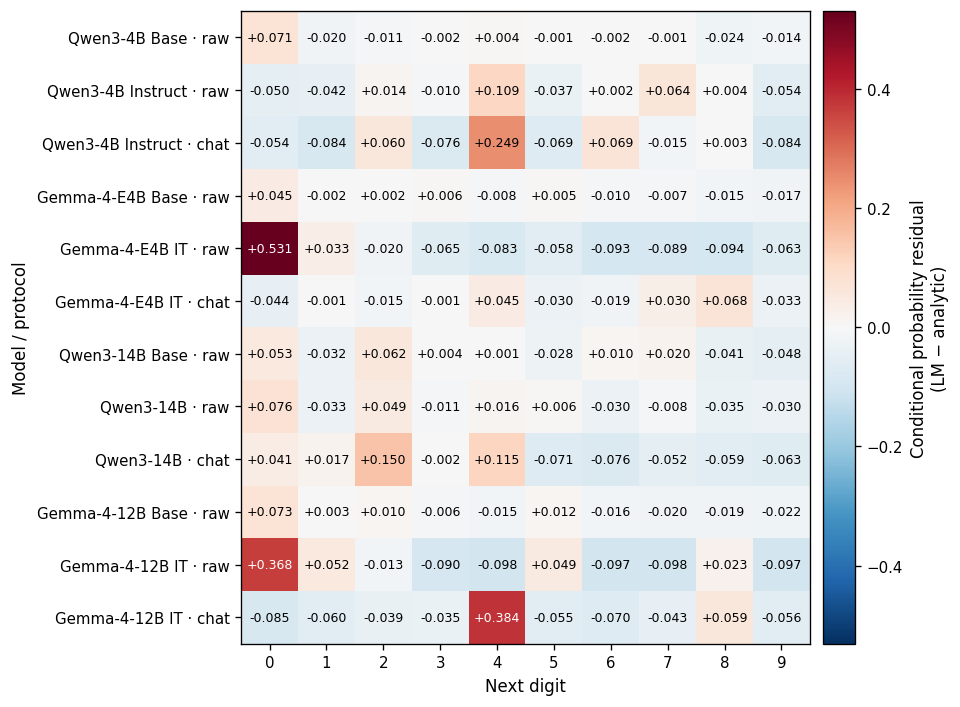

In [49]:
from matplotlib.colors import TwoSlopeNorm

rq2f_fraction_matrix = (
    rq2f_digit_model[
        rq2f_digit_model["stage"]
        == "Fraction d1"
    ]
    .pivot(
        index="model_id",
        columns="token",
        values="residual",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=list("0123456789"),
    )
)

plot_data = rq2f_fraction_matrix.copy()

plot_data.index = [
    MODEL_LABELS[mid]
    for mid in plot_data.index
]

max_abs = np.nanmax(
    np.abs(plot_data.to_numpy())
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs,
)

fig, ax = plt.subplots(
    figsize=(8.0, 6.0)
)

im = ax.imshow(
    plot_data,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
)

ax.set_xticks(
    range(10)
)
ax.set_xticklabels(
    list("0123456789")
)

ax.set_yticks(
    range(len(plot_data))
)
ax.set_yticklabels(
    plot_data.index
)

ax.set_xlabel("Next digit")
ax.set_ylabel("Model / protocol")

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.3f}",
            ha="center",
            va="center",
            fontsize=7.5,
            color=(
                "white"
                if abs(value) > 0.55 * max_abs
                else "black"
            ),
        )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Conditional probability residual\n"
    "(LM − analytic)"
)

fig.tight_layout()
plt.show()

**Figure RQ2.F.1.** Mean candidate-level probability residuals at Fraction depth 1. Positive values indicate digits receiving more conditional probability than analytic truth, while negative values indicate underweighting. Residuals are first averaged across evaluated prefixes within each model/protocol × distribution condition and then averaged equally across the five canonical distributions.

In [50]:
rq2f_decimal["low_digit"] = (
    rq2f_decimal["token"]
    .astype(int)
    <= 4
)

# Prefix-level exact TVD contributions
rq2f_prefix_excess = (
    rq2f_decimal
    .groupby(
        [
            "run_id",
            "model_id",
            "distribution",
            "prefix_key",
            "stage",
        ]
    )
    .apply(
        lambda g: pd.Series(
            {
                "low_signed_shift":
                    g.loc[
                        g["low_digit"],
                        "residual",
                    ].sum(),

                "low_positive_excess":
                    g.loc[
                        g["low_digit"],
                        "positive_excess",
                    ].sum(),

                "total_positive_excess":
                    g["positive_excess"].sum(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)


# Prefixes -> model × distribution × stage
rq2f_half_md = (
    rq2f_prefix_excess
    .groupby(
        [
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        low_signed_shift=("low_signed_shift", "mean"),
        low_positive_excess=("low_positive_excess", "mean"),
        total_positive_excess=("total_positive_excess", "mean"),
    )
)


# Equal-weight distributions
rq2f_half_model = (
    rq2f_half_md
    .groupby(
        ["model_id", "stage"],
        as_index=False,
    )
    .agg(
        low_signed_shift=("low_signed_shift", "mean"),
        low_positive_excess=("low_positive_excess", "mean"),
        total_positive_excess=("total_positive_excess", "mean"),
    )
)

rq2f_half_model["low_excess_share"] = (
    rq2f_half_model["low_positive_excess"]
    / rq2f_half_model["total_positive_excess"]
)

display(
    rq2f_half_model
    .pivot(
        index="model_id",
        columns="stage",
        values="low_excess_share",
    )
    .reindex(MODEL_ORDER)
    .round(3)
)
#lower-digit probability shift

stage,Dot,Fraction d1
model_id,,
S1,0.592,0.650
S2,0.902,0.542
S3,0.605,0.623
S4,0.871,0.741
S5,1.000,0.959
S6,0.798,0.428
M1,0.685,0.682
M2,0.603,0.807
M3,0.976,0.922


In [51]:
# Dominant Fraction d1 residual by model

rq2f_fraction_dominant = []

for model_id in MODEL_ORDER:
    row = rq2f_fraction_matrix.loc[model_id]

    rq2f_fraction_dominant.append(
        {
            "model_id": model_id,
            "dominant_excess_digit": row.idxmax(),
            "dominant_residual": row.max(),
        }
    )

rq2f_fraction_dominant = (
    pd.DataFrame(
        rq2f_fraction_dominant
    )
    .set_index("model_id")
)


rq2f_half_table = (
    rq2f_half_model
    .pivot(
        index="model_id",
        columns="stage",
        values="low_excess_share",
    )
    .reindex(MODEL_ORDER)
)

rq2f_summary = pd.DataFrame(
    {
        "Dot lower-half excess share":
            rq2f_half_table["Dot"],

        "Fraction d1 lower-half excess share":
            rq2f_half_table["Fraction d1"],

        "Fraction dominant excess digit":
            rq2f_fraction_dominant[
                "dominant_excess_digit"
            ],

        "Fraction dominant residual":
            rq2f_fraction_dominant[
                "dominant_residual"
            ],
    }
)

rq2f_summary.index = [
    MODEL_LABELS[mid]
    for mid in rq2f_summary.index
]

display(
    rq2f_summary.round(3)
)

,Dot lower-half excess share,Fraction d1 lower-half excess share,Fraction dominant excess digit,Fraction dominant residual
Qwen3-4B Base · raw,0.592,0.650,0,0.071
Qwen3-4B Instruct · raw,0.902,0.542,4,0.109
Qwen3-4B Instruct · chat,0.605,0.623,4,0.249
Gemma-4-E4B Base · raw,0.871,0.741,0,0.045
Gemma-4-E4B IT · raw,1.000,0.959,0,0.531
Gemma-4-E4B IT · chat,0.798,0.428,8,0.068
Qwen3-14B Base · raw,0.685,0.682,2,0.062
Qwen3-14B · raw,0.603,0.807,0,0.076
Qwen3-14B · chat,0.976,0.922,2,0.150
Gemma-4-12B Base · raw,0.885,0.784,0,0.073


**Table RQ2.F.2.** Candidate-level structure of decimal-stage excess probability. Lower-half excess share denotes the proportion of positive probability residual contributing to TVD that is assigned to digits `0`–`4`. The final columns identify the digit with the largest mean positive residual at Fraction depth 1 for each model/protocol condition.

### Interpretation

The token-level residual analysis shows that the stage-level TVD observed in RQ2.A is produced by specific and interpretable probability reallocations rather than undifferentiated noise.

At non-trivial Integer states, analytic truth places essentially all conditional probability on the decimal point. The Integer-stage mismatch is therefore almost completely explained by whether the model makes this formatting transition. Across all 72 non-trivial Integer prefixes, the difference between total Integer TVD and the deficit in decimal-point probability is at most 0.0004. Conditions with near-zero Integer TVD assign almost all probability to `.`, whereas Gemma-4-12B IT raw assigns essentially none and consequently reaches TVD close to 1.

The decimal stages exhibit a different error pattern. Dot and Fraction depth-1 TVD arise from probability being redistributed among digits that are all valid continuations. The attracting digit is model-dependent: some conditions concentrate excess probability on `0`, others on `2`, `4`, or occasionally another digit. Thus, the over-concentration identified in RQ2.B does not correspond to one universal preferred symbol.

A broader directional pattern nevertheless emerges. Relative to analytic truth, digits `0`–`4` absorb approximately 83% of the positive probability residual contributing to Dot-stage TVD and 75% at Fraction depth 1. The corresponding signed shift toward the lower half of the digit range is present in all twelve model/protocol averages at Dot and eleven of twelve at Fraction depth 1. Digits `0`, `2`, and `4` alone account for roughly two thirds of the positive excess mass at both stages.

This structure is especially informative at Fraction depth 1 because analytic truth is almost maximally diffuse there. The large TVD is therefore not produced by failure to approximate a sharply structured target. Instead, the models introduce strong preferences among digits where the mathematically correct conditional allocation is close to uniform.

The exact attracting digit remains condition-dependent, so the result should be interpreted as a systematic lower-digit probability shift combined with model-specific concentration patterns, rather than as evidence for a single universal digit-preference mechanism.

### Result statement

###### **Figure RQ2.F.2.** Explanatory figure candidate — decide between this and the full residual heatmap during final figure selection.
###### **Figure RQ2.F.1** Strong main-text candidate.
Stage-level mismatch can be traced to specific candidate-level probability reallocations. At non-trivial Integer states, TVD is almost entirely explained by failure to assign the analytically required probability to the decimal point, with the decimal-point deficit reproducing Integer TVD to within 0.0004 across all evaluated prefixes. At Dot and Fraction depth 1, the error instead reflects over-concentration on particular digits. Although the dominant digit differs across model/protocol conditions, excess probability is systematically shifted toward the lower half of the digit range: digits `0`–`4` absorb approximately 83% of positive residual mass at Dot and 75% at Fraction depth 1. Decimal-stage misalignment is therefore structured candidate-level reallocation rather than diffuse random error.


### RQ2.F conclusion

Token-level analysis explains how the distinct RQ2 failure profiles arise. Integer mismatch primarily reflects the formatting transition to `.`, whereas the large Dot and Fraction errors are generated by selective concentration on particular digits. The latter show a broad shift toward lower-valued digits while retaining model-specific preferred continuations.

These findings connect the aggregate TVD, entropy, support, and compliance diagnostics to the actual next-symbol probabilities that generate them.

# RQ2 — Overall conclusion

The probabilistic alignment failures identified in RQ1 do not occur at one universal point in numerical continuation and do not share a single form.

Stage profiles differ strongly across model/protocol conditions. Some models show substantial ROOT mismatch but recover at later stages, while others represent coarse numerical transitions accurately and then deteriorate at Dot and Fraction depth 1.

The form of the mismatch also changes across stages. ROOT errors can include strong distortions of sign probability. Numerical compliance is frequently poor at ROOT but is close to complete at later stages for many conditions, demonstrating that large decimal-stage TVD often persists even when the model remains fully within the valid numerical continuation space. Bounded targets additionally reveal cases where models assign conditional probability to numerically valid but target-impossible continuations.

At the decimal stages, the dominant conditional failure is over-concentration. Analytic next-digit distributions are close to maximally diffuse, yet the models systematically concentrate probability on selected digits. Token-level residuals show that this concentration is structured: excess mass is disproportionately assigned to lower-valued digits, although the particular digit receiving the largest excess depends on the model/protocol condition.

RQ2 therefore identifies several distinct failure modes—numerical non-compliance, target-support violation, formatting-transition error, sign asymmetry, and misallocation among valid digits—that can produce similar aggregate TVD values. This motivates RQ3A, which next asks how these alignment patterns depend on the target distribution and whether model probabilities change appropriately when the underlying mathematical distribution changes.

# RQ3A — Canonical Distribution-Family Dependence

**RQ3A:** How does next-symbol probabilistic alignment differ across the canonical target distribution families?

RQ1 established the overall magnitude of conditional mismatch, while RQ2 showed that this mismatch can arise through different stage-localised failure modes.

RQ3A now asks whether alignment also depends on the target distribution itself.

The analysis distinguishes two questions:

1. whether some distribution families are systematically more difficult on average; and
2. whether distribution effects depend on the particular model, protocol, numerical stage, or matched numerical state.

This distinction is important because a small marginal distribution effect does not imply that models respond similarly to different distributions.

## RQ3A.A — Marginal distribution-family dependence

### Question

When averaged across the evaluated model/protocol conditions, do the five canonical target distributions differ substantially in conditional probabilistic alignment?

### Analysis choice

The common-grid hierarchical TVD from RQ1.A is retained for this comparison.

For each model/protocol × distribution condition, prefixes are first averaged within ROOT, Integer, Dot, and Fraction depth 1, after which the four stages receive equal weight:

$$
TVD_{\text{primary}}
=
\frac{
T_{\text{ROOT}}
+
T_{\text{Integer}}
+
T_{\text{Dot}}
+
T_{\text{Fraction d1}}
}{4}.
$$

The allocation-only sensitivity score from RQ1.B is not used as the primary RQ3A estimator because removing deterministic prefixes changes stage availability across distribution families. In particular, the Integer stage disappears for the bounded Uniform and Beta targets. The common-grid score therefore provides the cleaner like-for-like comparison for the canonical distribution-family question.

Distribution means are treated descriptively. A small difference between marginal distribution means does not establish that distribution is irrelevant, because model × distribution and stage × distribution interactions may still be substantial.

In [52]:
# RQ3A.A — Marginal distribution-family comparison

rq3aa_matrix = (
    primary_run_summary
    .pivot(
        index="model_id",
        columns="distribution",
        values="mean_tvd",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=DISTRIBUTION_ORDER,
    )
)


rq3aa_distribution_summary = pd.DataFrame(
    {
        "mean_tvd":
            rq3aa_matrix.mean(axis=0),

        "median_tvd":
            rq3aa_matrix.median(axis=0),

        "min_model_tvd":
            rq3aa_matrix.min(axis=0),

        "max_model_tvd":
            rq3aa_matrix.max(axis=0),
    }
)

rq3aa_distribution_summary[
    "model_range"
] = (
    rq3aa_distribution_summary["max_model_tvd"]
    - rq3aa_distribution_summary["min_model_tvd"]
)

display(
    rq3aa_distribution_summary.round(3)
)

,mean_tvd,median_tvd,min_model_tvd,max_model_tvd,model_range
distribution,,,,,
normal,0.347,0.271,0.153,0.653,0.500
uniform,0.305,0.282,0.111,0.640,0.528
exponential,0.343,0.260,0.114,0.745,0.632
beta,0.302,0.282,0.111,0.662,0.552
laplace,0.338,0.249,0.133,0.666,0.533


**Table RQ3A.A.1.** Primary hierarchical TVD by canonical target distribution under the plain-prompt main-grid baseline. Marginal means and medians average across the twelve model/protocol conditions. The final columns show the range of model/protocol TVD observed within each distribution.

In [53]:
rq3aa_distribution_spread = (
    rq3aa_distribution_summary["mean_tvd"].max()
    - rq3aa_distribution_summary["mean_tvd"].min()
)

rq3aa_model_means = (
    rq3aa_matrix.mean(axis=1)
)

rq3aa_model_spread = (
    rq3aa_model_means.max()
    - rq3aa_model_means.min()
)

print(
    "Spread between marginal distribution means:",
    round(rq3aa_distribution_spread, 3),
)

print(
    "Spread between marginal model/protocol means:",
    round(rq3aa_model_spread, 3),
)

print(
    "Within-distribution model ranges:"
)

display(
    rq3aa_distribution_summary[
        ["model_range"]
    ].round(3)
)

Spread between marginal distribution means: 0.045
Spread between marginal model/protocol means: 0.53
Within-distribution model ranges:


,model_range
distribution,
normal,0.500
uniform,0.528
exponential,0.632
beta,0.552
laplace,0.533


In [54]:
rq3aa_model_distribution_range = pd.DataFrame(
    {
        "lowest_tvd_distribution":
            rq3aa_matrix.idxmin(axis=1),

        "lowest_tvd":
            rq3aa_matrix.min(axis=1),

        "highest_tvd_distribution":
            rq3aa_matrix.idxmax(axis=1),

        "highest_tvd":
            rq3aa_matrix.max(axis=1),
    }
)

rq3aa_model_distribution_range[
    "within_model_range"
] = (
    rq3aa_model_distribution_range[
        "highest_tvd"
    ]
    - rq3aa_model_distribution_range[
        "lowest_tvd"
    ]
)

rq3aa_model_distribution_range.index = [
    MODEL_LABELS[mid]
    for mid in rq3aa_model_distribution_range.index
]

display(
    rq3aa_model_distribution_range.round(3)
)

,lowest_tvd_distribution,lowest_tvd,highest_tvd_distribution,highest_tvd,within_model_range
Qwen3-4B Base · raw,exponential,0.114,beta,0.163,0.049
Qwen3-4B Instruct · raw,normal,0.211,exponential,0.298,0.087
Qwen3-4B Instruct · chat,beta,0.356,exponential,0.582,0.226
Gemma-4-E4B Base · raw,laplace,0.235,beta,0.278,0.043
Gemma-4-E4B IT · raw,exponential,0.480,beta,0.623,0.144
Gemma-4-E4B IT · chat,beta,0.178,normal,0.265,0.087
Qwen3-14B Base · raw,beta,0.111,exponential,0.254,0.143
Qwen3-14B · raw,uniform,0.111,normal,0.245,0.133
Qwen3-14B · chat,beta,0.294,laplace,0.483,0.188
Gemma-4-12B Base · raw,exponential,0.260,uniform,0.309,0.048


In [55]:
print("Lowest-TVD distribution by model:")
display(
    rq3aa_matrix.idxmin(axis=1)
    .value_counts()
)

print("Highest-TVD distribution by model:")
display(
    rq3aa_matrix.idxmax(axis=1)
    .value_counts()
)

Lowest-TVD distribution by model:


exponential    4
beta           4
uniform        2
normal         1
laplace        1
Name: count, dtype: int64

Highest-TVD distribution by model:


exponential    4
beta           3
normal         2
laplace        2
uniform        1
Name: count, dtype: int64

### Interpretation

Marginal differences between the five canonical distribution families are modest. Mean primary TVD ranges from 0.302 for Beta to 0.347 for Normal, giving a total spread of only 0.045 across the distribution means.

This marginal variation is small compared with the variation between model/protocol conditions. Their overall mean TVD spans approximately 0.143–0.673, a range of 0.530. Similarly, within each individual distribution, the range between the best- and worst-aligned model/protocol conditions is approximately 0.50–0.63.

The small marginal distribution spread does not imply that target distribution is unimportant. Distribution sensitivity differs substantially between model/protocol conditions. Within-model TVD ranges across the five target distributions vary from 0.043 to 0.226. Moreover, there is no distribution that is consistently easiest or hardest. Exponential, for example, produces the lowest TVD for four model/protocol conditions but the highest TVD for four others.

The crossing distribution profiles therefore indicate interaction rather than a strong universal distribution ordering. Averaging across model/protocol conditions largely cancels these condition-specific differences, producing similar marginal means even though individual models can respond quite differently to the target distribution.

### Result statement
###### Supporting/main-text candidate, but not guaranteed.
Canonical distribution family has only a modest marginal association with overall conditional alignment: mean primary TVD varies from 0.302 to 0.347 across the five targets. This spread is much smaller than the 0.530 range between model/protocol means and the 0.50–0.63 model ranges observed within individual distributions. However, the small marginal distribution effect conceals substantial model-specific sensitivity. No target distribution is consistently easiest or hardest across conditions, indicating that distribution dependence is primarily interactional rather than a universal ordering of target families.

### RQ3A.A conclusion

The canonical target distributions do not form a stable hierarchy of alignment difficulty. Their marginal TVD means are similar, but individual model/protocol conditions show meaningfully different distribution profiles.

The main distribution-family result is therefore not that one canonical distribution is universally easier or harder. Instead, the effect of changing the target distribution depends on the model/protocol condition being evaluated.

The following analyses preserve this interaction structure rather than relying on marginal distribution averages.

**Next:** RQ3A.B examines how the distribution effect changes across numerical stages, asking whether different target families alter the location of the conditional mismatch even when their overall marginal TVD is similar.

## RQ3A.B — Distribution dependence across numerical stages

### Question

Does the effect of target distribution remain similar throughout numerical continuation, or does distribution dependence change across prefix stages?

### Motivation

RQ3A.A showed that the five canonical target distributions have relatively similar overall marginal TVD. However, this overall comparison averages across ROOT, Integer, Dot, and Fraction depth 1.

A small overall distribution effect could therefore arise even if different distributions produce substantially different behaviour at particular numerical stages.

RQ3A.B preserves the stage structure and asks:

> At which numerical stages is model alignment most sensitive to the target distribution?

For this stage-localised analysis, the non-trivial allocation view from RQ2.A is used. Prefixes with only one valid continuation are excluded because their conditional TVD is mechanically zero and would make distribution comparisons at that stage reflect deterministic support structure rather than probability-allocation quality.

Consequently, the Integer stage is structurally unavailable for Uniform and Beta. These cases are retained as missing rather than replaced with zero. ROOT, Dot, and Fraction depth 1 remain available for all five canonical distributions.

In [56]:
# RQ3A.B — Distribution × stage conditional alignment

rq3ab_distribution_stage = (
    rq2a_distribution_stage
    .groupby(
        ["distribution", "stage"],
        as_index=False,
    )
    .agg(
        mean_tvd=("stage_tvd", "mean"),
        median_tvd=("stage_tvd", "median"),
        min_model_tvd=("stage_tvd", "min"),
        max_model_tvd=("stage_tvd", "max"),
        n_models=("model_id", "nunique"),
    )
)

rq3ab_distribution_stage["model_range"] = (
    rq3ab_distribution_stage["max_model_tvd"]
    - rq3ab_distribution_stage["min_model_tvd"]
)


rq3ab_matrix = (
    rq3ab_distribution_stage
    .pivot(
        index="distribution",
        columns="stage",
        values="mean_tvd",
    )
    .reindex(DISTRIBUTION_ORDER)
    .reindex(columns=STAGE_ORDER_RQ2A)
)

display(rq3ab_matrix.round(3))

stage,ROOT,Integer,Dot,Fraction d1
distribution,,,,
normal,0.432,0.192,0.443,0.418
uniform,0.296,NaN,0.464,0.459
exponential,0.425,0.159,0.433,0.410
beta,0.347,NaN,0.541,0.319
laplace,0.386,0.189,0.439,0.431


**Table RQ3A.B.1.** Mean non-trivial TVD across canonical target distributions and primary numerical stages. Values are first averaged within each model/protocol × distribution × stage condition and then averaged equally across the twelve model/protocol conditions. Integer is structurally absent for Uniform and Beta after restricting the analysis to prefixes with multiple valid continuations.

In [57]:
rq3ab_marginal_spread = pd.DataFrame(
    {
        "min_distribution_mean":
            rq3ab_matrix.min(axis=0),

        "max_distribution_mean":
            rq3ab_matrix.max(axis=0),
    }
)

rq3ab_marginal_spread["distribution_spread"] = (
    rq3ab_marginal_spread["max_distribution_mean"]
    - rq3ab_marginal_spread["min_distribution_mean"]
)

display(
    rq3ab_marginal_spread
    .reindex(STAGE_ORDER_RQ2A)
    .round(3)
)

,min_distribution_mean,max_distribution_mean,distribution_spread
stage,,,
ROOT,0.296,0.432,0.136
Integer,0.159,0.192,0.032
Dot,0.433,0.541,0.108
Fraction d1,0.319,0.459,0.140


In [58]:
rq3ab_model_stage_range = (
    rq2a_distribution_stage
    .groupby(
        ["model_id", "stage"],
        as_index=False,
    )
    .agg(
        min_distribution_tvd=("stage_tvd", "min"),
        max_distribution_tvd=("stage_tvd", "max"),
        distributions_available=("distribution", "nunique"),
    )
)

rq3ab_model_stage_range[
    "distribution_range"
] = (
    rq3ab_model_stage_range[
        "max_distribution_tvd"
    ]
    - rq3ab_model_stage_range[
        "min_distribution_tvd"
    ]
)


rq3ab_range_summary = (
    rq3ab_model_stage_range
    .groupby("stage")
    .agg(
        mean_range=("distribution_range", "mean"),
        median_range=("distribution_range", "median"),
        min_range=("distribution_range", "min"),
        max_range=("distribution_range", "max"),
    )
    .reindex(STAGE_ORDER_RQ2A)
)

display(
    rq3ab_range_summary.round(3)
)

,mean_range,median_range,min_range,max_range
stage,,,,
ROOT,0.453,0.442,0.179,0.914
Integer,0.076,0.002,0.000,0.643
Dot,0.194,0.176,0.078,0.349
Fraction d1,0.222,0.243,0.086,0.361


In [59]:
rq3ab_range_matrix = (
    rq3ab_model_stage_range
    .pivot(
        index="model_id",
        columns="stage",
        values="distribution_range",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=STAGE_ORDER_RQ2A,
    )
)

rq3ab_range_matrix.index = [
    MODEL_LABELS[mid]
    for mid in rq3ab_range_matrix.index
]

display(
    rq3ab_range_matrix.round(3)
)

stage,ROOT,Integer,Dot,Fraction d1
Qwen3-4B Base · raw,0.179,0.019,0.078,0.099
Qwen3-4B Instruct · raw,0.541,0.000,0.349,0.358
Qwen3-4B Instruct · chat,0.914,0.000,0.176,0.239
Gemma-4-E4B Base · raw,0.329,0.194,0.117,0.099
Gemma-4-E4B IT · raw,0.527,0.643,0.207,0.170
Gemma-4-E4B IT · chat,0.511,0.000,0.294,0.361
Qwen3-14B Base · raw,0.322,0.004,0.170,0.247
Qwen3-14B · raw,0.258,0.007,0.233,0.251
Qwen3-14B · chat,0.470,0.000,0.089,0.307
Gemma-4-12B Base · raw,0.399,0.050,0.171,0.086


### Interpretation

The modest overall distribution-family differences observed in RQ3A.A conceal substantial stage-specific structure.

The relative ordering of the canonical distributions changes across numerical stages. At ROOT, Uniform has the lowest marginal TVD (0.296) and Normal the highest (0.432). At Dot, Beta instead has the largest mismatch (0.541), while at Fraction depth 1 Beta has the lowest mean TVD (0.319) and Uniform the highest (0.459). The distributions therefore do not retain a stable ordering as numerical continuation progresses.

More importantly, marginal distribution × stage means substantially understate the distribution sensitivity of individual models. At ROOT, the spread between the five marginal distribution means is only 0.136, but the mean within-model distribution range is 0.453 and reaches 0.914 for Qwen3-4B Instruct chat. Distribution effects at ROOT therefore differ strongly in both magnitude and direction across model/protocol conditions and partially cancel under marginal averaging.

Distribution sensitivity remains appreciable at the decimal stages. Mean within-model ranges are 0.194 at Dot and 0.222 at Fraction depth 1, showing that the target distribution can meaningfully alter conditional alignment even at the same broad numerical stage. Integer behaviour is more stable for most conditions: its median distribution range is only 0.002 across Normal, Exponential, and Laplace. However, this apparent stability is not universal, with Gemma-4-E4B IT raw showing a range of 0.643.

The canonical distribution effect is therefore stage-dependent and strongly moderated by model/protocol condition. Similar overall distribution means do not imply that the models respond similarly to the different target distributions.

### Result statement

Distribution dependence changes across the numerical continuation process and is substantially larger within individual model/protocol conditions than marginal averages suggest. The relative ordering of the five canonical targets reverses across ROOT, Dot, and Fraction depth 1, while the mean within-model distribution range reaches 0.453 at ROOT, 0.194 at Dot, and 0.222 at Fraction depth 1. Thus, the small overall distribution-family differences found in RQ3A.A partly reflect cancellation of heterogeneous model × distribution × stage effects rather than genuine distribution invariance.

### RQ3A.B conclusion

Target-distribution dependence is not constant across numerical stages. Different distributions alter where mismatch appears, and the magnitude of this effect depends strongly on the evaluated model/protocol condition.

The especially large within-model variation at ROOT and the remaining variation at Fraction depth 1 raise a more precise question: are these changes proportional to genuine changes in the mathematically correct next-symbol distribution, or does the model change substantially even when analytic truth remains nearly unchanged?

**Next:** RQ3A.C addresses this directly through matched-prefix cross-distribution comparisons, contrasting changes in the analytic conditional probability vector with changes in the model conditional probability vector at the same numerical state.

## RQ3A.C — Matched-prefix cross-distribution sensitivity

### Question

At the same numerical prefix, does changing the target distribution produce a change in the model's conditional next-symbol distribution that is commensurate with the corresponding change in analytic truth?

### Motivation

RQ3A.A showed only modest differences between the marginal TVD of the five canonical distribution families, while RQ3A.B showed that distribution effects can nevertheless vary strongly across models and numerical stages.

These analyses compare each model distribution with its own analytic target. A more direct test is possible at numerical prefixes that occur under multiple target distributions.

For a shared prefix $r$ and two target distributions $d_i$ and $d_j$, define the change in analytic next-symbol probability as

$$
D_{\text{truth}}(r;d_i,d_j)
=
TVD
\left(
P_{\text{truth}}^{d_i}(\cdot\mid r),
P_{\text{truth}}^{d_j}(\cdot\mid r)
\right).
$$

For model/protocol condition $m$, define the corresponding change in the model distribution as

$$
D_{\text{LM}}^{m}(r;d_i,d_j)
=
TVD
\left(
P_{\text{LM}}^{*,m,d_i}(\cdot\mid r),
P_{\text{LM}}^{*,m,d_j}(\cdot\mid r)
\right).
$$

Their difference,

$$
E^{m}(r;d_i,d_j)
=
D_{\text{LM}}^{m}(r;d_i,d_j)
-
D_{\text{truth}}(r;d_i,d_j),
$$

is used descriptively as an excess distribution-sensitivity measure.

Positive values indicate that the model's conditional probability vector changes more between the two target specifications than the locally correct analytic vector does. Negative values indicate that the model changes less.

No ratio is used because $D_{\text{truth}}$ can be zero or extremely small.

The prefixes shared by all five canonical distributions are ROOT, `0`, `0.`, `0.5`, and `0.50`. At the decimal prefixes, all five distributions also share the same ten-digit candidate set. ROOT is retained but interpreted separately because target support can genuinely alter its candidate structure.

In [60]:
# RQ3A.C — Matched-prefix cross-distribution sensitivity

from itertools import combinations

rq3ac_tokens = token_df[
    token_df["prompt_type"] == "plain"
].copy()

rq3ac_tokens["prefix_key"] = (
    rq3ac_tokens["prefix"]
    .fillna("ROOT")
    .astype(str)
)

SHARED_PREFIXES = [
    "ROOT",
    "0",
    "0.",
    "0.5",
    "0.50",
]

distribution_pairs = list(
    combinations(
        DISTRIBUTION_ORDER,
        2,
    )
)


def tvd_between_vectors(p, q):
    return 0.5 * np.abs(p - q).sum()


def candidate_vector(
    data,
    prefix,
    distribution,
    value_col,
    model_id=None,
):
    subset = data[
        (data["prefix_key"] == prefix)
        & (data["distribution"] == distribution)
    ].copy()

    if model_id is not None:
        subset = subset[
            subset["model_id"] == model_id
        ]

    # Common alphabet for the matched prefix
    candidate_universe = sorted(
        data[
            data["prefix_key"] == prefix
        ]["token"]
        .astype(str)
        .unique()
    )

    # Analytic truth is repeated across model runs,
    # so collapse duplicate copies.
    if model_id is None:
        values = (
            subset
            .groupby("token")[value_col]
            .mean()
        )
    else:
        values = (
            subset
            .set_index("token")[value_col]
        )

    return np.array(
        [
            values.get(candidate, 0.0)
            for candidate in candidate_universe
        ],
        dtype=float,
    )


rq3ac_rows = []

for prefix in SHARED_PREFIXES:

    truth_vectors = {
        distribution:
            candidate_vector(
                rq3ac_tokens,
                prefix,
                distribution,
                "analytic_truth",
            )
        for distribution
        in DISTRIBUTION_ORDER
    }

    for d1, d2 in distribution_pairs:

        truth_tvd = tvd_between_vectors(
            truth_vectors[d1],
            truth_vectors[d2],
        )

        for model_id in MODEL_ORDER:

            lm_d1 = candidate_vector(
                rq3ac_tokens,
                prefix,
                d1,
                "lm_prob",
                model_id=model_id,
            )

            lm_d2 = candidate_vector(
                rq3ac_tokens,
                prefix,
                d2,
                "lm_prob",
                model_id=model_id,
            )

            lm_tvd = tvd_between_vectors(
                lm_d1,
                lm_d2,
            )

            rq3ac_rows.append(
                {
                    "prefix": prefix,
                    "distribution_1": d1,
                    "distribution_2": d2,
                    "model_id": model_id,
                    "truth_cross_tvd": truth_tvd,
                    "lm_cross_tvd": lm_tvd,
                    "excess_sensitivity":
                        lm_tvd - truth_tvd,
                }
            )


rq3ac_pairwise = pd.DataFrame(
    rq3ac_rows
)

In [61]:
rq3ac_model_prefix = (
    rq3ac_pairwise
    .groupby(
        ["model_id", "prefix"],
        as_index=False,
    )
    .agg(
        truth_cross_tvd=(
            "truth_cross_tvd",
            "mean",
        ),
        lm_cross_tvd=(
            "lm_cross_tvd",
            "mean",
        ),
        excess_sensitivity=(
            "excess_sensitivity",
            "mean",
        ),
    )
)


rq3ac_prefix_summary = (
    rq3ac_model_prefix
    .groupby("prefix")
    .agg(
        analytic_pairwise_tvd=(
            "truth_cross_tvd",
            "mean",
        ),
        model_pairwise_tvd=(
            "lm_cross_tvd",
            "mean",
        ),
        min_model_pairwise_tvd=(
            "lm_cross_tvd",
            "min",
        ),
        max_model_pairwise_tvd=(
            "lm_cross_tvd",
            "max",
        ),
        mean_excess=(
            "excess_sensitivity",
            "mean",
        ),
        models_above_truth=(
            "excess_sensitivity",
            lambda x: (x > 1e-12).sum(),
        ),
    )
    .reindex(SHARED_PREFIXES)
)

display(
    rq3ac_prefix_summary.round(3)
)

,analytic_pairwise_tvd,model_pairwise_tvd,min_model_pairwise_tvd,max_model_pairwise_tvd,mean_excess,models_above_truth
prefix,,,,,,
ROOT,0.447,0.422,0.102,0.800,-0.024,5
0,0.000,0.000,0.000,0.000,0.000,0
0.,0.127,0.321,0.003,0.785,0.194,10
0.5,0.007,0.285,0.054,0.715,0.278,12
0.50,0.001,0.258,0.001,0.556,0.257,11


**Table RQ3A.C.1.** Cross-distribution sensitivity at numerical prefixes shared by all five canonical targets. Analytic pairwise TVD measures the mean change in the correct conditional probability vector across the ten pairs of target distributions. Model pairwise TVD measures the corresponding change in each model/protocol condition and is then averaged across conditions. Positive excess indicates greater model variation across target specifications than is present in the local analytic target.

In [62]:
rq3ac_controls = [
    ("ROOT", "normal", "laplace"),
    ("ROOT", "uniform", "beta"),
    ("0.", "exponential", "laplace"),
    ("0.5", "exponential", "laplace"),
    ("0.50", "exponential", "laplace"),
    ("0.50", "uniform", "beta"),
]


control_rows = []

for prefix, d1, d2 in rq3ac_controls:

    g = rq3ac_pairwise[
        (rq3ac_pairwise["prefix"] == prefix)
        & (
            rq3ac_pairwise[
                "distribution_1"
            ] == d1
        )
        & (
            rq3ac_pairwise[
                "distribution_2"
            ] == d2
        )
    ]

    control_rows.append(
        {
            "prefix": prefix,
            "distribution_pair":
                f"{d1} – {d2}",

            "analytic_tvd":
                g["truth_cross_tvd"].iloc[0],

            "mean_model_tvd":
                g["lm_cross_tvd"].mean(),

            "median_model_tvd":
                g["lm_cross_tvd"].median(),

            "min_model_tvd":
                g["lm_cross_tvd"].min(),

            "max_model_tvd":
                g["lm_cross_tvd"].max(),
        }
    )


rq3ac_control_summary = pd.DataFrame(
    control_rows
)

display(
    rq3ac_control_summary.round(3)
)

,prefix,distribution_pair,analytic_tvd,mean_model_tvd,median_model_tvd,min_model_tvd,max_model_tvd
0,ROOT,normal – laplace,0.045,0.204,0.099,0.000,0.841
1,ROOT,uniform – beta,0.000,0.087,0.037,0.000,0.371
2,0.,exponential – laplace,0.000,0.305,0.277,0.003,0.806
3,0.5,exponential – laplace,0.000,0.280,0.232,0.030,0.630
4,0.50,exponential – laplace,0.000,0.125,0.077,0.001,0.412
5,0.50,uniform – beta,0.000,0.397,0.315,0.000,0.996


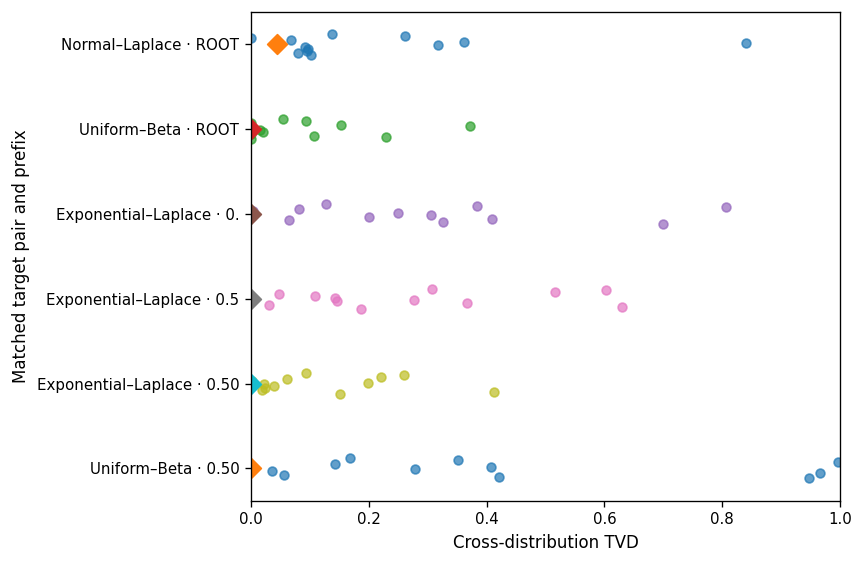

In [63]:
# Figure RQ3A.C.1 — Matched-prefix local sensitivity

control_plot_rows = []

for prefix, d1, d2 in rq3ac_controls:

    g = rq3ac_pairwise[
        (rq3ac_pairwise["prefix"] == prefix)
        & (
            rq3ac_pairwise[
                "distribution_1"
            ] == d1
        )
        & (
            rq3ac_pairwise[
                "distribution_2"
            ] == d2
        )
    ].copy()

    label = (
        f"{d1.capitalize()}–"
        f"{d2.capitalize()} · {prefix}"
    )

    for _, row in g.iterrows():
        control_plot_rows.append(
            {
                "label": label,
                "model_id":
                    row["model_id"],
                "lm_tvd":
                    row["lm_cross_tvd"],
                "truth_tvd":
                    row["truth_cross_tvd"],
            }
        )


rq3ac_control_plot = pd.DataFrame(
    control_plot_rows
)

label_order = [
    (
        f"{d1.capitalize()}–"
        f"{d2.capitalize()} · {prefix}"
    )
    for prefix, d1, d2
    in rq3ac_controls
]


fig, ax = plt.subplots(
    figsize=(7.3, 4.8)
)

y_positions = np.arange(
    len(label_order)
)

for i, label in enumerate(label_order):

    g = rq3ac_control_plot[
        rq3ac_control_plot["label"]
        == label
    ]

    # Slight vertical spread so all twelve
    # model/protocol points remain visible
    offsets = np.linspace(
        -0.12,
        0.12,
        len(g),
    )

    ax.scatter(
        g["lm_tvd"],
        i + offsets,
        s=28,
        alpha=0.7,
    )

    analytic_value = (
        g["truth_tvd"].iloc[0]
    )

    ax.scatter(
        analytic_value,
        i,
        marker="D",
        s=70,
    )


ax.set_yticks(y_positions)
ax.set_yticklabels(label_order)

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Cross-distribution TVD"
)
ax.set_ylabel(
    "Matched target pair and prefix"
)

ax.invert_yaxis()

fig.tight_layout()
plt.show()

**Figure RQ3A.C.1.** Matched-prefix sensitivity of analytic and model conditional probability distributions to changes in the target distribution. Diamonds show TVD between the two analytically correct next-symbol vectors at the same prefix, while individual points show the corresponding cross-distribution TVD for each of the twelve model/protocol conditions. Exponential and Laplace have analytically identical conditional vectors at the positive decimal prefixes shown, yet model distributions frequently differ substantially.

### Interpretation

Matched-prefix analysis reveals distribution dependence that is largely hidden by the marginal distribution averages in RQ3A.A.

At the deterministic prefix `0`, analytic and model conditional distributions are identical across all five target distributions because the decimal point is the only valid continuation. This provides a control in which both analytic and model cross-distribution TVD are exactly zero.

Once multiple next digits become available, a different pattern emerges. At prefix `0.5`, the mean pairwise difference between the five analytic conditional distributions is only 0.0065, whereas the corresponding model difference averages 0.285. All twelve model/protocol conditions show greater average cross-distribution variation than analytic truth at this prefix, and this holds for all 120 individual model × distribution-pair comparisons. At `0.50`, analytic pairwise TVD falls further to 0.0007 while mean model variation remains 0.258.

The Exponential–Laplace comparison provides an especially strong local control. For the positive prefixes `0.`, `0.5`, and `0.50`, their analytically correct conditional next-symbol distributions are identical up to numerical precision. Nevertheless, model cross-distribution TVD averages 0.305, 0.280, and 0.125 at these prefixes respectively. Thus, the same model can produce substantially different next-symbol probability vectors for two target specifications even when the mathematically correct local continuation distribution is unchanged.

A similar pattern occurs between Uniform and Beta at prefix `0.50`. Their analytic conditional vectors differ by only 0.00005, whereas mean model cross-distribution TVD is 0.397 and ranges from effectively zero to 0.996 across model/protocol conditions. Distribution-specification sensitivity is therefore itself strongly model dependent.

ROOT behaves differently. Its mean analytic cross-distribution TVD is already large (0.447), reflecting genuine differences in support and coarse first-symbol probability across the five targets. Model variation at ROOT is correspondingly mixed rather than uniformly excessive. The strongest evidence for excess distribution sensitivity therefore comes from the matched decimal prefixes, where candidate sets are identical and the correct local probability vectors differ little or not at all.

Overall, the small marginal distribution effect in RQ3A.A does not indicate that models are distribution invariant. Instead, models can change their local conditional probability allocations substantially across target specifications even when analytic truth requires almost no local change.

### Result statement

Matched numerical states reveal substantially greater distribution-specification sensitivity in model probabilities than is visible from marginal distribution averages. At prefix `0.5`, analytic next-digit distributions differ by only 0.0065 TVD on average across the five canonical targets, while model distributions differ by 0.285; all twelve model/protocol conditions show excess cross-distribution variation. At `0.50`, the corresponding values are 0.0007 and 0.258. Most strikingly, Exponential and Laplace have analytically identical conditional distributions at the positive decimal prefixes examined, yet the model distributions differ by 0.125–0.305 TVD on average. Thus, changing the target specification can substantially alter model next-symbol probabilities even when the locally correct conditional distribution remains unchanged.

### RQ3A.C conclusion

Distribution dependence is not adequately characterised by the small differences between marginal distribution-family means. At matched numerical states, model conditional probability vectors can vary far more across target specifications than the corresponding analytic vectors.

The effect is strongest at decimal prefixes where the candidate set is identical and analytic next-digit probabilities are nearly invariant. It is also highly model dependent: some conditions preserve local invariance, whereas others produce almost maximally different probability vectors under mathematically near-identical local targets.

Together with RQ3A.A and RQ3A.B, this shows that canonical distribution dependence is primarily expressed through model- and stage-specific interactions rather than a stable hierarchy of globally easier or harder target families.

# RQ3A — Overall conclusion

The five canonical distribution families do not form a stable hierarchy of probabilistic alignment difficulty. Their marginal primary TVD means are relatively similar, differing by only 0.045, but this average conceals substantial model- and stage-specific distribution dependence.

The relative ordering of distributions changes across numerical stages, and individual model/protocol conditions can show much larger within-model distribution variation than the marginal means suggest. This is especially pronounced at ROOT and remains substantial at Dot and Fraction depth 1.

Matched-prefix analysis further shows that these differences cannot be understood solely as appropriate responses to changes in the mathematical target. At decimal prefixes where the analytically correct next-symbol distributions are nearly identical—and, for Exponential versus Laplace, exactly identical up to numerical precision—the evaluated models can nevertheless produce substantially different conditional probability vectors.

RQ3A therefore identifies distribution dependence as an interactional and local phenomenon. The relevant question is not simply which distribution has the largest average TVD, but whether a given model changes its probability allocation appropriately as the target distribution and numerical state change.

# RQ4 — Model, Variant, Size, and Evaluation Protocol

**RQ4:** How does conditional next-symbol alignment vary across model families, model variants, model sizes, and evaluation protocols?

The main grid contains matched model structures within the Qwen and Gemma families. For each tested size, a Base checkpoint is evaluated under the raw protocol, while the corresponding post-trained checkpoint is evaluated both directly in raw format and through its chat template.

This creates the following comparison structure:

$$
\text{Base raw}
\rightarrow
\text{post-trained raw}
\rightarrow
\text{post-trained chat}.
$$

The first contrast examines how the post-trained checkpoint differs from the corresponding Base checkpoint when both are evaluated directly. The second compares the same post-trained checkpoint under raw and chat evaluation and therefore isolates the observed effect of evaluation protocol more closely.

These comparisons are treated as controlled descriptive contrasts. They are not interpreted as causal estimates of individual training interventions.

## RQ4.A — Overall model-variant and protocol contrasts

### Question

Within each model family and tested size, how does overall conditional alignment change from the Base checkpoint to the post-trained checkpoint, and how does evaluating the post-trained checkpoint through its chat template change the result?

### Analysis choice

The primary hierarchical TVD defined in RQ1.A is used so that the comparison remains based on the same canonical four-stage estimand:

$$
TVD_{\text{primary}}
=
\frac{
T_{\text{ROOT}}
+
T_{\text{Integer}}
+
T_{\text{Dot}}
+
T_{\text{Fraction d1}}
}{4}.
$$

Scores are first calculated separately for each of the five canonical target distributions and are then averaged equally across distributions.

For each family/size group, three quantities are compared:

1. Base checkpoint under raw evaluation;
2. corresponding post-trained checkpoint under raw evaluation;
3. the same post-trained checkpoint under chat evaluation.

The following descriptive contrasts are reported:

$$
\Delta_{\text{raw-base}}
=
TVD_{\text{post-trained,raw}}
-
TVD_{\text{Base,raw}},
$$

$$
\Delta_{\text{chat-raw}}
=
TVD_{\text{post-trained,chat}}
-
TVD_{\text{post-trained,raw}},
$$

and

$$
\Delta_{\text{chat-base}}
=
TVD_{\text{post-trained,chat}}
-
TVD_{\text{Base,raw}}.
$$

Because lower TVD is better, negative changes indicate improved conditional alignment and positive changes indicate increased mismatch.

In [64]:
# RQ4.A — Overall Base / post-trained raw / post-trained chat contrasts

rq4a_model_means = (
    primary_run_summary
    .groupby("model_id")["mean_tvd"]
    .mean()
)


RQ4_GROUPS = {
    "Qwen 4B": {
        "base": "S1",
        "post_raw": "S2",
        "post_chat": "S3",
    },
    "Qwen 14B": {
        "base": "M1",
        "post_raw": "M2",
        "post_chat": "M3",
    },
    "Gemma E4B": {
        "base": "S4",
        "post_raw": "S5",
        "post_chat": "S6",
    },
    "Gemma 12B": {
        "base": "M4",
        "post_raw": "M5",
        "post_chat": "M6",
    },
}


rq4a_rows = []

for group, ids in RQ4_GROUPS.items():

    base = rq4a_model_means.loc[
        ids["base"]
    ]

    post_raw = rq4a_model_means.loc[
        ids["post_raw"]
    ]

    post_chat = rq4a_model_means.loc[
        ids["post_chat"]
    ]

    rq4a_rows.append(
        {
            "Family / size": group,
            "Base raw": base,
            "Post-trained raw": post_raw,
            "Post-trained chat": post_chat,
            "Raw − Base": post_raw - base,
            "Chat − Raw": post_chat - post_raw,
            "Chat − Base": post_chat - base,
        }
    )


rq4a_table = pd.DataFrame(
    rq4a_rows
)

display(
    rq4a_table.round(3)
)

,Family / size,Base raw,Post-trained raw,Post-trained chat,Raw − Base,Chat − Raw,Chat − Base
0,Qwen 4B,0.143,0.235,0.475,0.091,0.240,0.332
1,Qwen 14B,0.178,0.180,0.407,0.002,0.227,0.229
2,Gemma E4B,0.251,0.556,0.222,0.305,-0.334,-0.029
3,Gemma 12B,0.279,0.673,0.322,0.394,-0.351,0.043


**Table RQ4.A.1.** Primary hierarchical TVD for matched Base, post-trained raw, and post-trained chat conditions within each model family and tested size. `Raw − Base` compares the post-trained checkpoint with its corresponding Base checkpoint under direct evaluation. `Chat − Raw` compares two evaluation protocols applied to the same post-trained checkpoint. Negative deltas indicate improved conditional alignment; positive deltas indicate increased mismatch.

### Interpretation

The overall model-variant and protocol contrasts show a pronounced family-specific pattern.

Under raw evaluation, the post-trained Qwen checkpoints remain relatively close to their corresponding Base models. Qwen3-14B changes only from 0.178 to 0.180 TVD, while Qwen3-4B increases from 0.143 to 0.235. In contrast, the raw Gemma IT checkpoints show substantially greater mismatch than their Base counterparts: TVD increases by 0.305 for E4B and by 0.394 for 12B.

Changing only the evaluation protocol of the post-trained checkpoint produces an opposite effect in the two model families. For Qwen, chat evaluation increases TVD by 0.240 at 4B and 0.227 at 14B. For Gemma, chat evaluation decreases TVD by 0.334 at E4B and 0.351 at 12B.

The Gemma protocol change therefore recovers most of the deterioration observed under raw IT evaluation. Gemma E4B IT chat reaches slightly lower TVD than the corresponding Base checkpoint (0.222 versus 0.251), while Gemma-4-12B IT chat is only moderately above Base (0.322 versus 0.279). Qwen shows the reverse pattern: its chat-evaluated post-trained conditions are substantially less aligned than both their raw post-trained and Base counterparts.

The direction of the raw-to-chat contrast is therefore consistent within each tested family across both sizes, but reversed between Qwen and Gemma. Evaluation protocol cannot consequently be treated as a uniform correction or nuisance factor; its observed association with conditional alignment depends strongly on model family.

### Result statement
###### Notebook-only. Do not currently allocate a thesis figure number.
Model variant and evaluation protocol have large but strongly family-dependent associations with conditional alignment. Under raw evaluation, the post-trained Gemma checkpoints increase TVD by 0.305–0.394 relative to their Base counterparts, whereas the corresponding Qwen differences range from only 0.002 to 0.091. Applying the chat protocol reverses the family pattern: TVD increases by 0.227–0.240 for Qwen but decreases by 0.334–0.351 for Gemma. The raw-to-chat effect is therefore directionally consistent across the two tested sizes within each family but opposite between Qwen and Gemma.

### RQ4.A conclusion

Overall conditional alignment depends not only on which checkpoint is evaluated but also on how the post-trained checkpoint is presented with the prompt.

The strongest contrast is the raw-to-chat protocol effect. The same protocol change substantially worsens conditional alignment for both tested Qwen checkpoints but substantially improves it for both tested Gemma checkpoints. For Gemma, chat evaluation recovers most or all of the large mismatch observed when the IT checkpoints are evaluated directly.

These aggregate contrasts do not yet show where in the numerical continuation the protocol effect arises.

**Next:** RQ4.B localises the raw-to-chat contrast across ROOT, Integer, Dot, and Fraction depth 1, asking whether the Qwen–Gemma protocol reversal occurs uniformly or is concentrated at particular numerical stages.

## RQ4.B — Stage-localised raw-to-chat protocol effects

### Question

At which numerical stages does changing from raw to chat evaluation alter conditional probabilistic alignment, and does the location of this effect differ between Qwen and Gemma?

### Motivation

RQ4.A showed a strong family-level reversal in the overall raw-to-chat contrast:

- chat evaluation increases TVD for both tested Qwen checkpoints;
- chat evaluation decreases TVD for both tested Gemma checkpoints.

An overall score does not reveal where this change occurs.

RQ4.B therefore compares the same post-trained checkpoint under raw and chat evaluation at each primary numerical stage.

For model family/size group $g$, distribution $d$, and stage $s$, define

$$
\Delta_{\text{chat}}(g,d,s)
=
TVD_{\text{chat}}(g,d,s)
-
TVD_{\text{raw}}(g,d,s).
$$

These matched distribution-level deltas are then averaged equally across the five canonical target distributions:

$$
\overline{\Delta}_{\text{chat}}(g,s)
=
\frac{1}{5}
\sum_d
\Delta_{\text{chat}}(g,d,s).
$$

Interpretation:

- $\Delta_{\text{chat}}<0$: chat evaluation improves conditional alignment;
- $\Delta_{\text{chat}}>0$: chat evaluation increases conditional mismatch.

ROOT, Integer, Dot, and Fraction depth 1 use the same stage definitions as the primary hierarchical score. Sign remains separate because it is not universally applicable.

In [65]:
# RQ4.B — Stage-wise raw-to-chat protocol contrasts

rq4b_stage_scores = (
    rq1a_stage_scores.copy()
)

rq4b_stage_scores["stage"] = (
    rq4b_stage_scores["prefix_kind"].map(
        {
            "start": "ROOT",
            "integer": "Integer",
            "dot": "Dot",
            "fraction_d1": "Fraction d1",
        }
    )
)


RQ4_PROTOCOL_PAIRS = {
    "Qwen 4B": {
        "raw": "S2",
        "chat": "S3",
    },
    "Qwen 14B": {
        "raw": "M2",
        "chat": "M3",
    },
    "Gemma E4B": {
        "raw": "S5",
        "chat": "S6",
    },
    "Gemma 12B": {
        "raw": "M5",
        "chat": "M6",
    },
}


rq4b_rows = []

for group, ids in RQ4_PROTOCOL_PAIRS.items():

    raw = (
        rq4b_stage_scores[
            rq4b_stage_scores["model_id"]
            == ids["raw"]
        ][
            [
                "distribution",
                "stage",
                "stage_tvd",
            ]
        ]
        .rename(
            columns={
                "stage_tvd": "raw_tvd"
            }
        )
    )

    chat = (
        rq4b_stage_scores[
            rq4b_stage_scores["model_id"]
            == ids["chat"]
        ][
            [
                "distribution",
                "stage",
                "stage_tvd",
            ]
        ]
        .rename(
            columns={
                "stage_tvd": "chat_tvd"
            }
        )
    )

    paired = raw.merge(
        chat,
        on=[
            "distribution",
            "stage",
        ],
        how="inner",
    )

    paired["delta_chat_raw"] = (
        paired["chat_tvd"]
        - paired["raw_tvd"]
    )

    paired["family_size"] = group

    rq4b_rows.append(paired)


rq4b_paired = pd.concat(
    rq4b_rows,
    ignore_index=True,
)


rq4b_stage_delta = (
    rq4b_paired
    .groupby(
        ["family_size", "stage"],
        as_index=False,
    )
    .agg(
        raw_tvd=("raw_tvd", "mean"),
        chat_tvd=("chat_tvd", "mean"),
        delta_chat_raw=(
            "delta_chat_raw",
            "mean",
        ),
        distributions=(
            "distribution",
            "nunique",
        ),
    )
)

In [66]:
STAGE_ORDER_RQ4B = [
    "ROOT",
    "Integer",
    "Dot",
    "Fraction d1",
]

GROUP_ORDER_RQ4B = [
    "Qwen 4B",
    "Qwen 14B",
    "Gemma E4B",
    "Gemma 12B",
]


rq4b_delta_matrix = (
    rq4b_stage_delta
    .pivot(
        index="family_size",
        columns="stage",
        values="delta_chat_raw",
    )
    .reindex(
        index=GROUP_ORDER_RQ4B,
        columns=STAGE_ORDER_RQ4B,
    )
)

display(
    rq4b_delta_matrix.round(3)
)

stage,ROOT,Integer,Dot,Fraction d1
family_size,,,,
Qwen 4B,0.119,0.000,0.429,0.413
Qwen 14B,0.043,-0.002,0.494,0.373
Gemma E4B,-0.296,-0.145,-0.479,-0.417
Gemma 12B,-0.530,-0.333,-0.233,-0.310


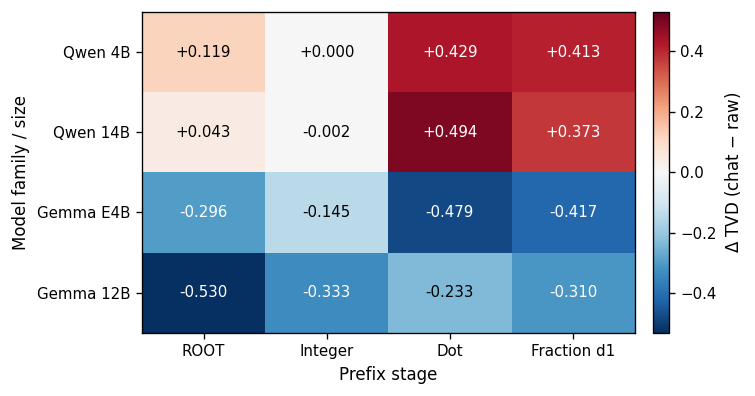

In [67]:
from matplotlib.colors import TwoSlopeNorm

plot_data = (
    rq4b_delta_matrix.copy()
)

max_abs = np.nanmax(
    np.abs(plot_data.to_numpy())
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs,
)

fig, ax = plt.subplots(
    figsize=(6.4, 3.4)
)

im = ax.imshow(
    plot_data,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
)

ax.set_xticks(
    range(len(plot_data.columns))
)
ax.set_xticklabels(
    plot_data.columns
)

ax.set_yticks(
    range(len(plot_data.index))
)
ax.set_yticklabels(
    plot_data.index
)

ax.set_xlabel("Prefix stage")
ax.set_ylabel("Model family / size")

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):

        value = plot_data.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:+.3f}",
                ha="center",
                va="center",
                fontsize=9,
                color=(
                    "white"
                    if abs(value)
                    > 0.55 * max_abs
                    else "black"
                ),
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.03,
)

cbar.set_label(
    r"$\Delta$ TVD (chat − raw)"
)

fig.tight_layout()
plt.show()

In [68]:
rq4b_direction_summary = (
    rq4b_paired
    .assign(
        direction=lambda x: np.select(
            [
                x["delta_chat_raw"] < -1e-12,
                x["delta_chat_raw"] > 1e-12,
            ],
            [
                "Chat improves",
                "Chat worsens",
            ],
            default="Approximately equal",
        )
    )
    .groupby(
        [
            "family_size",
            "stage",
            "direction",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

display(
    rq4b_direction_summary
)

direction                Approximately equal  Chat improves  Chat worsens
family_size stage                                                        
Gemma 12B   Dot                            0              5             0
            Fraction d1                    0              5             0
            Integer                        2              3             0
            ROOT                           0              5             0
Gemma E4B   Dot                            0              5             0
            Fraction d1                    0              5             0
            Integer                        2              3             0
            ROOT                           0              3             2
Qwen 14B    Dot                            0              0             5
            Fraction d1                    0              0             5
            Integer                        2              3             0
            ROOT                           0              2             3
Qwen 4B     Dot                            0              0             5
            Fraction d1                    0              0             5
            Integer                        2              2             1
            ROOT                           0              2             3

### Interpretation

The family-specific raw-to-chat contrast identified in RQ4.A is strongly stage-localised.

For both tested Qwen checkpoints, chat evaluation has almost no effect at the Integer stage but substantially increases conditional mismatch at Dot and Fraction depth 1. Qwen 4B increases by 0.429 TVD at Dot and 0.413 at Fraction depth 1, while Qwen 14B increases by 0.494 and 0.373 respectively. The overall deterioration under chat evaluation is therefore concentrated primarily in decimal-stage probability allocation rather than in the coarse Integer transition.

Gemma exhibits the opposite direction. Chat evaluation lowers TVD at every primary stage for both tested sizes. For Gemma E4B, the largest improvements occur at Dot (−0.479) and Fraction depth 1 (−0.417), making its stage profile close to the inverse of the Qwen pattern. Gemma 12B also improves throughout the numerical continuation, but its strongest recovery occurs at ROOT (−0.530) and Integer (−0.333).

The consistency of the direction across both tested sizes suggests a robust family-level protocol pattern within the evaluated checkpoints: chat evaluation worsens Qwen conditional alignment primarily at the decimal stages, whereas it improves Gemma alignment across the full stage structure.

The magnitude and localisation are nevertheless not identical within a family. In particular, the strongest Gemma improvement moves from the decimal stages at E4B to ROOT at 12B. Thus, family determines the broad direction of the observed protocol contrast, while checkpoint size can still alter where its largest effect appears.

### Result statement
###### Strong main-text figure candidate.
The raw-to-chat protocol effect is strongly stage- and family-dependent. For Qwen, chat evaluation leaves Integer alignment essentially unchanged but increases TVD by 0.43–0.49 at Dot and 0.37–0.41 at Fraction depth 1. Gemma shows the opposite direction: chat lowers TVD at every primary stage, with improvements reaching −0.48 at Dot for E4B and −0.53 at ROOT for 12B. The overall Qwen–Gemma protocol reversal therefore reflects systematically different stage-localised responses rather than a uniform shift in alignment.

### RQ4.B conclusion

The family-specific protocol effect is not a uniform change applied to the entire numerical continuation.

For Qwen, the chat-associated deterioration is concentrated predominantly at Dot and Fraction depth 1, while the Integer transition remains almost unchanged. For Gemma, chat improves alignment across all primary stages, although the stage of greatest recovery differs between the two tested sizes.

This localisation connects the overall RQ4.A contrast with the failure types identified in RQ2 and provides stronger evidence that evaluation protocol interacts with model family rather than producing a common effect across models.

**Next:** RQ4.C checks whether the direction of the raw-to-chat contrast is stable across the five canonical target distributions or whether the overall family reversal is driven by particular distributions.

## RQ4.C — Distribution-wise stability of the raw-to-chat effect

### Question

Is the family-specific raw-to-chat effect observed in RQ4.A stable across the five canonical target distributions, or is the overall contrast driven by particular targets?

### Motivation

RQ4.A showed that chat evaluation increases overall TVD for Qwen but decreases it for Gemma. RQ4.B further showed that this reversal is strongly stage-localised.

However, both results average across target distributions. A family-level protocol contrast could therefore arise even if chat improves alignment for some distributions and worsens it for others.

RQ4.C tests the direction of the raw-to-chat contrast separately for each canonical target distribution.

For family/size group $g$ and distribution $d$,

$$
\Delta_{\text{chat}}(g,d)
=
TVD_{\text{chat}}(g,d)
-
TVD_{\text{raw}}(g,d).
$$

The same primary hierarchical TVD estimand from RQ1.A is used.

Interpretation:

- $\Delta_{\text{chat}}<0$: chat evaluation improves conditional alignment;
- $\Delta_{\text{chat}}>0$: chat evaluation increases conditional mismatch.

In [69]:
# RQ4.C — Distribution-wise raw-to-chat contrasts

rq4c_rows = []

for group, ids in RQ4_PROTOCOL_PAIRS.items():

    raw = (
        primary_run_summary[
            primary_run_summary["model_id"]
            == ids["raw"]
        ][
            [
                "distribution",
                "mean_tvd",
            ]
        ]
        .rename(
            columns={
                "mean_tvd": "raw_tvd"
            }
        )
    )

    chat = (
        primary_run_summary[
            primary_run_summary["model_id"]
            == ids["chat"]
        ][
            [
                "distribution",
                "mean_tvd",
            ]
        ]
        .rename(
            columns={
                "mean_tvd": "chat_tvd"
            }
        )
    )

    paired = raw.merge(
        chat,
        on="distribution",
        how="inner",
    )

    paired["delta_chat_raw"] = (
        paired["chat_tvd"]
        - paired["raw_tvd"]
    )

    paired["family_size"] = group

    rq4c_rows.append(paired)


rq4c = pd.concat(
    rq4c_rows,
    ignore_index=True,
)


rq4c_matrix = (
    rq4c
    .pivot(
        index="family_size",
        columns="distribution",
        values="delta_chat_raw",
    )
    .reindex(
        index=GROUP_ORDER_RQ4B,
        columns=DISTRIBUTION_ORDER,
    )
)

display(
    rq4c_matrix.round(3)
)

distribution,normal,uniform,exponential,beta,laplace
family_size,,,,,
Qwen 4B,0.299,0.175,0.284,0.135,0.309
Qwen 14B,0.197,0.253,0.265,0.134,0.286
Gemma E4B,-0.299,-0.318,-0.247,-0.445,-0.362
Gemma 12B,-0.289,-0.318,-0.485,-0.376,-0.289


**Table RQ4.C.1.** Distribution-wise change in primary hierarchical TVD when the same post-trained checkpoint is evaluated under chat rather than raw protocol. Negative values indicate improved conditional alignment under chat evaluation, while positive values indicate increased mismatch.

In [70]:
rq4c_consistency = (
    rq4c
    .groupby("family_size")
    .agg(
        distributions=("distribution", "nunique"),

        chat_improves=(
            "delta_chat_raw",
            lambda x: (x < -1e-12).sum(),
        ),

        chat_worsens=(
            "delta_chat_raw",
            lambda x: (x > 1e-12).sum(),
        ),

        mean_delta=(
            "delta_chat_raw",
            "mean",
        ),

        min_delta=(
            "delta_chat_raw",
            "min",
        ),

        max_delta=(
            "delta_chat_raw",
            "max",
        ),
    )
    .reindex(GROUP_ORDER_RQ4B)
)

display(
    rq4c_consistency.round(3)
)

,distributions,chat_improves,chat_worsens,mean_delta,min_delta,max_delta
family_size,,,,,,
Qwen 4B,5,0,5,0.240,0.135,0.309
Qwen 14B,5,0,5,0.227,0.134,0.286
Gemma E4B,5,5,0,-0.334,-0.445,-0.247
Gemma 12B,5,5,0,-0.351,-0.485,-0.289


### Interpretation

The family-specific raw-to-chat contrast is directionally stable across all five canonical target distributions.

For both tested Qwen checkpoints, chat evaluation increases primary TVD for Normal, Uniform, Exponential, Beta, and Laplace. The deterioration ranges from +0.135 to +0.309 for Qwen 4B and from +0.134 to +0.286 for Qwen 14B.

The Gemma checkpoints show the opposite pattern for every distribution. Chat lowers TVD by 0.247–0.445 for Gemma E4B and by 0.289–0.485 for Gemma 12B.

Across the twenty family/size × distribution contrasts, there is therefore no reversal of the family-level protocol direction: all ten Qwen contrasts worsen under chat evaluation, while all ten Gemma contrasts improve.

Target distribution nevertheless affects the magnitude of the protocol effect. For example, the largest Gemma E4B improvement occurs for Beta, whereas the largest Gemma 12B improvement occurs for Exponential. Distribution therefore moderates the strength of the raw-to-chat change without overturning its direction.

This result is important given the distribution interactions identified in RQ3A. Although individual model probabilities are sensitive to target distribution, the overall Qwen–Gemma protocol reversal is not produced by one particular target or by cancellation across opposing distribution effects.

### Result statement
###### Appendix/supporting candidate — not currently needed in main text.
The raw-to-chat protocol effect is robust across canonical target distributions. Chat evaluation increases TVD for both Qwen checkpoints on all five distributions, with changes of +0.134 to +0.309, while it decreases TVD for both Gemma checkpoints on all five distributions, with changes of −0.247 to −0.485. Distribution affects the magnitude of the protocol contrast but never reverses its direction in the evaluated grid.

### RQ4.C conclusion

The family-specific protocol reversal identified in RQ4.A and localised by stage in RQ4.B is not driven by a subset of target distributions.

Its direction is identical across all five canonical targets for both tested sizes within each family. Distribution modifies how large the change is, but not whether chat improves or worsens conditional alignment.

The remaining RQ4 question is therefore not whether the protocol result is distribution-specific, but how model size and family relate to the baseline alignment itself.

**Next:** RQ4.D examines the matched Base checkpoints across the two tested sizes within Qwen and Gemma, asking whether the larger evaluated checkpoint consistently improves probabilistic alignment.

## RQ4.D — Model-size comparison within Base checkpoints

### Question

Within each evaluated model family, does the larger tested Base checkpoint show better conditional next-symbol alignment than the smaller Base checkpoint?

### Analysis choice

Model size is compared only between matched Base checkpoints:

- Qwen3-4B Base vs Qwen3-14B Base;
- Gemma-4-E4B Base vs Gemma-4-12B Base.

Restricting the comparison to Base checkpoints avoids mixing model-size differences with the instruction-tuning and raw-versus-chat protocol effects examined in RQ4.A–RQ4.C.

The primary hierarchical TVD from RQ1.A is used.

For family $f$, define

$$
\Delta_{\text{size}}(f)
=
TVD_{\text{larger Base}}
-
TVD_{\text{smaller Base}}.
$$

Negative values indicate lower TVD for the larger tested checkpoint, while positive values indicate greater mismatch.

Because only two sizes are evaluated within each family, these contrasts describe the tested checkpoints and are not interpreted as a general scaling relationship.

In [71]:
# RQ4.D — Matched Base size comparison

RQ4_SIZE_PAIRS = {
    "Qwen": {
        "smaller": "S1",   # Qwen3-4B Base
        "larger": "M1",    # Qwen3-14B Base
        "smaller_label": "4B",
        "larger_label": "14B",
    },
    "Gemma": {
        "smaller": "S4",   # Gemma-4-E4B Base
        "larger": "M4",    # Gemma-4-12B Base
        "smaller_label": "E4B",
        "larger_label": "12B",
    },
}


rq4d_model_means = (
    primary_run_summary
    .groupby("model_id")["mean_tvd"]
    .mean()
)


rq4d_rows = []

for family, ids in RQ4_SIZE_PAIRS.items():

    smaller = rq4d_model_means.loc[
        ids["smaller"]
    ]

    larger = rq4d_model_means.loc[
        ids["larger"]
    ]

    rq4d_rows.append(
        {
            "Family": family,
            "Smaller Base": ids["smaller_label"],
            "Smaller TVD": smaller,
            "Larger Base": ids["larger_label"],
            "Larger TVD": larger,
            "Larger − smaller": larger - smaller,
        }
    )


rq4d_overall = pd.DataFrame(
    rq4d_rows
)

display(
    rq4d_overall.round(3)
)

,Family,Smaller Base,Smaller TVD,Larger Base,Larger TVD,Larger − smaller
0,Qwen,4B,0.143,14B,0.178,0.035
1,Gemma,E4B,0.251,12B,0.279,0.028


**Table RQ4.D.1.** Primary hierarchical TVD for the matched Base checkpoints at the two evaluated sizes within each model family. Positive size deltas indicate greater conditional mismatch for the larger tested checkpoint. The comparison is descriptive and does not constitute a general scaling analysis.

In [72]:
# Stage-level Base comparison

rq4d_base_stage = (
    rq1a_stage_scores.copy()
)

rq4d_base_stage["stage"] = (
    rq4d_base_stage["prefix_kind"].map(
        {
            "start": "ROOT",
            "integer": "Integer",
            "dot": "Dot",
            "fraction_d1": "Fraction d1",
        }
    )
)


rq4d_stage_means = (
    rq4d_base_stage[
        rq4d_base_stage["model_id"].isin(
            ["S1", "M1", "S4", "M4"]
        )
    ]
    .groupby(
        ["model_id", "stage"],
        as_index=False,
    )
    .agg(
        stage_tvd=("stage_tvd", "mean")
    )
    .pivot(
        index="model_id",
        columns="stage",
        values="stage_tvd",
    )
    .reindex(
        columns=[
            "ROOT",
            "Integer",
            "Dot",
            "Fraction d1",
        ]
    )
)


rq4d_stage_delta = pd.DataFrame(
    {
        "Qwen 14B − 4B":
            rq4d_stage_means.loc["M1"]
            - rq4d_stage_means.loc["S1"],

        "Gemma 12B − E4B":
            rq4d_stage_means.loc["M4"]
            - rq4d_stage_means.loc["S4"],
    }
).T

display(
    rq4d_stage_delta.round(3)
)

stage,ROOT,Integer,Dot,Fraction d1
Qwen 14B − 4B,-0.121,-0.009,0.150,0.119
Gemma 12B − E4B,-0.015,0.036,0.047,0.044


The larger Qwen Base checkpoint improves the early/coarse stages but loses more conditional alignment during decimal allocation.

In [73]:
# Distribution-level size deltas

rq4d_distribution = (
    primary_run_summary[
        primary_run_summary["model_id"].isin(
            ["S1", "M1", "S4", "M4"]
        )
    ]
    .pivot(
        index="model_id",
        columns="distribution",
        values="mean_tvd",
    )
    .reindex(
        columns=DISTRIBUTION_ORDER
    )
)


rq4d_distribution_delta = pd.DataFrame(
    {
        "Qwen 14B − 4B":
            rq4d_distribution.loc["M1"]
            - rq4d_distribution.loc["S1"],

        "Gemma 12B − E4B":
            rq4d_distribution.loc["M4"]
            - rq4d_distribution.loc["S4"],
    }
).T

display(
    rq4d_distribution_delta.round(3)
)

distribution,normal,uniform,exponential,beta,laplace
Qwen 14B − 4B,0.094,-0.038,0.140,-0.052,0.029
Gemma 12B − E4B,0.039,0.053,0.011,0.009,0.027


Table RQ4.D.1 main/supporting; stage/distribution delta tables notebook or appendix. No scaling figure.

### Interpretation

The larger tested Base checkpoint does not improve overall conditional alignment in either model family. Qwen3-14B Base has mean primary TVD 0.178 compared with 0.143 for Qwen3-4B Base, while Gemma-4-12B Base has TVD 0.279 compared with 0.251 for Gemma-4-E4B Base. The observed differences are modest, however, at +0.035 and +0.028 respectively.

The Qwen comparison is not a uniform deterioration with size. The 14B Base checkpoint substantially improves ROOT alignment (−0.121 TVD) and is slightly better at Integer (−0.009), but shows greater mismatch at Dot (+0.150) and Fraction depth 1 (+0.119). Its distribution-wise effect also changes direction: the larger checkpoint performs better on Uniform and Beta but worse on Normal, Exponential, and Laplace.

The Gemma size contrast is more consistent but similarly modest. The 12B Base checkpoint is slightly better at ROOT but has somewhat larger TVD at Integer, Dot, and Fraction depth 1. It also has higher overall TVD than E4B on each of the five canonical distributions, with distribution-specific increases between 0.009 and 0.053.

Thus, the evaluated Base comparisons provide no evidence that the larger tested checkpoint systematically improves next-symbol probabilistic alignment. At the same time, the heterogeneous Qwen stage and distribution effects show why the result should not be interpreted as a general deterioration with scale. The observed size contrasts are also much smaller than the model-variant and raw-to-chat protocol differences identified earlier in RQ4.

### Result statement

Increasing checkpoint size within the tested Base models does not improve overall conditional alignment. Primary TVD increases from 0.143 to 0.178 between Qwen3-4B Base and Qwen3-14B Base and from 0.251 to 0.279 between Gemma-4-E4B Base and Gemma-4-12B Base. These differences are modest and are not uniform across the numerical task: the larger Qwen checkpoint improves ROOT alignment while worsening Dot and Fraction depth-1 allocation. The two-size comparisons therefore do not support a simple monotonic relationship between model size and probabilistic alignment.

### RQ4.D conclusion

The larger Base checkpoint is not better overall in either evaluated family, but the observed differences are small relative to the variant and protocol effects.

Qwen in particular shows a stage-dependent trade-off rather than uniform size-related deterioration, while Gemma shows a smaller and more consistent increase in mismatch for the larger checkpoint.

Because only two sizes are available within each family, these findings are limited to the evaluated checkpoint pairs and should not be interpreted as a general scaling law.

# RQ4 — Overall conclusion

Model family, model variant, evaluation protocol, and checkpoint size are associated with markedly different patterns of conditional probabilistic alignment, but the largest effects arise from variant and protocol rather than the tested Base-size differences.

Under raw evaluation, the post-trained Qwen checkpoints remain relatively close to their Base counterparts, whereas the raw Gemma IT checkpoints show substantially greater mismatch. Applying the chat protocol produces a pronounced family reversal: conditional TVD increases for both tested Qwen checkpoints but decreases substantially for both Gemma checkpoints.

This protocol effect is strongly stage-localised. Qwen deterioration occurs primarily at Dot and Fraction depth 1, while Gemma improves across the primary stage structure. The direction of the raw-to-chat contrast is also stable across all five canonical target distributions, showing that the family reversal is not driven by one particular target.

Model size produces much smaller differences. The larger tested Base checkpoint does not improve overall alignment in either family, but the Qwen comparison contains opposing stage and distribution effects rather than uniform deterioration. With only two sizes per family, these contrasts do not establish a general scaling relationship.

Overall, RQ4 shows that next-symbol probabilistic alignment is strongly dependent on the interaction between model family, model variant, and evaluation protocol. Treating instruction-tuned models independently of their evaluation interface would therefore conceal substantial and family-specific differences in the probability distributions being measured.

# RQ5 Bridge — Limited Prompt Intervention

The main grid includes two prompt conditions: the canonical `plain` prompt and `explanatory_4`.

This comparison provides a limited bridge to RQ5, but it is not used as the full prompt-intervention analysis. The dedicated prompt sweep contains the broader prompt family and is analysed separately.

## RQ5 Bridge — Does explanatory prompting change alignment or numerical compliance?

### Question

Relative to the plain-prompt baseline, does `explanatory_4` improve conditional probabilistic alignment, numerical compliance, or both?

### Analysis choice

The comparison is paired within each model/protocol × distribution condition.

Conditional alignment uses the same common-grid hierarchical TVD as RQ1.A:

$$
TVD_{\text{primary}}
=
\frac{
T_{\text{ROOT}}
+
T_{\text{Integer}}
+
T_{\text{Dot}}
+
T_{\text{Fraction d1}}
}{4}.
$$

Numerical compliance is summarised with the corresponding hierarchical valid-candidate mass,

$$
M_{\text{valid}}.
$$

For each matched condition, define

$$
\Delta TVD
=
TVD_{\text{explanatory\_4}}
-
TVD_{\text{plain}},
$$

and

$$
\Delta M_{\text{valid}}
=
M_{\text{valid, explanatory\_4}}
-
M_{\text{valid, plain}}.
$$

Therefore:

- $\Delta TVD<0$ indicates improved conditional alignment;
- $\Delta TVD>0$ indicates increased conditional mismatch;
- $\Delta M_{\text{valid}}>0$ indicates improved numerical compliance;
- $\Delta M_{\text{valid}}<0$ indicates reduced numerical compliance.

The two outcomes are interpreted separately. An explanatory prompt can improve one dimension without improving the other.

In [74]:
# RQ5 bridge — Plain vs explanatory_4

rq5b = prefix_df[
    prefix_df["prompt_type"].isin(
        ["plain", "explanatory_4"]
    )
].copy()

rq5b["prefix_str"] = (
    rq5b["prefix"]
    .fillna("ROOT")
    .astype(str)
)

rq5b["fraction_depth"] = np.where(
    rq5b["prefix_kind"] == "fraction",
    rq5b["prefix_str"]
        .str.split(".")
        .str[1]
        .str.len(),
    np.nan,
)

rq5b["stage"] = np.select(
    [
        rq5b["prefix_kind"] == "start",
        rq5b["prefix_kind"] == "integer",
        rq5b["prefix_kind"] == "dot",
        (
            (rq5b["prefix_kind"] == "fraction")
            & (rq5b["fraction_depth"] == 1)
        ),
    ],
    [
        "ROOT",
        "Integer",
        "Dot",
        "Fraction d1",
    ],
    default=None,
)

rq5b = rq5b[
    rq5b["stage"].notna()
].copy()


# Prefixes -> stage
rq5b_stage = (
    rq5b
    .groupby(
        [
            "model_id",
            "distribution",
            "prompt_type",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        tvd=("tv_analytic_lm", "mean"),
        valid_mass=("valid_candidate_mass", "mean"),
    )
)


# Equal weight over the four primary stages
rq5b_condition = (
    rq5b_stage
    .groupby(
        [
            "model_id",
            "distribution",
            "prompt_type",
        ],
        as_index=False,
    )
    .agg(
        tvd=("tvd", "mean"),
        valid_mass=("valid_mass", "mean"),
    )
)


# Pair plain and explanatory_4
rq5b_paired = (
    rq5b_condition
    .pivot(
        index=[
            "model_id",
            "distribution",
        ],
        columns="prompt_type",
        values=[
            "tvd",
            "valid_mass",
        ],
    )
)

rq5b_paired.columns = [
    "_".join(col)
    for col in rq5b_paired.columns
]

rq5b_paired = (
    rq5b_paired
    .reset_index()
)

rq5b_paired["delta_tvd"] = (
    rq5b_paired["tvd_explanatory_4"]
    - rq5b_paired["tvd_plain"]
)

rq5b_paired["delta_valid_mass"] = (
    rq5b_paired["valid_mass_explanatory_4"]
    - rq5b_paired["valid_mass_plain"]
)

rq5b_model = (
    rq5b_paired
    .groupby("model_id")
    .agg(
        plain_tvd=("tvd_plain", "mean"),
        explanatory_tvd=(
            "tvd_explanatory_4",
            "mean",
        ),
        delta_tvd=("delta_tvd", "mean"),

        plain_valid_mass=(
            "valid_mass_plain",
            "mean",
        ),
        explanatory_valid_mass=(
            "valid_mass_explanatory_4",
            "mean",
        ),
        delta_valid_mass=(
            "delta_valid_mass",
            "mean",
        ),
    )
    .reindex(MODEL_ORDER)
)

rq5b_model.insert(
    0,
    "model",
    [
        MODEL_LABELS[mid]
        for mid in rq5b_model.index
    ],
)

display(
    rq5b_model.round(3)
)

,model,plain_tvd,explanatory_tvd,delta_tvd,plain_valid_mass,explanatory_valid_mass,delta_valid_mass
model_id,,,,,,,
S1,Qwen3-4B Base · raw,0.143,0.155,0.011,0.820,0.804,-0.016
S2,Qwen3-4B Instruct · raw,0.235,0.255,0.021,0.992,0.830,-0.162
S3,Qwen3-4B Instruct · chat,0.475,0.451,-0.024,1.000,1.000,0.000
S4,Gemma-4-E4B Base · raw,0.251,0.190,-0.061,0.682,0.762,0.080
S5,Gemma-4-E4B IT · raw,0.556,0.410,-0.146,0.212,0.782,0.570
S6,Gemma-4-E4B IT · chat,0.222,0.199,-0.023,1.000,0.999,-0.001
M1,Qwen3-14B Base · raw,0.178,0.182,0.004,0.939,0.917,-0.022
M2,Qwen3-14B · raw,0.180,0.156,-0.024,0.762,0.753,-0.010
M3,Qwen3-14B · chat,0.407,0.436,0.029,1.000,1.000,0.000


**Table RQ5-B.1.** Paired effect of the `explanatory_4` prompt relative to the plain-prompt baseline. TVD and valid-candidate mass use the same four-stage hierarchical aggregation as the primary main-grid analysis. Negative $\Delta TVD$ indicates improved conditional alignment, while positive $\Delta M_{\text{valid}}$ indicates improved numerical compliance.

### Interpretation

The limited explanatory-prompt intervention does not produce a uniform improvement across model/protocol conditions.

Using the same primary hierarchical aggregation as the main-grid baseline, `explanatory_4` lowers TVD for seven of the twelve conditions and increases it for five. Averaged across conditions, mean TVD decreases modestly from 0.327 to 0.306, but individual changes range from −0.146 to +0.035. The average effect therefore conceals substantial model/protocol heterogeneity.

The strongest response occurs for Gemma-4-E4B IT raw. Its primary TVD decreases from 0.556 to 0.410 while valid-candidate mass increases from 0.212 to 0.782. Thus, explanatory prompting simultaneously improves conditional probability allocation and substantially increases the probability reaching the valid numerical continuation space. Gemma-4-E4B Base raw shows the same qualitative pattern, and both improvements are consistent across all five canonical distributions for these two E4B raw conditions.

Other conditions show that the two outcomes need not move together. Qwen3-14B raw improves in conditional TVD while valid-candidate mass decreases slightly. The chat-evaluated Gemma E4B condition similarly improves TVD without improving its already near-saturated compliance. Conversely, several conditions worsen in both dimensions, including Qwen3-4B Instruct raw and Gemma-4-12B IT chat.

The explanatory prompt should therefore not be interpreted as a general correction for probabilistic sampling. Its effect depends on the model and evaluation protocol, and improvements in numerical compliance are distinct from improvements in conditional probability alignment.

### Result statement

The limited `explanatory_4` intervention produces heterogeneous effects rather than a uniform improvement in probabilistic sampling. Conditional TVD improves for seven of twelve model/protocol conditions, with mean TVD decreasing from 0.327 to 0.306, while the direction of the effect reverses for the remaining conditions. The largest improvement occurs for Gemma-4-E4B IT raw, where TVD decreases by 0.146 and valid-candidate mass increases by 0.570. Across other conditions, conditional alignment and numerical compliance can improve or deteriorate independently. The main-grid prompt comparison therefore motivates, but does not replace, the broader prompt-sweep analysis required for RQ5.

### RQ5 bridge conclusion

The plain-versus-`explanatory_4` comparison provides preliminary evidence that prompt formulation can change both whether probability reaches the valid numerical continuation space and how accurately that probability is distributed once there.

However, the effect is strongly model/protocol dependent and cannot be characterised from two prompt conditions alone. The main grid therefore uses this comparison only as a bridge to RQ5.

The full RQ5 analysis is deferred to the dedicated prompt sweep, where prompt effects can be evaluated across the complete intervention set using matched prompt contrasts.

# Cross-RQ Synthesis

## Variance attribution

### Question

Across the main grid, which experimental dimensions account for variation in conditional probability allocation and numerical compliance?

### Analysis population

The headline variance attribution uses a dedicated balanced population rather than the full four-stage RQ1 grid. Deterministic single-candidate prefixes are not informative about probability allocation because their conditional TVD is mechanically zero. Removing them makes Integer structurally unavailable for Uniform and Beta, so the balanced synthesis uses the three stages that contain non-trivial decisions for all five canonical distributions:

$$
\text{ROOT},\quad
\text{Dot},\quad
\text{Fraction d1}.
$$

This gives

$$
12\ \text{model/protocol conditions}
\times
5\ \text{distributions}
\times
3\ \text{stages}
=
180\ \text{cells}.
$$

Prefixes are averaged within each model/protocol × distribution × stage cell before decomposition. The percentages therefore partition **between-cell variation in aggregated stage means**, not total prefix-level variation.

The decomposition is descriptive and does not use null-hypothesis significance testing. With one aggregated observation per factorial cell, there is no separate within-cell residual term at this level; the three-way component represents the remaining third-order structure among the observed cell means after lower-order effects are removed.


In [75]:
def factorial_ss_decomposition(
    data,
    value_col,
    model_col="model_id",
    distribution_col="distribution",
    stage_col="stage",
):

    grand = data[value_col].mean()

    model_mean = (
        data.groupby(model_col)[value_col]
        .mean()
    )

    distribution_mean = (
        data.groupby(distribution_col)[value_col]
        .mean()
    )

    stage_mean = (
        data.groupby(stage_col)[value_col]
        .mean()
    )

    model_distribution_mean = (
        data.groupby(
            [model_col, distribution_col]
        )[value_col]
        .mean()
    )

    model_stage_mean = (
        data.groupby(
            [model_col, stage_col]
        )[value_col]
        .mean()
    )

    distribution_stage_mean = (
        data.groupby(
            [distribution_col, stage_col]
        )[value_col]
        .mean()
    )


    n_models = data[model_col].nunique()
    n_distributions = (
        data[distribution_col].nunique()
    )
    n_stages = data[stage_col].nunique()


    ss_model = (
        n_distributions
        * n_stages
        * ((model_mean - grand) ** 2).sum()
    )

    ss_distribution = (
        n_models
        * n_stages
        * (
            (distribution_mean - grand) ** 2
        ).sum()
    )

    ss_stage = (
        n_models
        * n_distributions
        * ((stage_mean - grand) ** 2).sum()
    )


    ss_model_distribution = 0.0

    for (m, d), mean_md in (
        model_distribution_mean.items()
    ):

        effect = (
            mean_md
            - model_mean[m]
            - distribution_mean[d]
            + grand
        )

        ss_model_distribution += (
            n_stages * effect ** 2
        )


    ss_model_stage = 0.0

    for (m, s), mean_ms in (
        model_stage_mean.items()
    ):

        effect = (
            mean_ms
            - model_mean[m]
            - stage_mean[s]
            + grand
        )

        ss_model_stage += (
            n_distributions * effect ** 2
        )


    ss_distribution_stage = 0.0

    for (d, s), mean_ds in (
        distribution_stage_mean.items()
    ):

        effect = (
            mean_ds
            - distribution_mean[d]
            - stage_mean[s]
            + grand
        )

        ss_distribution_stage += (
            n_models * effect ** 2
        )


    ss_three_way = 0.0

    for _, row in data.iterrows():

        m = row[model_col]
        d = row[distribution_col]
        s = row[stage_col]
        y = row[value_col]

        three_way = (
            y
            - model_distribution_mean[m, d]
            - model_stage_mean[m, s]
            - distribution_stage_mean[d, s]
            + model_mean[m]
            + distribution_mean[d]
            + stage_mean[s]
            - grand
        )

        ss_three_way += three_way ** 2


    ss_total = (
        (data[value_col] - grand) ** 2
    ).sum()


    result = pd.DataFrame(
        {
            "Component": [
                "Model / protocol",
                "Distribution",
                "Stage",
                "Model × Distribution",
                "Model × Stage",
                "Distribution × Stage",
                "Model × Distribution × Stage",
            ],
            "SS": [
                ss_model,
                ss_distribution,
                ss_stage,
                ss_model_distribution,
                ss_model_stage,
                ss_distribution_stage,
                ss_three_way,
            ],
        }
    )

    result["Share"] = (
        result["SS"] / ss_total
    )

    result["Percent"] = (
        100 * result["Share"]
    )

    return result

In [76]:
# SYN — Balanced non-trivial population for variance attribution

syn_df = plain_df.copy()

if "fraction_depth" not in syn_df.columns:
    prefix_string = (
        syn_df["prefix"]
        .fillna("ROOT")
        .astype(str)
    )

    syn_df["fraction_depth"] = np.where(
        syn_df["prefix_kind"] == "fraction",
        prefix_string
            .str.split(".")
            .str[1]
            .str.len(),
        np.nan,
    )


# Keep only stages that are non-trivial across all five distributions
syn_df = syn_df[
    (
        syn_df["prefix_kind"].isin(
            ["start", "dot"]
        )
    )
    | (
        (syn_df["prefix_kind"] == "fraction")
        & (syn_df["fraction_depth"] == 1)
    )
].copy()


# Allocation decisions only
syn_df = syn_df[
    syn_df["n_valid_candidates"] > 1
].copy()


syn_df["stage"] = (
    syn_df["prefix_kind"].map(
        {
            "start": "ROOT",
            "dot": "Dot",
            "fraction": "Fraction d1",
        }
    )
)


# Prefixes -> one value per factorial cell
syn_cells = (
    syn_df
    .groupby(
        [
            "model_id",
            "distribution",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        tvd=("tv_analytic_lm", "mean"),
        valid_mass=("valid_candidate_mass", "mean"),
    )
)

syn_cells["outside_valid_mass"] = (
    1 - syn_cells["valid_mass"]
)


print(
    "Synthesis cells:",
    len(syn_cells)
)

display(
    syn_cells
    .groupby(
        ["model_id", "distribution"]
    )
    .size()
    .value_counts()
)

Synthesis cells: 180


3    60
Name: count, dtype: int64

In [77]:
syn_coverage = (
    syn_cells
    .groupby(
        ["distribution", "stage"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(DISTRIBUTION_ORDER)
)

display(syn_coverage)

stage,Dot,Fraction d1,ROOT
distribution,,,
normal,12,12,12
uniform,12,12,12
exponential,12,12,12
beta,12,12,12
laplace,12,12,12


In [78]:
syn_tvd_variance = (
    factorial_ss_decomposition(
        syn_cells,
        "tvd",
    )
)

syn_compliance_variance = (
    factorial_ss_decomposition(
        syn_cells,
        "outside_valid_mass",
    )
)


syn_variance_summary = (
    syn_tvd_variance[
        ["Component", "Percent"]
    ]
    .rename(
        columns={
            "Percent": "Conditional TVD"
        }
    )
    .merge(
        syn_compliance_variance[
            ["Component", "Percent"]
        ]
        .rename(
            columns={
                "Percent":
                    "Outside-valid mass"
            }
        ),
        on="Component",
    )
)

display(
    syn_variance_summary.round(1)
)

,Component,Conditional TVD,Outside-valid mass
0,Model / protocol,48.9,55.4
1,Distribution,0.1,0.1
2,Stage,1.7,15.7
3,Model × Distribution,5.9,1.3
4,Model × Stage,27.4,23.7
5,Distribution × Stage,2.7,0.6
6,Model × Distribution × Stage,13.2,3.3


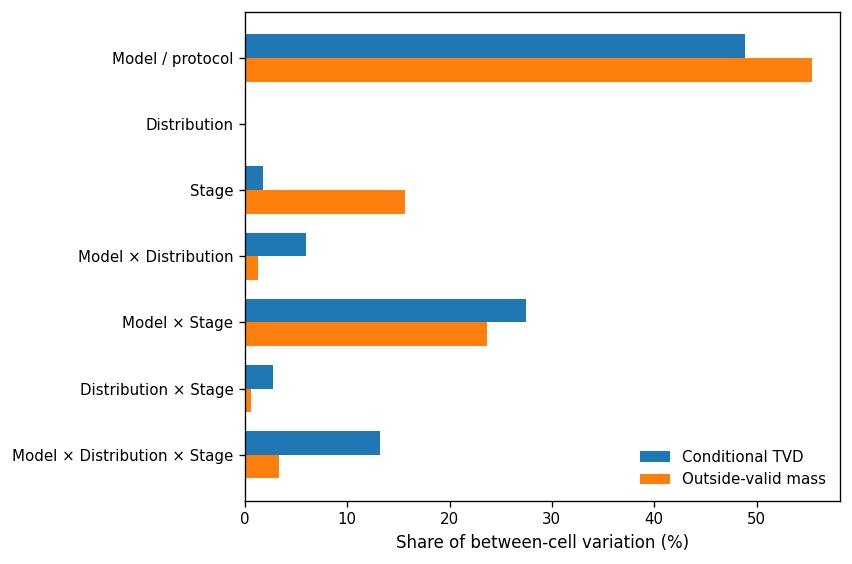

In [79]:
# Figure SYN.1 — corrected variance attribution
plot_df = syn_variance_summary.set_index("Component")

y = np.arange(len(plot_df))
height = 0.36

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.barh(
    y - height / 2,
    plot_df["Conditional TVD"],
    height=height,
    label="Conditional TVD",
)

ax.barh(
    y + height / 2,
    plot_df["Outside-valid mass"],
    height=height,
    label="Outside-valid mass",
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Share of between-cell variation (%)")
ax.invert_yaxis()
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


**Figure SYN.1.** Descriptive attribution of between-cell variation across the balanced non-trivial main-grid synthesis population. The decomposition uses 180 aggregated model/protocol × distribution × stage cells spanning ROOT, Dot, and Fraction depth 1. Percentages partition variation among the observed cell means; they do not represent total prefix-level variance.


### Interpretation

The balanced non-trivial decomposition shows that conditional probability-allocation error is dominated by model/protocol condition and its interaction with numerical stage rather than by a universal stage effect.

Model/protocol accounts for 48.9% of the observed between-cell TVD variation. The model × stage interaction contributes a further 27.4%, while stage alone accounts for only 1.7%.

This distinction is important. The large stage differences observed in individual conditions do not imply that one numerical stage is universally difficult. Instead, the location of the mismatch depends strongly on which model/protocol condition is being evaluated. This quantitatively supports the heterogeneous stage profiles identified in RQ2.

Distribution contributes only 0.1% as a universal main effect. However, distribution-dependent interactions remain appreciable: model × distribution accounts for 5.9%, distribution × stage for 2.7%, and the model × distribution × stage interaction for 13.2%. Components involving distribution therefore account for substantially more variation than the marginal distribution effect alone.

This reproduces the central RQ3A result: canonical distribution family has little stable global effect, but target-distribution dependence can become substantial for particular models at particular numerical states.

Numerical compliance shows a different structure. Model/protocol accounts for 55.4% of the observed between-cell variation in outside-valid mass, followed by model × stage at 23.7% and stage at 15.7%. Thus, compliance has a stronger universal stage component than conditional probability allocation, while both outcomes remain strongly dependent on model/protocol condition.

Because prefixes were aggregated before the factorial decomposition, these percentages partition variation between the 180 model/protocol × distribution × stage cell means. They do not represent the total prefix-level variance in the dataset.

### Result statement

Across the balanced non-trivial stage grid, model/protocol condition accounts for 48.9% of between-cell conditional-TVD variation and the model × stage interaction accounts for a further 27.4%, whereas stage alone contributes only 1.7%. Thus, the location of conditional probability mismatch is primarily model-dependent rather than a universal property of numerical stage.

Distribution contributes only 0.1% as a main effect, but distribution-containing interactions account for substantially more variation, including a 13.2% model × distribution × stage component. Numerical compliance has a different structure, with model/protocol accounting for 55.4%, stage for 15.7%, and model × stage for 23.7% of between-cell variation.

## Relationship between numerical compliance and conditional alignment

RQ1.E established that valid-candidate mass and conditional TVD measure different aspects of numerical prediction. The variance decomposition further shows that the two outcomes have different factorial structure.

As an additional descriptive check, we quantify how strongly the two error measures co-vary across the same balanced non-trivial synthesis grid.

For consistent directionality, numerical non-compliance is represented as

$$
M_{\text{outside}}
=
1-M_{\text{valid}},
$$

so that larger values indicate worse performance for both quantities.

Two associations are considered:

1. the raw correlation across the 180 model/protocol × distribution × stage cells;
2. the correlation between residuals after removing additive model/protocol, distribution, and stage effects from each outcome.

The residual comparison asks whether cells with unusually high conditional TVD relative to their additive design-factor expectations also tend to have unusually high outside-valid mass.

These correlations are descriptive. They are not used as significance tests and should not be interpreted as evidence that the two outcomes are statistically independent or causally related.

In [80]:
# SYN — Relationship between conditional TVD
# and outside-valid probability mass

# Raw association across the 180 balanced cells
raw_pearson = (
    syn_cells[
        ["tvd", "outside_valid_mass"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

raw_spearman = (
    syn_cells[
        ["tvd", "outside_valid_mass"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)


# Residualise both outcomes with respect to
# additive model/protocol + distribution + stage effects
design = pd.get_dummies(
    syn_cells[
        [
            "model_id",
            "distribution",
            "stage",
        ]
    ],
    drop_first=True,
    dtype=float,
)

X = np.column_stack(
    [
        np.ones(len(design)),
        design.to_numpy(),
    ]
)


def residualize(y, X):
    beta, *_ = np.linalg.lstsq(
        X,
        np.asarray(y, dtype=float),
        rcond=None,
    )

    return (
        np.asarray(y, dtype=float)
        - X @ beta
    )


tvd_residual = residualize(
    syn_cells["tvd"],
    X,
)

outside_residual = residualize(
    syn_cells["outside_valid_mass"],
    X,
)


residual_pearson = np.corrcoef(
    tvd_residual,
    outside_residual,
)[0, 1]

residual_spearman = (
    pd.Series(tvd_residual)
    .corr(
        pd.Series(outside_residual),
        method="spearman",
    )
)


relationship_summary = pd.DataFrame(
    {
        "Comparison": [
            "Raw 180-cell association",
            "After additive-factor residualisation",
        ],
        "Pearson": [
            raw_pearson,
            residual_pearson,
        ],
        "Spearman": [
            raw_spearman,
            residual_spearman,
        ],
    }
)

display(
    relationship_summary.round(3)
)

,Comparison,Pearson,Spearman
0,Raw 180-cell association,0.367,0.070
1,After additive-factor residualisation,0.457,0.468


### Interpretation

Numerical compliance and conditional alignment are related but non-redundant outcomes.

Across the 180 balanced model/protocol × distribution × stage cells, outside-valid mass has a moderate positive Pearson association with conditional TVD ($r=0.367$), indicating that larger numerical non-compliance often accompanies larger conditional mismatch. However, the corresponding Spearman correlation is only $\rho=0.070$. Thus, the raw relationship does not form a stable monotonic ordering across conditions.

After removing the additive effects of model/protocol, distribution, and numerical stage from both outcomes, the residual association becomes more consistent: Pearson correlation increases to $r=0.457$ and Spearman correlation to $\rho=0.468$. Cells exhibiting more non-compliance than expected from these broad design factors therefore also tend to exhibit greater-than-expected conditional mismatch.

This association does not make the two measures interchangeable. Earlier analyses identify conditions with near-complete numerical compliance but substantial conditional TVD, as well as conditions with severe non-compliance but comparatively smaller conditional mismatch. The variance attribution also assigns different proportions of variation to the experimental factors for the two outcomes.

Numerical compliance and conditional alignment should therefore be interpreted as distinct but partially related dimensions of model behaviour.

### Result statement

Outside-valid mass and conditional TVD are partially associated but not interchangeable. Across the balanced 180-cell synthesis grid, their raw Pearson correlation is $r=0.367$, while their rank correlation is only $\rho=0.070$. After removing additive model/protocol, distribution, and stage effects, the residual correlations increase to $r=0.457$ and $\rho=0.468$. Thus, numerical non-compliance and conditional misallocation tend to co-occur within specific experimental cells, while remaining sufficiently distinct to require separate evaluation.

## High-compliance / high-TVD audit

The separation between numerical compliance and conditional alignment is particularly clear in prefixes where valid-candidate mass is close to one while conditional TVD is also very large.

For two conditional distributions $P$ and $Q$ over the same candidate set,

$$
TVD(P,Q)
=
1-
\sum_c
\min(P(c),Q(c)).
$$

Therefore,

$$
1-TVD(P,Q)
$$

is the total overlap between the two probability vectors.

Exact $TVD=1$ would imply disjoint conditional support. Values close to one indicate that the two distributions place almost all of their probability mass on different candidates.

This should not automatically be interpreted as probability assigned to structurally impossible continuations. A candidate can have very small but non-zero analytic probability, and stored numerical zeros can also occur in extreme tails of distributions with unbounded mathematical support.

In [81]:
# High-compliance / high-TVD audit
high_valid_high_tvd = plain_df[
    (plain_df["valid_candidate_mass"] >= 0.99)
    & (plain_df["tv_analytic_lm"] >= 0.90)
].copy()

high_valid_high_tvd["prefix_key"] = (
    high_valid_high_tvd["prefix"].fillna("ROOT").astype(str)
)
high_valid_high_tvd["overlap_mass"] = 1 - high_valid_high_tvd["tv_analytic_lm"]

print("Prefixes with valid mass >= 0.99 and TVD >= 0.90:", len(high_valid_high_tvd))

display(
    high_valid_high_tvd["prefix_kind"]
    .value_counts()
    .rename("count")
    .to_frame()
)

display(
    high_valid_high_tvd["model_id"]
    .value_counts()
    .reindex(MODEL_ORDER)
    .dropna()
    .rename("count")
    .to_frame()
)

extreme_case_summary = (
    high_valid_high_tvd[
        high_valid_high_tvd["tv_analytic_lm"] >= 0.95
    ][
        [
            "model_id",
            "distribution",
            "prefix_key",
            "valid_candidate_mass",
            "tv_analytic_lm",
            "overlap_mass",
        ]
    ]
    .sort_values("tv_analytic_lm", ascending=False)
)

display(extreme_case_summary.round(6))


Prefixes with valid mass >= 0.99 and TVD >= 0.90: 20


,count
prefix_kind,
fraction,15
integer,4
start,1


,count
model_id,
S3,3.0
S5,4.0
M2,2.0
M3,3.0
M5,8.0


,model_id,distribution,prefix_key,valid_candidate_mass,tv_analytic_lm,overlap_mass
1345,M5,normal,1,0.999798,0.999949,0.000051
1443,M5,laplace,1,0.999887,0.999908,0.000092
1397,M5,exponential,2,0.999094,0.999789,0.000211
1396,M5,exponential,1,0.999648,0.999688,0.000312


In [82]:
# Token-level check for the most extreme cases
extreme_keys = high_valid_high_tvd[
    high_valid_high_tvd["tv_analytic_lm"] >= 0.95
][["run_id", "model_id", "distribution", "prefix_key"]].copy()

rows = []
for _, case in extreme_keys.iterrows():
    g = token_df[
        (token_df["run_id"] == case["run_id"])
        & (token_df["prefix"].fillna("ROOT").astype(str) == case["prefix_key"])
    ].copy()
    top = g.sort_values("lm_prob", ascending=False).iloc[0]
    dot = g[g["token"] == "."]
    rows.append({
        "model_id": case["model_id"],
        "distribution": case["distribution"],
        "prefix": case["prefix_key"],
        "model_top_candidate": top["token"],
        "model_top_probability": top["lm_prob"],
        "analytic_top_candidate": g.sort_values("analytic_truth", ascending=False).iloc[0]["token"],
        "dot_model_probability": dot["lm_prob"].iloc[0] if len(dot) else np.nan,
        "dot_analytic_probability": dot["analytic_truth"].iloc[0] if len(dot) else np.nan,
    })

extreme_token_check = pd.DataFrame(rows)
display(extreme_token_check.round(6))


,model_id,distribution,prefix,model_top_candidate,model_top_probability,analytic_top_candidate,dot_model_probability,dot_analytic_probability
0,M5,normal,1,1,0.999898,.,0.000051,1.000000
1,M5,exponential,1,1,0.998876,.,0.000131,0.999805
2,M5,exponential,2,2,0.972911,.,0.000211,1.000000
3,M5,laplace,1,1,0.999954,.,0.000021,0.999805


### Interpretation

The high-compliance/high-TVD audit confirms that severe conditional mismatch can occur even when essentially all model probability lies within the valid numerical continuation space.

Twenty plain-prompt prefixes have valid-candidate mass of at least 0.99 while conditional TVD exceeds 0.90. Fifteen of these occur at Fraction states, four at Integer states, and one at ROOT.

The four most extreme cases all belong to Gemma-4-12B IT raw and have TVD between 0.9997 and 0.99995 despite valid-candidate mass above 0.999. Their conditional model and analytic distributions therefore overlap by only approximately 0.005%–0.031% of probability mass.

Token-level inspection shows that these cases are not generic support violations. At the affected Integer prefixes, analytic truth assigns essentially all probability to the decimal-point transition, whereas the model assigns almost all conditional probability to repeating the current integer digit. The extreme TVD therefore reflects a near-complete redistribution within the valid numerical candidate set.

A second pattern occurs at fractional prefixes. Several high-compliance conditions collapse nearly all conditional probability onto one digit even though analytic truth is comparatively diffuse. These cases reproduce the over-concentration and candidate-level residual patterns identified in RQ2.B and RQ2.F.

Near-unit TVD should therefore be interpreted as near-zero overlap between the conditional probability vectors. It does not, by itself, establish assignment to structurally impossible continuations; that stronger claim is reserved for the support-based analysis in RQ2.E.

### Audit result

Extreme conditional mismatch is not explained by numerical non-compliance. Among prefixes with valid-candidate mass of at least 0.99, twenty have TVD above 0.90, including four Gemma-4-12B IT raw Integer states with TVD above 0.999. These near-disjoint conditional distributions arise primarily from failure to make the analytically dominant decimal-point transition and, at fractional states, from collapse onto individual valid digits. The cases therefore reinforce rather than revise the stage- and token-level failure mechanisms identified in RQ2.

## Statistical escalation decision

The corrected balanced factorial decomposition provides a direct and interpretable attribution of the observed between-cell variation. A separate fANOVA is therefore not required for the main-grid Results.

ZOIB regression is likewise not required for the current variance-attribution question. It remains a possible method specifically for `valid_candidate_mass` only if a later adjusted regression question requires modelling its boundary mass.

No additional main-grid inferential model is introduced at this stage.


# Main Grid — Final RQ Audit and Overall Interpretation

The main-grid analysis is now considered scientifically complete.

The purpose of this grid was to establish the baseline phenomenon under canonical target distributions, identify where conditional probability alignment succeeds or fails, examine canonical distribution dependence, compare model families/variants/evaluation protocols, and provide a limited bridge toward prompt intervention.

The analyses below summarise what each research question contributes and how the results fit together.

### RQ1 — Final interpretation

The canonical main-grid conditions establish a clear but heterogeneous failure of conditional probabilistic alignment. The result is not an artefact of deterministic numerical states, cannot be reduced to incorrect candidate ranking, and cannot be explained solely by probability mass leaving the valid numerical continuation space.

The models contain useful probability structure in some parts of the task, particularly coarse numerical decisions, but their conditional next-symbol probabilities do not consistently reproduce analytic truth. The mismatch becomes especially striking during decimal allocation, where a simple uniform allocation can be substantially closer to the mathematically correct distribution than the model itself.

### RQ2 — Final interpretation

The overall probabilistic mismatch does not correspond to one common failure mode.

Different stages expose different problems. ROOT can involve both numerical non-compliance and strong distortion of sign probabilities. Integer mismatch is primarily a failure to make the analytically required transition to the decimal point. At Dot and Fraction depth 1, the model usually remains within the valid numerical candidate set but distributes probability too selectively among the available digits.

The decimal-stage error is particularly systematic. Analytic next-digit distributions are nearly maximally diffuse, whereas the evaluated models consistently introduce additional concentration. Token-level residuals show that this excess probability is disproportionately shifted toward lower-valued digits, although the exact attracting digit depends on the model/protocol condition.

Thus, similar aggregate TVD values can arise through substantially different numerical failure modes.

### RQ3A — Final interpretation

Canonical distribution family has only a modest marginal association with probabilistic alignment, but this does not imply distribution invariance.

Distribution effects are strongly conditional on model/protocol and numerical stage. The relative ordering of distributions changes throughout the numerical continuation, and individual models can react much more strongly to a change in target distribution than the marginal distribution averages suggest.

Most importantly, matched-prefix analysis shows that model probabilities can change substantially across target specifications even when the locally correct analytic next-symbol distribution changes almost not at all. Distribution dependence is therefore better characterised as a local and interaction-dependent sensitivity than as a stable hierarchy of easier and harder distribution families.

### RQ4 — Final interpretation

Model variant and evaluation protocol produce some of the largest differences observed in the main grid.

The strongest result is a family-specific raw-to-chat reversal. Evaluating the same post-trained checkpoint through the chat protocol substantially worsens conditional alignment for both tested Qwen sizes but substantially improves it for both tested Gemma sizes. This direction is stable across all five canonical distributions.

The protocol effect is also highly stage-specific. Qwen deterioration is concentrated primarily at Dot and Fraction depth 1, while Gemma improves across the numerical continuation.

Model-size differences are comparatively modest and interaction-dependent. The larger tested Base checkpoint does not improve overall alignment in either family, but two checkpoint sizes are insufficient to establish a general scaling relationship.

The main RQ4 result is therefore not a universal hierarchy of model variants. It is strong dependence on the combination of model family, post-training state, and evaluation protocol.

### RQ5 bridge — Final interpretation

The limited explanatory-prompt intervention demonstrates that prompt formulation can modify both numerical compliance and conditional probability allocation, but it does not provide a universal correction.

Effects differ substantially across model/protocol conditions and can act differently on the two outcome dimensions. The main-grid comparison therefore establishes prompt sensitivity but does not attempt to characterise the broader prompt-treatment landscape.

The full answer to RQ5 belongs to the dedicated prompt sweep.

## Cross-RQ synthesis — corrected interpretation

The corrected variance attribution sharpens the interaction-based interpretation of the main grid.

For conditional TVD, model/protocol accounts for 48.9% of observed between-cell variation and model × stage accounts for a further 27.4%, while stage alone contributes only 1.7%. The large stage differences seen in individual conditions therefore do not represent a universal stage hierarchy. Instead, the location of conditional mismatch depends strongly on which model/protocol condition is being evaluated.

Distribution contributes only 0.1% as a universal TVD main effect, but distribution-containing interactions remain substantial, especially the 13.2% model × distribution × stage component. This is consistent with RQ3A: marginal distribution differences are small, while local distribution sensitivity can be large for particular models and stages.

Numerical compliance has a different structure. Model/protocol accounts for 55.4% of outside-valid-mass variation, stage for 15.7%, and model × stage for 23.7%. Compliance and conditional alignment are therefore distinct but partially related outcomes with different factorial structure.


# Main Grid — Overall Conclusion

The main grid provides consistent evidence that LLM next-symbol probabilities do not generally reproduce the analytically correct conditional probabilities required for probabilistic numerical sampling. However, this mismatch is not adequately described by a single global error score.

The magnitude and form of the error depend strongly on the model/protocol condition and on the numerical state at which the probability distribution is evaluated. Coarse numerical decisions can be represented relatively well even when later decimal allocation is poor, while other conditions show the opposite profile. Consequently, models with similar aggregate TVD can fail for fundamentally different reasons.

The decimal stages reveal one of the clearest recurring patterns. At Fraction depth 1, the analytically correct next-digit distributions are almost maximally diffuse, and a simple uniform-over-valid-candidates reference is correspondingly very close to analytic truth. Nevertheless, every evaluated model–distribution condition is more concentrated than the analytic target and performs worse than this uniform reference. Token-level analysis shows that the resulting mismatch is structured rather than diffuse, with excess probability disproportionately assigned to lower-valued digits, although the specific attracting digit remains model dependent.

The framework also exposes failures that a conditional distance metric alone would miss. Some conditions place very little raw probability on valid numerical continuations but distribute the remaining numerical mass comparatively well. Others place essentially all probability within the valid candidate set while still showing severe conditional mismatch. Bounded targets additionally reveal probability assigned to numerically valid continuations that are impossible under the target support. Numerical compliance, target-support compatibility, and conditional probability allocation therefore represent distinct aspects of model behaviour.

Target distribution does not produce a stable global hierarchy of difficulty. Marginal differences between the five canonical distributions are small, but model- and stage-specific distribution sensitivity can be substantial. At matched decimal prefixes, model conditional distributions can change dramatically between target specifications even when the analytically correct local next-symbol distributions are nearly identical or, in controlled cases such as positive Exponential and Laplace prefixes, effectively identical.

Model family and evaluation protocol produce some of the largest systematic contrasts. The same raw-to-chat protocol change substantially worsens conditional alignment for both tested Qwen checkpoints but substantially improves it for both Gemma checkpoints, and this reversal is consistent across all five canonical distributions. The location of the effect also differs: Qwen deterioration is concentrated primarily at Dot and Fraction depth 1, whereas Gemma improves across the stage structure.

Larger Base checkpoints do not improve overall alignment in the two tested family comparisons, but the effects are small and stage-dependent and therefore do not establish a general scaling relationship. Likewise, the limited explanatory-prompt comparison shows that prompt formulation can alter both conditional alignment and numerical compliance, but its heterogeneous effects require the dedicated prompt sweep for a complete RQ5 analysis.

Taken together, the main-grid results show that evaluating an LLM as a probabilistic sampler requires more than measuring whether it produces plausible numerical outputs. The relevant behaviour is local and conditional: probability must reach the appropriate numerical continuation space, respect the target support, and then be allocated correctly among the available next symbols. The evaluated models can succeed on one of these requirements while failing strongly on another. Their probabilistic sampling behaviour is therefore best understood through the interaction between model, evaluation protocol, numerical stage, and target specification rather than through a single model-level score.

# Final Figure / Table Freeze

The following are the main-text candidates for the main-grid Results section:

| Item | Purpose | Status |
|---|---|---|
| **Table RQ1.A.1** — model × distribution primary TVD | Establish baseline conditional alignment | **MAIN** |
| **Figure RQ1.C.1** — uniform-valid reference by stage | Give TVD an interpretable reference | **MAIN** |
| **Figure RQ1.E.1** — outside-valid mass + conditional TVD | Establish the two-outcome distinction | **MAIN** |
| **Figure RQ2.A.1** — model × stage TVD | Localise conditional mismatch | **MAIN** |
| **Figure RQ2.B.1** — normalized entropy gap | Show decimal over-concentration | **MAIN** |
| **Figure RQ2.F.1** — Fraction-d1 digit residual heatmap | Expose candidate-level structure | **MAIN** |
| **Figure RQ3A.C.1** — matched-prefix distribution sensitivity | Main evidence for local distribution dependence | **MAIN** |
| **Table RQ4.A.1** — Base/raw/chat contrasts | Establish family-specific protocol reversal | **MAIN** |
| **Figure RQ4.B.1** — stage-wise chat−raw delta | Localise the protocol effect | **MAIN** |
| **Figure SYN.1** — corrected variance attribution | Cross-RQ synthesis | **MAIN if space allows** |

Supporting analyses remain in the notebook where they are needed to establish the result, but duplicate exploratory figures have been removed. ROOT sign, stage-compliance, distribution-profile, size-detail, RQ5-bridge, and example-token figures are not part of the frozen main-text figure set.


# Main-Grid Analysis Freeze

- [x] RQ1.A — Primary conditional alignment
- [x] RQ1.B — Deterministic-prefix sensitivity
- [x] RQ1.C — Uniform valid-candidate reference
- [x] RQ1.D — Ranking and secondary metrics
- [x] RQ1.E — Compliance versus conditional alignment
- [x] RQ2.A — Stage localisation
- [x] RQ2.B — Entropy / concentration
- [x] RQ2.C — ROOT sign allocation
- [x] RQ2.D — Stage-localised compliance
- [x] RQ2.E — Structural support violations
- [x] RQ2.F — Token-level residual structure
- [x] RQ3A.A — Marginal distribution dependence
- [x] RQ3A.B — Distribution × stage dependence
- [x] RQ3A.C — Matched-prefix distribution sensitivity
- [x] RQ4.A — Base / post-trained / protocol comparison
- [x] RQ4.B — Stage-localised protocol effect
- [x] RQ4.C — Distribution robustness of protocol effect
- [x] RQ4.D — Limited Base size comparison
- [x] RQ5 bridge — plain vs `explanatory_4`
- [x] Corrected cross-RQ variance attribution
- [x] Compliance–alignment relationship diagnostic
- [x] High-compliance / high-TVD audit
- [x] fANOVA escalation decision
- [x] ZOIB escalation decision
- [x] Main-text figure/table freeze

## Status: MAIN-GRID SCIENTIFIC ANALYSIS FROZEN

No additional substantive main-grid analysis should be introduced unless Results writing reveals a genuine unanswered research-question gap, a contradiction in the existing evidence, or a technical error that changes an estimand or conclusion.
